# Automated VWAP V5 Backtest Runner

This notebook is the V4 automated backtest runner for the VWAP Probability Band Engine project.

V4 is intended to test dynamic regime selection between existing continuation entry modules.

At this stage, V4 starts from the completed V3 notebook so the inherited baseline can be separated before adding regime classification and model routing.

It tests one defined automated strategy version on historical OHLC CSV data.

The notebook is separate from the research notebook and separate from the visual/discretionary MT5 overlay.

This notebook does not connect to MT5 and does not place live trades.

## Strategy Version

**Version:** Automated VWAP V5

V4 is intended to test a dynamic VWAP regime selector between existing continuation entry modules.

The planned V4 structure is:

- calm / clean trend uses V1-style green reclaim/rejection entries
- volatile but directional trend uses V3 second-close green reclaim/rejection entries
- chop / unclear value avoids continuation trades
- extreme or abnormal news regimes avoid fresh continuation trades at first

The inherited baseline still uses the completed V3 second-close continuation logic until V4 regime routing is added.

V4 keeps the same simulator, fixed SL / TP / BE rules, session controls, and daily risk controls.

V5 extends the V4 dynamic regime selector by adding a conditional V2 trend-health safety layer for selected volatile-trend conditions.

This version does not add failed-auction setups, orange entries, red-band reversal entries, dynamic stops, runner exits, or new TP/SL/BE logic.

## 1. Project Setup

This section imports the required libraries, detects the project root, and defines the main project folders used by the notebook.

In [1]:
from pathlib import Path
from pprint import pprint
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Find the project root by walking upward until the expected repository
    structure is found.

    This works whether the project was cloned with Git or downloaded as a ZIP,
    and whether the notebook is run from the project root or from notebooks/.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        has_project_structure = (
            (path / "src").is_dir()
            and (path / "data").is_dir()
            and (path / "notebooks").is_dir()
        )

        has_repo_marker = (
            (path / ".git").exists()
            or (path / "README.md").exists()
            or (path / "requirements.txt").exists()
        )

        if has_project_structure and has_repo_marker:
            return path

    raise FileNotFoundError(
        "Could not find the project root. Make sure this notebook is being run "
        "from inside the VWAP-probability-band-engine project folder."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
HISTORICAL_DATA_DIR = DATA_DIR / "historical"
SRC_DIR = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
OUTPUT_DIR = ARTIFACTS_DIR / "automated_vwap_v5_modular_engine"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Historical data folder:", HISTORICAL_DATA_DIR)
print("Source folder:", SRC_DIR)
print("Output folder:", OUTPUT_DIR)

Current working directory: c:\GitHub Projects\VWAP-probability-band-engine\notebooks
Detected project root: C:\GitHub Projects\VWAP-probability-band-engine
Historical data folder: C:\GitHub Projects\VWAP-probability-band-engine\data\historical
Source folder: C:\GitHub Projects\VWAP-probability-band-engine\src
Output folder: C:\GitHub Projects\VWAP-probability-band-engine\artifacts\automated_vwap_v5_modular_engine


## 2. Editable Strategy Configuration

This is the main control panel for the V4 backtest.

Most basic V4 experiments should be possible by changing this cell only.

The parameters are kept in one place so V4 can be tested and adjusted without changing the rest of the notebook.

At this stage, the inherited baseline still uses the completed V3 second-close continuation logic. Dynamic regime routing is added later.

V4 keeps the existing configurable red-band shift buckets:

- `< 3` = weak
- `3 to <5` = minimum
- `5 to <7` = good
- `7 to <10` = strong
- `10 to <20` = very strong
- `20 to <40` = extreme
- `40+` = abnormal crash/news regime context

In [2]:
CONFIG = {
    # ------------------------------------------------------------------
    # Dataset
    # ------------------------------------------------------------------
    # Main dataset used by the normal single-run backtest
    "csv_file": "US100_cash_M1_NY_session_30d.csv",
    "dataset_name": "US100_cash_M1_NY_session_30d",

    # Datasets used by the final comparison table
    "comparison_datasets": [
        {
            "csv_file": "US100_cash_M1_NY_session_30d.csv",
            "dataset_name": "US100_cash_M1_NY_session_30d",
        },
        {
            "csv_file": "US100_cash_M1_NY_session_1y.csv",
            "dataset_name": "US100_cash_M1_NY_session_1y",
        },
        {
            "csv_file": "US100_cash_M1_NY_session_calm_2021_partial.csv",
            "dataset_name": "US100_cash_M1_NY_session_calm_2021_partial",
        },
        {
            "csv_file": "US100_cash_M1_NY_session_volatile_2022.csv",
            "dataset_name": "US100_cash_M1_NY_session_volatile_2022",
        },
        {
            "csv_file": "US100_cash_M1_NY_session_ukraine_war_2022_2023.csv",
            "dataset_name": "US100_cash_M1_NY_session_ukraine_war_2022_2023",
        },
        {
            "csv_file": "US100_cash_M1_NY_session_recent_2025_2026.csv",
            "dataset_name": "US100_cash_M1_NY_session_recent_2025_2026",
        },
    ],

    # ------------------------------------------------------------------
    # Strategy identity
    # ------------------------------------------------------------------
    "strategy_version": "automated_vwap_v5_modular_engine",
    "strategy_description": "Dynamic regime selector with conditional V2 trend-health safety layer",

    # ------------------------------------------------------------------
    # Session handling
    # ------------------------------------------------------------------
    "session_timezone": "Europe/London",
    "no_new_trades_after": "19:00",

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    "allow_longs": True,
    "allow_shorts": True,

    # ------------------------------------------------------------------
    # Strategy filters
    # ------------------------------------------------------------------
    "strategy_family": "continuation_only",
    "strategy_filter": "v4_dynamic_regime_selector",
    "red_shift_filter_choice": "adaptive_relative_red_shift",

    # ------------------------------------------------------------------
    # Entry logic
    # ------------------------------------------------------------------
    "entry_timing": "next_bar_open",

    # ------------------------------------------------------------------
    # Fixed Nasdaq point trade levels
    # ------------------------------------------------------------------
    "sl_points": 29.0,
    "tp_points": 58.0,
    "be_trigger_points": 29.0,

    # ------------------------------------------------------------------
    # Risk controls
    # ------------------------------------------------------------------
    "risk_per_trade_pct": 1.0,
    "daily_max_consecutive_losses": 2,
    "daily_profit_cap_pct": 8.0,

    # ------------------------------------------------------------------
    # Candle quality filters
    # ------------------------------------------------------------------
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    "max_extension_from_green": 8.0,

    # ------------------------------------------------------------------
    # Output settings
    # ------------------------------------------------------------------
    "save_trade_log": True,
    "save_daily_summary": True,
    "save_skipped_signals": True,
    "save_config_snapshot": True,
}

pprint(CONFIG)

{'allow_longs': True,
 'allow_shorts': True,
 'be_trigger_points': 29.0,
 'comparison_datasets': [{'csv_file': 'US100_cash_M1_NY_session_30d.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_30d'},
                         {'csv_file': 'US100_cash_M1_NY_session_1y.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_1y'},
                         {'csv_file': 'US100_cash_M1_NY_session_calm_2021_partial.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_calm_2021_partial'},
                         {'csv_file': 'US100_cash_M1_NY_session_volatile_2022.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_volatile_2022'},
                         {'csv_file': 'US100_cash_M1_NY_session_ukraine_war_2022_2023.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_ukraine_war_2022_2023'},
                         {'csv_file': 'US100_cash_M1_NY_session_recent_2025_2026.csv',
             

## 3. Trade Level Sanity Check

This section checks that the configured stop loss, take profit, and breakeven levels behave correctly for both long and short trades.

The config stores all point distances as positive numbers.

The trade simulator will later convert those distances into the correct long or short price levels.

In [3]:
def build_trade_levels(entry_price: float, side: str, config: dict) -> dict:
    """
    Build fixed-point Nasdaq execution levels for a long or short trade.
    """
    side = side.lower()

    sl = float(config["sl_points"])
    tp = float(config["tp_points"])
    be = float(config["be_trigger_points"])

    if side == "long":
        return {
            "side": "long",
            "entry_price": entry_price,
            "stop_price": entry_price - sl,
            "breakeven_trigger_price": entry_price + be,
            "target_price": entry_price + tp,
        }

    if side == "short":
        return {
            "side": "short",
            "entry_price": entry_price,
            "stop_price": entry_price + sl,
            "breakeven_trigger_price": entry_price - be,
            "target_price": entry_price - tp,
        }

    raise ValueError("side must be either 'long' or 'short'")


example_entry = 20000.0

level_check = {
    "long_example": build_trade_levels(example_entry, "long", CONFIG),
    "short_example": build_trade_levels(example_entry, "short", CONFIG),
}

pprint(level_check)

{'long_example': {'breakeven_trigger_price': 20029.0,
                  'entry_price': 20000.0,
                  'side': 'long',
                  'stop_price': 19971.0,
                  'target_price': 20058.0},
 'short_example': {'breakeven_trigger_price': 19971.0,
                   'entry_price': 20000.0,
                   'side': 'short',
                   'stop_price': 20029.0,
                   'target_price': 19942.0}}


## 4. Data Loading

This section loads the configured OHLC CSV file.

It handles common MT5-style column names and standardises them into:

- `datetime`
- `open`
- `high`
- `low`
- `close`

Optional fields such as `tick_volume`, `spread`, and `real_volume` are preserved when available.

In [4]:
REQUIRED_RAW_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
]

COLUMN_ALIASES = {
    "datetime": [
        "datetime",
        "time",
        "timestamp",
        "date",
        "Date",
        "Time",
        "Datetime",
        "Local time",
        "Gmt time",
        "GMT time",
    ],
    "open": ["open", "Open", "OPEN"],
    "high": ["high", "High", "HIGH"],
    "low": ["low", "Low", "LOW"],
    "close": ["close", "Close", "CLOSE"],
    "tick_volume": [
        "tick_volume",
        "volume",
        "Volume",
        "tickvol",
        "Tick Volume",
        "Tick volume",
    ],
    "spread": ["spread", "Spread"],
    "real_volume": ["real_volume", "Real Volume", "real volume"],
}


def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Return the first matching column from a list of possible column names.
    """
    existing = set(df.columns)

    for col in candidates:
        if col in existing:
            return col

    lower_map = {str(col).lower(): col for col in df.columns}

    for col in candidates:
        if str(col).lower() in lower_map:
            return lower_map[str(col).lower()]

    return None


def standardise_raw_ohlc_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename common OHLC column names into the standard names used by this notebook.
    """
    out = df.copy()
    rename_map = {}

    for standard_name, aliases in COLUMN_ALIASES.items():
        matched_col = find_column(out, aliases)

        if matched_col is not None and matched_col != standard_name:
            rename_map[matched_col] = standard_name

    out = out.rename(columns=rename_map)

    return out


def validate_required_columns(df: pd.DataFrame, required_columns: list[str]) -> None:
    """
    Validate that the dataframe contains the required columns.
    """
    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )


def prepare_raw_ohlc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw OHLC data for the automated V1 backtest.

    This function only cleans and validates raw market data.

    It does not calculate VWAP.
    It does not calculate probability bands.
    It does not change the existing VWAP engine logic.
    """
    out = standardise_raw_ohlc_columns(df)

    validate_required_columns(out, REQUIRED_RAW_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).copy()

    numeric_cols = ["open", "high", "low", "close"]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).copy()

    for optional_col in ["tick_volume", "spread", "real_volume"]:
        if optional_col in out.columns:
            out[optional_col] = pd.to_numeric(out[optional_col], errors="coerce")

    out = out.sort_values("datetime").reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out


def list_candidate_data_files() -> list[Path]:
    """
    Find likely CSV or Parquet files inside the project.
    """
    patterns = ["*.csv", "*.parquet"]
    ignored_parts = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        ".ipynb_checkpoints",
    }

    files = []

    for pattern in patterns:
        files.extend(PROJECT_ROOT.rglob(pattern))

    clean_files = [
        file for file in files
        if not any(part in ignored_parts for part in file.parts)
    ]

    return sorted(set(clean_files))


def resolve_data_file(config: dict) -> Path:
    """
    Resolve the configured data file.

    The config can use:
    - a file name, e.g. US100_cash_M1_NY_session_30d.csv
    - a relative path, e.g. data/historical/file.csv
    - an absolute path
    """
    configured_file = Path(config["csv_file"])

    if configured_file.is_absolute() and configured_file.exists():
        return configured_file

    direct_project_path = PROJECT_ROOT / configured_file

    if direct_project_path.exists():
        return direct_project_path

    candidate_files = list_candidate_data_files()

    matching_files = [
        file for file in candidate_files
        if file.name == configured_file.name
    ]

    if len(matching_files) == 1:
        return matching_files[0]

    if len(matching_files) > 1:
        print("Multiple matching files found:")

        for file in matching_files:
            print("-", file.relative_to(PROJECT_ROOT))

        raise ValueError(
            f"Multiple files named {configured_file.name} were found. "
            "Use a more specific relative path in CONFIG['csv_file']."
        )

    print(f"Could not find configured file: {config['csv_file']}")
    print("\nAvailable candidate files:")

    for file in candidate_files[:100]:
        print("-", file.relative_to(PROJECT_ROOT))

    raise FileNotFoundError(
        f"Could not find configured data file: {config['csv_file']}"
    )


def load_market_data(config: dict) -> tuple[pd.DataFrame, Path]:
    """
    Load the configured CSV or Parquet file and return a cleaned OHLC dataframe.
    """
    data_file = resolve_data_file(config)

    if data_file.suffix.lower() == ".csv":
        raw_df = pd.read_csv(data_file)
    elif data_file.suffix.lower() == ".parquet":
        raw_df = pd.read_parquet(data_file)
    else:
        raise ValueError(f"Unsupported file type: {data_file.suffix}")

    prepared_df = prepare_raw_ohlc_dataframe(raw_df)

    return prepared_df, data_file

In [5]:
raw_ohlc_df, DATA_FILE = load_market_data(CONFIG)

print(f"Loaded data file: {DATA_FILE.relative_to(PROJECT_ROOT)}")
print(f"Rows loaded: {len(raw_ohlc_df):,}")
print(f"Start datetime: {raw_ohlc_df['datetime'].min()}")
print(f"End datetime: {raw_ohlc_df['datetime'].max()}")

print("\nColumns:")
print(list(raw_ohlc_df.columns))

print("\nFirst 5 rows:")
print(raw_ohlc_df.head().to_string(index=False))

Loaded data file: data\historical\US100_cash_M1_NY_session_30d.csv
Rows loaded: 6,728
Start datetime: 2026-01-29 15:22:00
End datetime: 2026-03-17 16:29:00

Columns:
['datetime', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'candle_range', 'candle_body', 'body_ratio']

First 5 rows:
           datetime     open     high      low    close  tick_volume  spread  real_volume  candle_range  candle_body  body_ratio
2026-01-29 15:22:00 26033.45 26035.15 26027.95 26034.55          261     190            0           7.2          1.1    0.152778
2026-01-29 15:23:00 26034.45 26037.55 26032.15 26034.25          234     190            0           5.4          0.2    0.037037
2026-01-29 15:24:00 26034.45 26040.05 26034.45 26040.05          234     190            0           5.6          5.6    1.000000
2026-01-29 15:25:00 26040.15 26044.45 26036.25 26044.25          277     190            0           8.2          4.1    0.500000
2026-01-29 15:26:00 26044.55 26046.65 26039.

## 5. Dataset Summary

This section prints a compact summary of the loaded dataset before the VWAP engine is applied.

In [6]:
def summarise_raw_ohlc_data(df: pd.DataFrame, config: dict, data_file: Path) -> dict:
    """
    Create a compact summary of the loaded OHLC dataset.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "configured_file": config["csv_file"],
        "resolved_file": str(data_file.relative_to(PROJECT_ROOT)),
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "open_min": df["open"].min(),
        "open_max": df["open"].max(),
        "high_max": df["high"].max(),
        "low_min": df["low"].min(),
        "close_min": df["close"].min(),
        "close_max": df["close"].max(),
        "mean_candle_range": df["candle_range"].mean(),
        "median_candle_range": df["candle_range"].median(),
        "mean_body_ratio": df["body_ratio"].mean(),
        "zero_range_candles": int((df["candle_range"] <= 0).sum()),
        "duplicate_datetimes": int(df["datetime"].duplicated().sum()),
    }

    return summary


dataset_summary = summarise_raw_ohlc_data(raw_ohlc_df, CONFIG, DATA_FILE)

pprint(dataset_summary)

{'close_max': np.float64(26074.05),
 'close_min': np.float64(24321.73),
 'configured_file': 'US100_cash_M1_NY_session_30d.csv',
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'duplicate_datetimes': 0,
 'end_datetime': Timestamp('2026-03-17 16:29:00'),
 'high_max': np.float64(26076.75),
 'low_min': np.float64(24314.73),
 'mean_body_ratio': np.float64(0.4762610225933656),
 'mean_candle_range': np.float64(16.606730083234257),
 'median_candle_range': np.float64(11.900000000001455),
 'open_max': np.float64(26074.15),
 'open_min': np.float64(24320.03),
 'resolved_file': 'data\\historical\\US100_cash_M1_NY_session_30d.csv',
 'rows': 6728,
 'start_datetime': Timestamp('2026-01-29 15:22:00'),
 'zero_range_candles': 0}


## 6. Ready for VWAP Engine Integration

At this point, the notebook has:

- loaded the configured dataset
- standardised OHLC column names
- parsed timestamps
- sorted candles chronologically
- created basic candle features
- printed a dataset summary

The next section will pass `raw_ohlc_df` into the existing VWAP Probability Band Engine from `src/`.

In [7]:
print("raw_ohlc_df is ready for VWAP engine integration.")
print(f"Shape: {raw_ohlc_df.shape}")

print("\nLast 5 rows:")
print(raw_ohlc_df.tail().to_string(index=False))

raw_ohlc_df is ready for VWAP engine integration.
Shape: (6728, 11)

Last 5 rows:
           datetime     open     high      low    close  tick_volume  spread  real_volume  candle_range  candle_body  body_ratio
2026-03-17 16:25:00 24785.45 24794.45 24781.55 24792.35          398     190            0          12.9          6.9    0.534884
2026-03-17 16:26:00 24792.25 24792.55 24779.95 24782.25          342     190            0          12.6         10.0    0.793651
2026-03-17 16:27:00 24781.95 24783.35 24771.25 24772.75          370     190            0          12.1          9.2    0.760331
2026-03-17 16:28:00 24772.55 24775.05 24767.55 24775.05          420     190            0           7.5          2.5    0.333333
2026-03-17 16:29:00 24774.85 24782.25 24767.05 24769.75          405     190            0          15.2          5.1    0.335526


## 7. Existing VWAP Engine Integration

This section passes the cleaned OHLC data through the existing VWAP Probability Band Engine from `src/`.

The aim is to reuse the existing project logic instead of rewriting or changing the model.

This section creates:

- VWAP/reference line
- sigma estimate
- upper and lower probability bands
- z-score
- zone classification
- automation-friendly band aliases

In [8]:
import sys
import importlib


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import src.config as engine_config_module
importlib.reload(engine_config_module)

from src.config import CONFIG as ENGINE_CONFIG
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import compute_zscore, classify_zones_series


print("Loaded existing VWAP engine modules.")
print("Engine config snapshot:")
print(f"- reference_type: {ENGINE_CONFIG.get('reference_type')}")
print(f"- vol_method: {ENGINE_CONFIG.get('vol_method')}")
print(f"- zone_thresholds: {ENGINE_CONFIG.get('zone_thresholds')}")

Loaded existing VWAP engine modules.
Engine config snapshot:
- reference_type: VWAP
- vol_method: ewma
- zone_thresholds: [0.5, 1.0, 2.0]


## 8. Engine Output Builder

This section wraps the existing VWAP engine into one clean function.

The function receives cleaned OHLC data and returns a full engine dataframe with standardised automation columns.

The strategy config remains separate from the engine config.

In [9]:
REQUIRED_ENGINE_OUTPUT_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
]


ENGINE_COLUMN_ALIASES = {
    "vwap": ["vwap", "VWAP", "reference", "ref", "reference_line"],
    "upper_green": ["upper_green", "upper_1", "upper_band_1", "band_1p", "band_1_plus", "band_1+", "z1_upper", "upper_sigma_1"],
    "upper_orange": ["upper_orange", "upper_2", "upper_band_2", "band_2p", "band_2_plus", "band_2+", "z2_upper", "upper_sigma_2"],
    "upper_red": ["upper_red", "upper_3", "upper_band_3", "band_3p", "band_3_plus", "band_3+", "z3_upper", "upper_sigma_3"],
    "lower_green": ["lower_green", "lower_1", "lower_band_1", "band_1n", "band_1m", "band_1_minus", "band_1-", "z1_lower", "lower_sigma_1"],
    "lower_orange": ["lower_orange", "lower_2", "lower_band_2", "band_2n", "band_2m", "band_2_minus", "band_2-", "z2_lower", "lower_sigma_2"],
    "lower_red": ["lower_red", "lower_3", "lower_band_3", "band_3n", "band_3m", "band_3_minus", "band_3-", "z3_lower", "lower_sigma_3"],
}


def add_engine_band_aliases(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add automation-friendly VWAP/band aliases to the existing engine output.

    This does not change model values.
    It only creates easier column names for the automated strategy layer.
    """
    out = df.copy()

    for standard_name, aliases in ENGINE_COLUMN_ALIASES.items():
        if standard_name in out.columns:
            continue

        matched_col = find_column(out, aliases)

        if matched_col is not None:
            out[standard_name] = out[matched_col]

    return out


def validate_engine_output_columns(df: pd.DataFrame) -> None:
    """
    Confirm that the engine output contains the columns needed by the automated strategy layer.
    """
    missing = [col for col in REQUIRED_ENGINE_OUTPUT_COLUMNS if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required engine output columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )

    print("All required engine output columns are available.")


def build_existing_engine_output(raw_ohlc_df: pd.DataFrame, engine_config: dict) -> pd.DataFrame:
    """
    Build VWAP probability-band output from raw OHLC data using the existing project logic.

    This function does not modify the existing model.

    It calls the existing source functions and then adds automation-friendly aliases.
    """
    df = raw_ohlc_df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    if "tick_volume" not in df.columns:
        df["tick_volume"] = 1.0

    df["tick_volume"] = (
        pd.to_numeric(df["tick_volume"], errors="coerce")
        .fillna(1.0)
        .clip(lower=1.0)
    )

    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3.0
    df["session_date"] = df["datetime"].dt.date

    df["reference"] = compute_reference(df, engine_config)
    df["price_deviation"] = df["close"] - df["reference"]

    df["sigma"] = compute_sigma(df, engine_config)

    bands = compute_bands(df, df["sigma"])
    df = pd.concat([df, bands], axis=1)

    df["z_score"] = compute_zscore(df)
    df["zone"] = classify_zones_series(df["z_score"], engine_config["zone_thresholds"])

    df = add_engine_band_aliases(df)

    df["candle_range"] = df["high"] - df["low"]
    df["candle_body"] = (df["close"] - df["open"]).abs()
    df["body_ratio"] = np.where(
        df["candle_range"] > 0,
        df["candle_body"] / df["candle_range"],
        0.0,
    )

    validate_engine_output_columns(df)

    return df

## 9. Run Existing VWAP Engine

This section runs the existing engine on the loaded OHLC data.

The output is the full engine dataframe used by the automated V1 strategy.

In [10]:
engine_df = build_existing_engine_output(raw_ohlc_df, ENGINE_CONFIG)

print(f"Built engine output for {len(engine_df):,} rows.")

engine_preview_cols = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "sigma",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

print("\nEngine output preview:")
print(engine_df[engine_preview_cols].tail(10).to_string(index=False))

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
Built engine output for 6,728 rows.

Engine output preview:
                 datetime     open     high      low    close         vwap     sigma  upper_green  upper_orange    upper_red  lower_green  lower_orange    lower_red  z_score zone
2026-03-17 16:20:00+00:00 24767.45 24778.35 24767.35 24775.05 24637.921835 25.951377 24663.873212  24689.824588 24715.775965 24611.970459  24586.019082 24560.067706 5.284042  Z3+
2026-03-17 16:21:00+00:00 24774.45 24774.55 24766.35 24769.05 24638.898588 26.594278 24665.492866  24692.087145 24718.681423 24612.304310  24585.710031 24559.115753 4.893963  Z3+
2026-03-17 16:22:00+00:00 24768.55 24768.95 24764.85 24765.55 24639.828921 26.841566 24666.670487  24693.512053 24720.353618 24612.987355  24586.145789 24559.304223 4.683821  Z3+
20

## 10. Automation-Ready DataFrame

This section prepares the engine output for the automated execution layer.

The output dataframe should contain all OHLC, VWAP, and band columns needed for feature engineering and signal generation.

In [11]:
def prepare_automation_dataframe(engine_df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare existing VWAP engine output for the automated strategy layer.

    This function validates and cleans the columns required for automated V1 signal generation.
    """
    out = engine_df.copy()

    out = add_engine_band_aliases(out)
    validate_engine_output_columns(out)

    out["datetime"] = pd.to_datetime(out["datetime"], utc=True, errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    optional_numeric_cols = [
        "sigma",
        "z_score",
        "tick_volume",
        "spread",
        "real_volume",
    ]

    for col in numeric_cols + optional_numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    out["bar_index"] = np.arange(len(out))

    return out


automation_ready_df = prepare_automation_dataframe(engine_df)

print(f"Automation-ready dataframe rows: {len(automation_ready_df):,}")
print(f"Automation-ready dataframe columns: {len(automation_ready_df.columns):,}")

automation_preview_cols = [
    "bar_index",
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "body_ratio",
]

print("\nAutomation-ready preview:")
print(automation_ready_df[automation_preview_cols].tail(10).to_string(index=False))

All required engine output columns are available.
Automation-ready dataframe rows: 6,728
Automation-ready dataframe columns: 32

Automation-ready preview:
 bar_index                  datetime    close         vwap  upper_green  upper_orange    upper_red  lower_green  lower_orange    lower_red  body_ratio
      6718 2026-03-17 16:20:00+00:00 24775.05 24637.921835 24663.873212  24689.824588 24715.775965 24611.970459  24586.019082 24560.067706    0.690909
      6719 2026-03-17 16:21:00+00:00 24769.05 24638.898588 24665.492866  24692.087145 24718.681423 24612.304310  24585.710031 24559.115753    0.658537
      6720 2026-03-17 16:22:00+00:00 24765.55 24639.828921 24666.670487  24693.512053 24720.353618 24612.987355  24586.145789 24559.304223    0.731707
      6721 2026-03-17 16:23:00+00:00 24772.25 24640.869985 24668.178788  24695.487591 24722.796393 24613.561182  24586.252379 24558.943576    0.708333
      6722 2026-03-17 16:24:00+00:00 24785.85 24642.219173 24670.659071  24699.098968 2472

## 11. Engine Summary

This section prints a compact summary of the VWAP engine output.

It helps confirm that the probability bands were generated correctly before signal rules are applied.

In [12]:
def summarise_engine_output(df: pd.DataFrame, config: dict, engine_config: dict) -> dict:
    """
    Create a compact summary of the engine output.
    """
    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "rows": len(df),
        "start_datetime": df["datetime"].min(),
        "end_datetime": df["datetime"].max(),
        "reference_type": engine_config.get("reference_type"),
        "vol_method": engine_config.get("vol_method"),
        "zone_thresholds": engine_config.get("zone_thresholds"),
        "mean_sigma": df["sigma"].mean() if "sigma" in df.columns else None,
        "median_sigma": df["sigma"].median() if "sigma" in df.columns else None,
        "mean_green_band_width": (df["upper_green"] - df["lower_green"]).mean(),
        "median_green_band_width": (df["upper_green"] - df["lower_green"]).median(),
        "mean_red_band_width": (df["upper_red"] - df["lower_red"]).mean(),
        "median_red_band_width": (df["upper_red"] - df["lower_red"]).median(),
        "zone_counts": df["zone"].value_counts(dropna=False).to_dict() if "zone" in df.columns else None,
        "missing_vwap_values": int(df["vwap"].isna().sum()),
        "missing_upper_green_values": int(df["upper_green"].isna().sum()),
        "missing_lower_green_values": int(df["lower_green"].isna().sum()),
    }

    return summary


engine_summary = summarise_engine_output(automation_ready_df, CONFIG, ENGINE_CONFIG)

pprint(engine_summary)

{'dataset_name': 'US100_cash_M1_NY_session_30d',
 'end_datetime': Timestamp('2026-03-17 16:29:00+0000', tz='UTC'),
 'mean_green_band_width': np.float64(74.26500004861145),
 'mean_red_band_width': np.float64(222.7950001458344),
 'mean_sigma': np.float64(37.13250002430573),
 'median_green_band_width': np.float64(58.681587074392155),
 'median_red_band_width': np.float64(176.04476122317647),
 'median_sigma': np.float64(29.34079353719643),
 'missing_lower_green_values': 0,
 'missing_upper_green_values': 0,
 'missing_vwap_values': 0,
 'reference_type': 'VWAP',
 'rows': 6728,
 'start_datetime': Timestamp('2026-01-29 15:22:00+0000', tz='UTC'),
 'strategy_version': 'automated_vwap_v5_modular_engine',
 'vol_method': 'ewma',
 'zone_counts': {'Z0': 2212,
                 'Z1+': 484,
                 'Z1-': 652,
                 'Z2+': 923,
                 'Z2-': 841,
                 'Z3+': 747,
                 'Z3-': 869},
 'zone_thresholds': [0.5, 1.0, 2.0]}


## 12. Ready for Automation Feature Engineering

At this point, the notebook has:

- loaded raw OHLC data
- reused the existing VWAP engine from `src/`
- created VWAP and probability bands
- added automation-friendly band aliases
- validated the automation-ready dataframe
- printed an engine summary

The next section will create V1 automation features from `automation_ready_df`.

In [13]:
print("automation_ready_df is ready for automated feature engineering.")
print(f"Shape: {automation_ready_df.shape}")

print("\nAvailable key columns:")
key_cols = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

for col in key_cols:
    print(f"- {col}: {'yes' if col in automation_ready_df.columns else 'missing'}")

automation_ready_df is ready for automated feature engineering.
Shape: (6728, 32)

Available key columns:
- datetime: yes
- open: yes
- high: yes
- low: yes
- close: yes
- vwap: yes
- upper_green: yes
- upper_orange: yes
- upper_red: yes
- lower_green: yes
- lower_orange: yes
- lower_red: yes
- z_score: yes
- zone: yes


## 13. Automation Feature Settings

This section adds the extra V1 feature settings used by the automated execution layer.

These settings control trend shifts, red-band shift labels, VWAP acceptance, chop detection, and band compression context.

In [14]:
CONFIG.update(
    {
        # Feature lookbacks
        "shift_lookback": 3,
        "acceptance_lookback": 3,
        "trend_lane_lookback": 5,
        "trend_damage_lookback": 5,
        "compression_lookback": 5,
        "flat_vwap_lookback": 5,
        "vwap_cross_lookback": 8,

        # Chop / compression settings
        "flat_vwap_threshold_points": 3.0,
        "min_band_expansion_points": 0.0,
        "max_vwap_crosses_before_chop": 2,

        # Red-band shift strength buckets
        "red_shift_minimum_points": 2.5,
        "red_shift_good_points": 5.0,
        "red_shift_strong_points": 7.0,
        "red_shift_very_strong_points": 10.0,
        "red_shift_extreme_points": 15.0,
        "red_shift_very_extreme_points": 25.0,
        "red_shift_abnormal_points": 30.0,

        # V4 preliminary regime classification settings
        "v4_realised_range_lookback": 20,
        "v4_min_realised_range_periods": 10,
        "v4_high_realised_range_ratio": 1.25,
        "v4_extreme_realised_range_ratio": 2.00,
        "v4_vwap_slope_lookback": 10,
        "v4_flat_vwap_threshold_points": 3.0,
        "v4_band_width_lookback": 20,
        "v4_min_band_width_periods": 10,
        "v4_wide_band_width_ratio": 1.20,
        "v4_band_expansion_lookback": 5,
        "v4_min_band_expansion_points": 0.0,
        "v4_vwap_cross_lookback": 12,
        "v4_max_vwap_crosses_for_trend": 2,
        "v4_recent_extreme_lookback": 5,
        # V4 dynamic routing settings
        "v4_route_calm_trend_to": "v1_green_reclaim_rejection",
        "v4_route_volatile_trend_to": "v3_second_close_green_reclaim_rejection",
        "v4_route_chop_to": "no_trade",
        "v4_route_extreme_news_to": "no_trade",
        # V4 conditional V2 trend-health safety layer
        "v4_use_conditional_v2_trend_health_layer": True,
        "v4_conditional_v2_min_recent_vwap_crosses": 2,
        "v4_conditional_v2_extreme_range_ratio": 1.60,
        "v4_conditional_v2_min_directional_red_shift_points": 5.0,

        # V2 adaptive trend-health helper settings
        "v2_trend_health_lookback": 5,
        "v2_min_trend_health_periods": 3,
        "v2_min_red_shift_relative_to_average": 0.70,
        "v2_min_band_spread_change_points": 0.0,
        "v2_min_opposite_band_expansion_points": 0.0,
        "v2_trend_dead_bad_candles": 5,
        
        # V5 V2 state/score settings
        "v2_reclaim_recovery_lookback": 20,
        "v2_reclaim_acceptance_lookback": 6,
        "v2_min_reclaim_above_green_ratio": 0.65,
        "v2_min_reclaim_consecutive_green_closes": 2,
        "v2_min_pullback_green_damage_count": 3,
        "v2_vwap_slope_lookback": 5,
        "v2_flat_vwap_slope_points": 1.5,

        # V5 red-shift relative context
        "v5_red_shift_relative_lookback_bars": 20,
        "v5_red_shift_upgrade_ratio": 1.50,
        "v5_red_shift_downgrade_ratio": 0.75,
        
        # V3 second-close helper settings
        "v3_green_reentry_lookback": 4,
        "v3_trend_dead_bad_candles": 5,
        "v3_min_directional_red_shift_points": 5.0,
        "v3_band_spread_lookback": 1,
        "v3_a_tier_max_extension_from_green": 30.0,
        # V3 modular layer toggles
        "v3_use_vwap_acceptance_layer": True,
        "v3_use_v1_execution_quality_layer": True,
        "v3_use_v2_adaptive_trend_health_layer": False,
        "v3_use_directional_red_shift_layer": False,
        "v3_use_trend_not_dead_layer": True,
        "v3_require_red_bands_spreading": False,
    }
)

print("Updated V4 config with automation feature settings:")
pprint(CONFIG)

Updated V4 config with automation feature settings:
{'acceptance_lookback': 3,
 'allow_longs': True,
 'allow_shorts': True,
 'be_trigger_points': 29.0,
 'comparison_datasets': [{'csv_file': 'US100_cash_M1_NY_session_30d.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_30d'},
                         {'csv_file': 'US100_cash_M1_NY_session_1y.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_1y'},
                         {'csv_file': 'US100_cash_M1_NY_session_calm_2021_partial.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_calm_2021_partial'},
                         {'csv_file': 'US100_cash_M1_NY_session_volatile_2022.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_volatile_2022'},
                         {'csv_file': 'US100_cash_M1_NY_session_ukraine_war_2022_2023.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_ukraine_war_2022_2023'},
                     

## 13A. V5 Modular Engine Controls

This section defines the control layer for the V5 modular engine.

The toggles below are designed to support isolated testing of the V1, V2, V3, regime-router, session-filter, and exit-manager components while preserving the existing V4.5-style behaviour until the modules are wired into the strategy logic.

In [ ]:
# ---------------------------------------------------------------------
# V5 modular engine configuration
# ---------------------------------------------------------------------
# These controls define the active V5 module, routing, session, and exit behaviour.

base_sl_points = float(CONFIG["sl_points"])
base_tp_points = float(CONFIG["tp_points"])
base_be_trigger_points = float(CONFIG["be_trigger_points"])

CONFIG.update(
    {
        # ------------------------------------------------------------------
        # V5 modular setup toggles
        # ------------------------------------------------------------------
        "enable_v1_s_tier": True,                  # clean S-tier continuation trades
        "enable_v2_trend_health_filter": True,     # apply V2 quality/safety checks
        "enable_v2_continuation_health": True,     # protect V1 continuation trades
        "enable_v2_reclaim_recovery_health": True, # allow V3 reclaim/recovery checks
        "enable_v3_a_tier_second_close": True,     # A-tier second-close reclaim/rejection

        # ------------------------------------------------------------------
        # V5 router / engine-mode toggles
        # ------------------------------------------------------------------
        "engine_mode": "intelligent",              # manual = module toggles, intelligent = regime router
        "enable_regime_router": True,              # enable automatic regime routing
        "regime_lookback_minutes": 20,             # regime lookback window

        # ------------------------------------------------------------------
        # V5 session filter controls
        # ------------------------------------------------------------------
        "enable_session_filter": False,            # block trades outside chosen sessions
        "enabled_sessions": ["asia", "london", "new_york"],  # sessions allowed when filter is on
        "session_windows": {
            "asia": ("00:00", "07:00"),
            "london": ("07:00", "13:30"),
            "new_york": ("13:30", "21:00"),
        },
        "allow_out_of_session_trades": False,      # allow unknown/out-of-session trades

        # ------------------------------------------------------------------
        # V5 exit manager toggles
        # ------------------------------------------------------------------
        "enable_v5_exit_manager": False,           # use V5 exit framework
        "enable_runner_trailing": False,           # use 5R runner with stair trailing
        "enable_extreme_expansion_entries": False, # allow extreme expansion setups
        "enable_extreme_5r_tp": False,             # give extreme setups 5R exit logic
        "enable_abnormal_news_entries": False,     # allow 30+ red-shift news regimes
        "v5_route_extreme_expansion_to": "extreme_expansion", # route extreme regimes to module

        # ------------------------------------------------------------------
        # V5 point-based exit aliases
        # These mirror existing sl_points / tp_points / be_trigger_points.
        # They are not used by the simulator yet.
        # ------------------------------------------------------------------
        "normal_sl_points": base_sl_points,
        "normal_tp_points": base_tp_points,
        "normal_be_trigger_points": base_be_trigger_points,

        # ------------------------------------------------------------------
        # V5 runner / stair trailing levels
        # Derived from sl_points so 1R stays consistent.
        # With sl_points = 29:
        # 5R TP = 145 points.
        # ------------------------------------------------------------------
        "runner_tp_points": base_sl_points * 5.0,
        "extreme_tp_points": base_sl_points * 5.0,

        "trail_be_trigger_points": base_sl_points * 2.0,
        "trail_lock_2r_trigger_points": base_sl_points * 2.7,
        "trail_lock_3r_trigger_points": base_sl_points * 3.7,
        "trail_lock_4r_trigger_points": base_sl_points * 4.7,
        "trail_5r_tp_points": base_sl_points * 5.0,

        "trail_lock_2r_points": base_sl_points * 2.0,
        "trail_lock_3r_points": base_sl_points * 3.0,
        "trail_lock_4r_points": base_sl_points * 4.0,

        # ------------------------------------------------------------------
        # V5 risk / reporting controls
        # ------------------------------------------------------------------
        "max_daily_loss_r": -3,
        "max_no_tp_run_r": -6,
        "max_consecutive_sl": 4,
        "plot_session_time_chart": True,
    }
)


V5_MODULE_TOGGLE_KEYS = {
    "v1_s_tier": "enable_v1_s_tier",
    "v2_trend_health_filter": "enable_v2_trend_health_filter",
    "v2_continuation_health": "enable_v2_continuation_health",
    "v2_reclaim_recovery_health": "enable_v2_reclaim_recovery_health",
    "v3_a_tier_second_close": "enable_v3_a_tier_second_close",
    "extreme_expansion": "enable_extreme_expansion_entries",
}

V5_VALID_SESSIONS = {"asia", "london", "new_york"}
V5_ENGINE_MODES = {"manual", "intelligent"}


def v5_get_engine_mode(config: dict) -> str:
    """
    Return the active V5 engine mode.

    manual:
        Manual module toggles decide what can trade.

    intelligent:
        The regime router chooses between allowed modules.
    """
    engine_mode = str(config.get("engine_mode", "intelligent")).lower()

    if engine_mode not in V5_ENGINE_MODES:
        raise ValueError(
            f"Invalid engine_mode={engine_mode!r}. "
            f"Allowed values: {sorted(V5_ENGINE_MODES)}"
        )

    return engine_mode


def v5_use_intelligent_router(config: dict) -> bool:
    """
    Return whether V5 should use intelligent regime routing.
    """
    return (
        v5_get_engine_mode(config) == "intelligent"
        and bool(config.get("enable_regime_router", True))
    )


def v5_enabled_sessions(config: dict) -> list[str]:
    """
    Return valid enabled V5 trading sessions.

    Used by the V5 session filter and trade-tracking layer.
    """
    sessions = config.get("enabled_sessions", ["asia", "london", "new_york"])

    if isinstance(sessions, str):
        sessions = [sessions]

    return [session for session in sessions if session in V5_VALID_SESSIONS]


def v5_is_session_enabled(trade_session: str, config: dict) -> bool:
    """
    Session override helper.

    If session filtering is off, all sessions are allowed.
    If session filtering is on, disabled sessions should block future candidates.
    """
    if not config.get("enable_session_filter", False):
        return True

    if trade_session in {"unknown", "out_of_session"}:
        return bool(config.get("allow_out_of_session_trades", False))

    return trade_session in v5_enabled_sessions(config)


def v5_apply_manual_module_overrides(
    router_allowed_modules: dict[str, bool] | None,
    config: dict,
) -> dict[str, bool]:
    """
    Apply manual V5 toggles over any router decision.

    Manual False always blocks a module.
    If the regime router is disabled, manual toggles become the full source of truth.

    Used by the V5 module-gating layer.
    """
    if router_allowed_modules is None:
        router_allowed_modules = {
            module_name: True for module_name in V5_MODULE_TOGGLE_KEYS
        }

    effective_modules = dict(router_allowed_modules)

    for module_name, toggle_key in V5_MODULE_TOGGLE_KEYS.items():
        manual_enabled = bool(config.get(toggle_key, True))
        router_enabled = bool(effective_modules.get(module_name, True))
        effective_modules[module_name] = manual_enabled and router_enabled

    if not config.get("enable_regime_router", True):
        for module_name, toggle_key in V5_MODULE_TOGGLE_KEYS.items():
            effective_modules[module_name] = bool(config.get(toggle_key, True))

    return effective_modules


v5_config_summary = {
    "v1_enabled": CONFIG["enable_v1_s_tier"],
    "v2_enabled": CONFIG["enable_v2_trend_health_filter"],
    "v2_continuation_health": CONFIG["enable_v2_continuation_health"],
    "v2_reclaim_recovery_health": CONFIG["enable_v2_reclaim_recovery_health"],
    "v3_enabled": CONFIG["enable_v3_a_tier_second_close"],
    "engine_mode": v5_get_engine_mode(CONFIG),
    "router_enabled": CONFIG["enable_regime_router"],
    "session_filter_enabled": CONFIG["enable_session_filter"],
    "enabled_sessions": v5_enabled_sessions(CONFIG),
    "exit_manager_enabled": CONFIG["enable_v5_exit_manager"],
    "runner_trailing_enabled": CONFIG["enable_runner_trailing"],
    "normal_sl_points": CONFIG["normal_sl_points"],
    "normal_tp_points": CONFIG["normal_tp_points"],
    "normal_be_trigger_points": CONFIG["normal_be_trigger_points"],
    "runner_tp_points": CONFIG["runner_tp_points"],
    "trail_be_trigger_points": CONFIG["trail_be_trigger_points"],
    "trail_lock_2r_trigger_points": CONFIG["trail_lock_2r_trigger_points"],
    "trail_lock_3r_trigger_points": CONFIG["trail_lock_3r_trigger_points"],
    "trail_lock_4r_trigger_points": CONFIG["trail_lock_4r_trigger_points"],
}

print("Added V5 modular engine controls:")
pprint(v5_config_summary)

Added V5 modular engine controls:
{'enabled_sessions': ['asia', 'london', 'new_york'],
 'exit_manager_enabled': False,
 'normal_be_trigger_points': 29.0,
 'normal_sl_points': 29.0,
 'normal_tp_points': 58.0,
 'router_enabled': True,
 'runner_tp_points': 145.0,
 'runner_trailing_enabled': False,
 'session_filter_enabled': False,
 'trail_be_trigger_points': 58.0,
 'trail_lock_2r_trigger_points': 78.30000000000001,
 'trail_lock_3r_trigger_points': 107.30000000000001,
 'trail_lock_4r_trigger_points': 136.3,
 'v1_enabled': True,
 'v2_continuation_health': True,
 'v2_enabled': True,
 'v2_reclaim_recovery_health': True,
 'v3_enabled': True}


## 14. Automation Feature Engineering

This section creates automation-only features from the existing VWAP engine output.

These features are used by the automated execution rules only.

They do not change the existing VWAP engine, probability bands, visual overlay, or discretionary model.

This section includes the copied V2 helper features and the inherited V3 second-close helper features.

The inherited V3 helper features remain active for the baseline until V4 regime routing is added.

This section also adds preliminary V4 regime-classification columns for diagnostics.

The preliminary V4 regime label is not used to filter or route signals yet.

In [16]:
def consecutive_true_count(condition: pd.Series) -> pd.Series:
    """
    Count consecutive True values.

    Example:
    False, True, True, False, True -> 0, 1, 2, 0, 1
    """
    condition = condition.fillna(False).astype(bool)

    counts = []
    current_count = 0

    for value in condition:
        if value:
            current_count += 1
        else:
            current_count = 0

        counts.append(current_count)

    return pd.Series(counts, index=condition.index)


def classify_red_shift_strength(value: float, config: dict) -> str:
    """
    Classify directional red-band shift strength in Nasdaq points.

    The input should already be converted into positive trend-direction strength.
    """
    if pd.isna(value):
        return "unknown"

    if value < config["red_shift_minimum_points"]:
        return "weak"

    if value < config["red_shift_good_points"]:
        return "minimum"

    if value < config["red_shift_strong_points"]:
        return "good"

    if value < config["red_shift_very_strong_points"]:
        return "strong"

    if value < config["red_shift_extreme_points"]:
        return "very_strong"

    if value < config["red_shift_very_extreme_points"]:
        return "extreme"

    if value < config["red_shift_abnormal_points"]:
        return "very_extreme"

    return "abnormal_news"


RED_SHIFT_BUCKET_ORDER = [
    "weak",
    "minimum",
    "good",
    "strong",
    "very_strong",
    "extreme",
    "very_extreme",
    "abnormal_news",
]


def adjust_red_shift_bucket_by_relative_strength(
    bucket: str,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Adjust an absolute red-shift bucket using recent relative strength.
    """
    if bucket not in RED_SHIFT_BUCKET_ORDER:
        return bucket

    if pd.isna(shift_ratio):
        return bucket

    bucket_index = RED_SHIFT_BUCKET_ORDER.index(bucket)

    if shift_ratio >= config.get("v5_red_shift_upgrade_ratio", 1.50):
        bucket_index = min(bucket_index + 1, len(RED_SHIFT_BUCKET_ORDER) - 1)

    elif shift_ratio <= config.get("v5_red_shift_downgrade_ratio", 0.75):
        bucket_index = max(bucket_index - 1, 0)

    return RED_SHIFT_BUCKET_ORDER[bucket_index]


def classify_red_shift_strength_with_relative_context(
    value: float,
    shift_ratio: float,
    config: dict,
) -> str:
    """
    Classify red-band shift using the absolute NQ bucket and a recent relative baseline.
    """
    absolute_bucket = classify_red_shift_strength(value, config)

    return adjust_red_shift_bucket_by_relative_strength(
        bucket=absolute_bucket,
        shift_ratio=shift_ratio,
        config=config,
    )


def normalise_timestamp_to_session_time(timestamp, config: dict) -> pd.Timestamp:
    """
    Convert timestamp into the configured session timezone.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(config["session_timezone"])


def is_before_no_new_trades_cutoff(timestamp, config: dict) -> bool:
    """
    Check whether a new signal is before the configured no-new-trades cutoff.
    """
    if "no_new_trades_after" not in config or config["no_new_trades_after"] is None:
        return True

    session_ts = normalise_timestamp_to_session_time(timestamp, config)
    cutoff_time = pd.to_datetime(config["no_new_trades_after"]).time()

    return session_ts.time() < cutoff_time

In [17]:
def add_automation_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automation-only derived features to an existing VWAP engine dataframe.

    This function uses the existing VWAP/band output and creates execution features
    for the automated V1 strategy layer.
    """
    out = df.copy()
    out = out.sort_values("datetime").reset_index(drop=True)

    shift_lookback = config["shift_lookback"]
    acceptance_lookback = config["acceptance_lookback"]
    trend_lane_lookback = config["trend_lane_lookback"]
    trend_damage_lookback = config["trend_damage_lookback"]
    compression_lookback = config["compression_lookback"]
    flat_vwap_lookback = config["flat_vwap_lookback"]
    vwap_cross_lookback = config["vwap_cross_lookback"]

    # ------------------------------------------------------------------
    # Band shifts
    # ------------------------------------------------------------------
    shift_columns = [
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in shift_columns:
        out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)

    # Directional red-band strength.
    # Long continuation strength = upper red shifting upward.
    # Short continuation strength = lower red shifting downward.
    out["bullish_red_shift_strength"] = out["upper_red_shift"]
    out["bearish_red_shift_strength"] = -out["lower_red_shift"]

    out["bullish_red_shift_label"] = out["bullish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["bearish_red_shift_label"] = out["bearish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    # ------------------------------------------------------------------
    # Band width / compression context
    # ------------------------------------------------------------------
    out["green_band_width"] = out["upper_green"] - out["lower_green"]
    out["orange_band_width"] = out["upper_orange"] - out["lower_orange"]
    out["red_band_width"] = out["upper_red"] - out["lower_red"]

    out["green_band_width_change"] = (
        out["green_band_width"] - out["green_band_width"].shift(compression_lookback)
    )

    out["orange_band_width_change"] = (
        out["orange_band_width"] - out["orange_band_width"].shift(compression_lookback)
    )

    out["red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(compression_lookback)
    )

    out["bands_expanding"] = out["red_band_width_change"] > config["min_band_expansion_points"]
    out["bands_compressing"] = out["red_band_width_change"] < 0

    out["bullish_opposite_band_expansion"] = -out["lower_red_shift"]
    out["bearish_opposite_band_expansion"] = out["upper_red_shift"]

    # ------------------------------------------------------------------
    # V2 adaptive trend-health helper features
    # ------------------------------------------------------------------
    v2_trend_health_lookback = config["v2_trend_health_lookback"]
    v2_min_trend_health_periods = config["v2_min_trend_health_periods"]

    # Last completed candle red-band shift.
    # Each row represents a completed candle; entries are simulated at the next bar open.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v2_last_upper_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v2_last_lower_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v2_long_directional_red_shift"] = out["v2_last_upper_red_shift"]
    out["v2_short_directional_red_shift"] = out["v2_last_lower_red_shift"]

    # Recent average directional red shift.
    # Use only positive directional shifts, then shift the average by one row so
    # the current candle is compared against the previous trend-health window.
    out["v2_long_recent_avg_red_shift"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_short_recent_avg_red_shift"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v2_trend_health_lookback, min_periods=v2_min_trend_health_periods)
        .mean()
        .shift(1)
    )

    out["v2_long_red_shift_relative_to_avg"] = np.where(
        out["v2_long_recent_avg_red_shift"] > 0,
        out["v2_long_directional_red_shift"] / out["v2_long_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_short_red_shift_relative_to_avg"] = np.where(
        out["v2_short_recent_avg_red_shift"] > 0,
        out["v2_short_directional_red_shift"] / out["v2_short_recent_avg_red_shift"],
        np.nan,
    )

    out["v2_long_red_shift_adaptive_pass"] = (
        (out["v2_long_directional_red_shift"] > 0)
        & (
            out["v2_long_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    out["v2_short_red_shift_adaptive_pass"] = (
        (out["v2_short_directional_red_shift"] > 0)
        & (
            out["v2_short_red_shift_relative_to_avg"]
            >= config["v2_min_red_shift_relative_to_average"]
        )
    )

    # Band-spread helper.
    # Positive red-band width change means the red bands are spreading apart.
    out["v2_red_band_width_change_1"] = out["red_band_width"] - out["red_band_width"].shift(1)

    out["v2_red_band_width_change_window"] = (
        out["red_band_width"] - out["red_band_width"].shift(v2_trend_health_lookback)
    )

    out["v2_bands_not_compressing"] = (
        out["v2_red_band_width_change_window"] >= config["v2_min_band_spread_change_points"]
    )

    # Opposite-side expansion.
    # Long opposite expansion = lower red moving down / away.
    # Short opposite expansion = upper red moving up / away.
    out["v2_long_opposite_band_expansion"] = out["lower_red"].shift(1) - out["lower_red"]
    out["v2_short_opposite_band_expansion"] = out["upper_red"] - out["upper_red"].shift(1)

    out["v2_long_opposite_band_expansion_pass"] = (
        out["v2_long_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    out["v2_short_opposite_band_expansion_pass"] = (
        out["v2_short_opposite_band_expansion"] >= config["v2_min_opposite_band_expansion_points"]
    )

    # Trend-dead helper.
    # Long trend is damaged when price keeps closing below upper green.
    # Short trend is damaged when price keeps closing above lower green.
    out["v2_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v2_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v2_long_bad_green_close_count"] = consecutive_true_count(
        out["v2_long_bad_green_close"]
    )

    out["v2_short_bad_green_close_count"] = consecutive_true_count(
        out["v2_short_bad_green_close"]
    )

    out["v2_long_trend_dead"] = (
        out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    out["v2_short_trend_dead"] = (
        out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"]
    )

    # ------------------------------------------------------------------
    # VWAP acceptance
    # ------------------------------------------------------------------
    out["close_above_vwap"] = out["close"] > out["vwap"]
    out["close_below_vwap"] = out["close"] < out["vwap"]

    out["closes_above_vwap_count"] = (
        out["close_above_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["closes_below_vwap_count"] = (
        out["close_below_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["accepted_above_vwap"] = out["closes_above_vwap_count"] >= 2
    out["accepted_below_vwap"] = out["closes_below_vwap_count"] >= 2

    # V2 VWAP acceptance helper aliases for later V2 entry filtering.
    out["v2_long_vwap_acceptance_pass"] = out["accepted_above_vwap"] & (out["close"] > out["vwap"])
    out["v2_short_vwap_acceptance_pass"] = out["accepted_below_vwap"] & (out["close"] < out["vwap"])

    # Combined V2 helper flags used by the modular trend-health layer.
    # These provide the initial continuation-health baseline before V5 state labels are calculated.
    out["v2_long_trend_health_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
    )

    out["v2_short_trend_health_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # V3 second-close helper features
    # ------------------------------------------------------------------
    v3_green_reentry_lookback = config["v3_green_reentry_lookback"]
    v3_trend_dead_bad_candles = config["v3_trend_dead_bad_candles"]
    v3_band_spread_lookback = config["v3_band_spread_lookback"]

    # Directional red shift on the second-close candle.
    # Long directional red shift = upper red shifting upward.
    # Short directional red shift = lower red shifting downward.
    out["v3_long_directional_red_shift"] = out["upper_red"] - out["upper_red"].shift(1)
    out["v3_short_directional_red_shift"] = out["lower_red"].shift(1) - out["lower_red"]

    out["v3_long_red_shift_bucket"] = out["v3_long_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_short_red_shift_bucket"] = out["v3_short_directional_red_shift"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["v3_long_directional_red_shift_pass"] = (
        out["v3_long_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_short_directional_red_shift_pass"] = (
        out["v3_short_directional_red_shift"]
        >= config["v3_min_directional_red_shift_points"]
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news_or_crash_regime"
    )

    out["v3_long_abnormal_red_shift_context"] = (
        out["v3_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v3_short_abnormal_red_shift_context"] = (
        out["v3_short_red_shift_bucket"] == "abnormal_news"
    )
    # Green-zone loss tracking.
    # Long trend damage = closes below upper green.
    # Short trend damage = closes above lower green.
    out["v3_long_bad_green_close"] = out["close"] < out["upper_green"]
    out["v3_short_bad_green_close"] = out["close"] > out["lower_green"]

    out["v3_long_bad_green_close_count"] = consecutive_true_count(
        out["v3_long_bad_green_close"]
    )

    out["v3_short_bad_green_close_count"] = consecutive_true_count(
        out["v3_short_bad_green_close"]
    )

    out["v3_long_recent_bad_green_close_max_count"] = (
        out["v3_long_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_short_recent_bad_green_close_max_count"] = (
        out["v3_short_bad_green_close_count"]
        .shift(1)
        .rolling(v3_trend_dead_bad_candles, min_periods=1)
        .max()
    )

    out["v3_long_trend_dead"] = (
        out["v3_long_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    out["v3_short_trend_dead"] = (
        out["v3_short_recent_bad_green_close_max_count"]
        >= config["v3_trend_dead_bad_candles"]
    )

    # Recent temporary green-zone loss before the second-close candle.
    out["v3_long_recently_below_upper_green"] = (
        out["v3_long_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    out["v3_short_recently_above_lower_green"] = (
        out["v3_short_bad_green_close"]
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v3_green_reentry_lookback, min_periods=1)
        .sum()
        > 0
    )

    # First reclaim / rejection close.
    out["v3_long_first_reclaim_close"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_first_rejection_close"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_bad_green_close"].shift(1).fillna(False).astype(bool)
    )

    # Second completed close confirmation.
    out["v3_long_second_close_confirmation"] = (
        (out["close"] > out["upper_green"])
        & out["v3_long_first_reclaim_close"].shift(1).fillna(False).astype(bool)
    )

    out["v3_short_second_close_confirmation"] = (
        (out["close"] < out["lower_green"])
        & out["v3_short_first_rejection_close"].shift(1).fillna(False).astype(bool)
    )

    # Red-band spreading quality flag.
    out["v3_red_band_width_change"] = (
        out["red_band_width"] - out["red_band_width"].shift(v3_band_spread_lookback)
    )

    out["v3_red_bands_spreading"] = out["v3_red_band_width_change"] > 0

    # Combined V3 setup helper flags.
    # Timing pass is intentionally broad so raw candidates can be inspected
    # before optional quality layers are applied.
    out["v3_long_vwap_acceptance_pass"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
    )

    out["v3_short_vwap_acceptance_pass"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
    )

    out["v3_long_second_close_timing_pass"] = (
        out["v3_long_recently_below_upper_green"]
        & out["v3_long_second_close_confirmation"]
    )

    out["v3_short_second_close_timing_pass"] = (
        out["v3_short_recently_above_lower_green"]
        & out["v3_short_second_close_confirmation"]
    )

    out["v3_long_second_close_helper_pass"] = (
        out["v3_long_second_close_timing_pass"]
        & out["v3_long_vwap_acceptance_pass"]
        & out["v3_long_directional_red_shift_pass"]
        & ~out["v3_long_trend_dead"]
    )

    out["v3_short_second_close_helper_pass"] = (
        out["v3_short_second_close_timing_pass"]
        & out["v3_short_vwap_acceptance_pass"]
        & out["v3_short_directional_red_shift_pass"]
        & ~out["v3_short_trend_dead"]
    )

    # ------------------------------------------------------------------
    # Trend-lane context
    # ------------------------------------------------------------------
    out["close_in_bullish_green_lane"] = (
        (out["close"] >= out["upper_green"])
        & (out["close"] <= out["upper_orange"])
    )

    out["close_in_bearish_green_lane"] = (
        (out["close"] <= out["lower_green"])
        & (out["close"] >= out["lower_orange"])
    )

    out["bullish_lane_close_count"] = (
        out["close_in_bullish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    out["bearish_lane_close_count"] = (
        out["close_in_bearish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    # ------------------------------------------------------------------
    # Trend damage context
    # ------------------------------------------------------------------
    out["close_below_upper_green"] = out["close"] < out["upper_green"]
    out["close_above_lower_green"] = out["close"] > out["lower_green"]

    out["consecutive_closes_below_upper_green"] = consecutive_true_count(
        out["close_below_upper_green"]
    )

    out["consecutive_closes_above_lower_green"] = consecutive_true_count(
        out["close_above_lower_green"]
    )

    out["bullish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_below_upper_green"] >= trend_damage_lookback
    )

    out["bearish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_above_lower_green"] >= trend_damage_lookback
    )

    out["bullish_second_close_back_above_green"] = (
        (out["close"] > out["upper_green"])
        & (out["close"].shift(1) > out["upper_green"].shift(1))
        & (out["close"].shift(2) <= out["upper_green"].shift(2))
    )

    out["bearish_second_close_back_below_green"] = (
        (out["close"] < out["lower_green"])
        & (out["close"].shift(1) < out["lower_green"].shift(1))
        & (out["close"].shift(2) >= out["lower_green"].shift(2))
    )

    # ------------------------------------------------------------------
    # VWAP crossing / chop markers
    # ------------------------------------------------------------------
    out["vwap_side"] = np.where(
        out["close"] > out["vwap"],
        1,
        np.where(out["close"] < out["vwap"], -1, 0),
    )

    out["vwap_cross"] = (
        (out["vwap_side"] != out["vwap_side"].shift(1))
        & (out["vwap_side"] != 0)
        & (out["vwap_side"].shift(1) != 0)
    )

    out["vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_shift_flat_check"] = out["vwap"] - out["vwap"].shift(flat_vwap_lookback)
    out["vwap_is_flat"] = out["vwap_shift_flat_check"].abs() <= config["flat_vwap_threshold_points"]

    # Defragment after creating many feature columns.
    out = out.copy()
    out["possible_chop"] = (
        (out["vwap_cross_count"] >= config["max_vwap_crosses_before_chop"])
        & out["vwap_is_flat"]
    ) | (
        out["bands_compressing"]
        & out["vwap_is_flat"]
    )

    # ------------------------------------------------------------------
    # V5 V2 state/score trend-health layer
    # ------------------------------------------------------------------
    v2_reclaim_recovery_lookback = config["v2_reclaim_recovery_lookback"]
    v2_reclaim_acceptance_lookback = config["v2_reclaim_acceptance_lookback"]
    v2_vwap_slope_lookback = config["v2_vwap_slope_lookback"]
    v5_red_shift_relative_lookback_bars = config["v5_red_shift_relative_lookback_bars"]

    out["v5_long_avg_red_shift_20m"] = (
        out["v2_long_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_short_avg_red_shift_20m"] = (
        out["v2_short_directional_red_shift"]
        .clip(lower=0)
        .rolling(v5_red_shift_relative_lookback_bars, min_periods=3)
        .mean()
        .shift(1)
    )

    out["v5_long_red_shift_ratio_20m"] = np.where(
        out["v5_long_avg_red_shift_20m"] > 0,
        out["v2_long_directional_red_shift"] / out["v5_long_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_short_red_shift_ratio_20m"] = np.where(
        out["v5_short_avg_red_shift_20m"] > 0,
        out["v2_short_directional_red_shift"] / out["v5_short_avg_red_shift_20m"],
        np.nan,
    )

    out["v5_long_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_long_directional_red_shift"],
            out["v5_long_red_shift_ratio_20m"],
        )
    ]

    out["v5_short_red_shift_bucket"] = [
        classify_red_shift_strength_with_relative_context(value, ratio, config)
        for value, ratio in zip(
            out["v2_short_directional_red_shift"],
            out["v5_short_red_shift_ratio_20m"],
        )
    ]

    out["v2_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v2_vwap_slope_lookback)
    )

    out["v2_vwap_flat_to_rising"] = (
        out["v2_vwap_slope_points"] >= -config["v2_flat_vwap_slope_points"]
    )

    out["v2_vwap_flat_to_falling"] = (
        out["v2_vwap_slope_points"] <= config["v2_flat_vwap_slope_points"]
    )

    out["v2_long_consecutive_above_green_count"] = consecutive_true_count(
        out["close"] > out["upper_green"]
    )

    out["v2_short_consecutive_below_green_count"] = consecutive_true_count(
        out["close"] < out["lower_green"]
    )

    out["v2_long_above_green_ratio_6"] = (
        (out["close"] > out["upper_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_short_below_green_ratio_6"] = (
        (out["close"] < out["lower_green"])
        .astype(int)
        .rolling(v2_reclaim_acceptance_lookback, min_periods=1)
        .mean()
    )

    out["v2_long_below_green_count_before_reclaim"] = (
        out["v2_long_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_short_above_green_count_before_reclaim"] = (
        out["v2_short_bad_green_close_count"]
        .shift(1)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
    )

    out["v2_long_prior_bullish_acceptance"] = (
        (
            out["accepted_above_vwap"]
            & (out["close"] > out["upper_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_short_prior_bearish_acceptance"] = (
        (
            out["accepted_below_vwap"]
            & (out["close"] < out["lower_green"])
        )
        .shift(1)
        .fillna(False)
        .astype(int)
        .rolling(v2_reclaim_recovery_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v2_long_dead_trend_state"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["v2_vwap_slope_points"] < -config["v2_flat_vwap_slope_points"])
    )

    out["v2_short_dead_trend_state"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["v2_vwap_slope_points"] > config["v2_flat_vwap_slope_points"])
    )

    out["v2_long_chop_compression_state"] = (
        out["possible_chop"]
        | (
            out["bands_compressing"]
            & out["vwap_is_flat"]
        )
    )

    out["v2_short_chop_compression_state"] = out["v2_long_chop_compression_state"]

    out["v2_long_reclaim_recovery_health_pass"] = (
        out["v2_long_prior_bullish_acceptance"]
        & (
            out["v2_long_below_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_long_above_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_long_consecutive_above_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_below_vwap"]
        & out["v2_vwap_flat_to_rising"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_reclaim_recovery_health_pass"] = (
        out["v2_short_prior_bearish_acceptance"]
        & (
            out["v2_short_above_green_count_before_reclaim"]
            >= config["v2_min_pullback_green_damage_count"]
        )
        & (
            out["v2_short_below_green_ratio_6"]
            >= config["v2_min_reclaim_above_green_ratio"]
        )
        & (
            out["v2_short_consecutive_below_green_count"]
            >= config["v2_min_reclaim_consecutive_green_closes"]
        )
        & ~out["accepted_above_vwap"]
        & out["v2_vwap_flat_to_falling"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_healthy_continuation_pass"] = (
        out["v2_long_vwap_acceptance_pass"]
        & out["v2_long_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_long_opposite_band_expansion_pass"]
        & ~out["v2_long_trend_dead"]
        & ~out["v2_long_chop_compression_state"]
    )

    out["v2_short_healthy_continuation_pass"] = (
        out["v2_short_vwap_acceptance_pass"]
        & out["v2_short_red_shift_adaptive_pass"]
        & out["v2_bands_not_compressing"]
        & out["v2_short_opposite_band_expansion_pass"]
        & ~out["v2_short_trend_dead"]
        & ~out["v2_short_chop_compression_state"]
    )

    out["v2_long_continuation_health_state"] = np.select(
        [
            out["v2_long_chop_compression_state"],
            out["v2_long_dead_trend_state"],
            out["v2_long_healthy_continuation_pass"],
            out["v2_long_reclaim_recovery_health_pass"],
            out["v2_long_bad_green_close_count"].between(1, 4),
            out["v2_long_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_short_continuation_health_state"] = np.select(
        [
            out["v2_short_chop_compression_state"],
            out["v2_short_dead_trend_state"],
            out["v2_short_healthy_continuation_pass"],
            out["v2_short_reclaim_recovery_health_pass"],
            out["v2_short_bad_green_close_count"].between(1, 4),
            out["v2_short_bad_green_close_count"] >= config["v2_trend_dead_bad_candles"],
        ],
        [
            "CHOP_COMPRESSION",
            "DEAD_TREND",
            "HEALTHY_CONTINUATION",
            "RECLAIM_RECOVERY",
            "DAMAGED_PULLBACK",
            "DAMAGED_PULLBACK",
        ],
        default="UNCLEAR",
    )

    out["v2_long_reclaim_recovery_state"] = np.where(
        out["v2_long_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_long_continuation_health_state"],
    )

    out["v2_short_reclaim_recovery_state"] = np.where(
        out["v2_short_reclaim_recovery_health_pass"],
        "RECLAIM_RECOVERY",
        out["v2_short_continuation_health_state"],
    )

    out["v2_long_continuation_health_pass"] = (
        out["v2_long_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    out["v2_short_continuation_health_pass"] = (
        out["v2_short_continuation_health_state"] == "HEALTHY_CONTINUATION"
    )

    # Compatibility aliases used by existing V2/V4.5 filter paths.
    # V1-style continuation uses the stricter continuation-health pass.
    out["v2_long_trend_health_pass"] = out["v2_long_continuation_health_pass"]
    out["v2_short_trend_health_pass"] = out["v2_short_continuation_health_pass"]

    # ------------------------------------------------------------------
    # V4 preliminary regime classification features
    # ------------------------------------------------------------------
    v4_realised_range_lookback = config["v4_realised_range_lookback"]
    v4_min_realised_range_periods = config["v4_min_realised_range_periods"]
    v4_vwap_slope_lookback = config["v4_vwap_slope_lookback"]
    v4_band_width_lookback = config["v4_band_width_lookback"]
    v4_min_band_width_periods = config["v4_min_band_width_periods"]
    v4_band_expansion_lookback = config["v4_band_expansion_lookback"]
    v4_vwap_cross_lookback = config["v4_vwap_cross_lookback"]
    v4_recent_extreme_lookback = config["v4_recent_extreme_lookback"]

    out["v4_realised_range_points"] = out["high"] - out["low"]

    out["v4_realised_range_average"] = (
        out["v4_realised_range_points"]
        .rolling(v4_realised_range_lookback, min_periods=v4_min_realised_range_periods)
        .mean()
        .shift(1)
    )

    out["v4_realised_range_relative_to_average"] = np.where(
        out["v4_realised_range_average"] > 0,
        out["v4_realised_range_points"] / out["v4_realised_range_average"],
        np.nan,
    )

    out["v4_high_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_high_realised_range_ratio"]
    )

    out["v4_extreme_realised_volatility"] = (
        out["v4_realised_range_relative_to_average"]
        >= config["v4_extreme_realised_range_ratio"]
    )

    out["v4_vwap_slope_points"] = (
        out["vwap"] - out["vwap"].shift(v4_vwap_slope_lookback)
    )

    out["v4_vwap_slope_abs_points"] = out["v4_vwap_slope_points"].abs()

    out["v4_vwap_is_flat"] = (
        out["v4_vwap_slope_abs_points"]
        <= config["v4_flat_vwap_threshold_points"]
    )

    out["v4_red_band_width"] = out["red_band_width"]

    out["v4_red_band_width_average"] = (
        out["v4_red_band_width"]
        .rolling(v4_band_width_lookback, min_periods=v4_min_band_width_periods)
        .mean()
        .shift(1)
    )

    out["v4_red_band_width_relative_to_average"] = np.where(
        out["v4_red_band_width_average"] > 0,
        out["v4_red_band_width"] / out["v4_red_band_width_average"],
        np.nan,
    )

    out["v4_red_band_width_change"] = (
        out["v4_red_band_width"]
        - out["v4_red_band_width"].shift(v4_band_expansion_lookback)
    )

    out["v4_red_bands_expanding"] = (
        out["v4_red_band_width_change"] > config["v4_min_band_expansion_points"]
    )

    out["v4_red_bands_compressing"] = out["v4_red_band_width_change"] < 0

    out["v4_wide_bands"] = (
        out["v4_red_band_width_relative_to_average"]
        >= config["v4_wide_band_width_ratio"]
    )

    out["v4_distance_from_vwap_points"] = (out["close"] - out["vwap"]).abs()

    out["v4_distance_from_vwap_relative_to_green_width"] = np.where(
        out["green_band_width"] > 0,
        out["v4_distance_from_vwap_points"] / out["green_band_width"],
        np.nan,
    )

    out["v4_recent_vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(v4_vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["v4_chop_from_vwap_crosses"] = (
        out["v4_recent_vwap_cross_count"] > config["v4_max_vwap_crosses_for_trend"]
    )

    out["v4_chop_from_flat_vwap_and_compression"] = (
        out["v4_vwap_is_flat"] & out["v4_red_bands_compressing"]
    )

    out["v4_chop_or_unclear_value"] = (
        out["possible_chop"]
        | out["v4_chop_from_vwap_crosses"]
        | out["v4_chop_from_flat_vwap_and_compression"]
    )

    out["v4_bullish_directional_context"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & (out["close"] > out["upper_green"])
    )

    out["v4_bearish_directional_context"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & (out["close"] < out["lower_green"])
    )

    out["v4_directional_trend_context"] = (
        out["v4_bullish_directional_context"] | out["v4_bearish_directional_context"]
    )

    out["v4_directional_red_shift_strength"] = np.select(
        [
            out["v4_bullish_directional_context"],
            out["v4_bearish_directional_context"],
        ],
        [
            out["bullish_red_shift_strength"],
            out["bearish_red_shift_strength"],
        ],
        default=np.nan,
    )

    out["v4_directional_red_shift_bucket"] = out[
        "v4_directional_red_shift_strength"
    ].apply(lambda value: classify_red_shift_strength(value, config))

    out["v4_abnormal_red_shift_context"] = (
        out["v4_directional_red_shift_strength"]
        >= config["red_shift_abnormal_points"]
    )

    out["v4_recent_abnormal_red_shift_context"] = (
        out["v4_abnormal_red_shift_context"]
        .astype(int)
        .rolling(v4_recent_extreme_lookback, min_periods=1)
        .max()
        .astype(bool)
    )

    out["v4_extreme_news_context"] = (
        out["v4_recent_abnormal_red_shift_context"]
        | out["v4_extreme_realised_volatility"]
    )

    out["v4_volatile_directional_context"] = (
        out["v4_directional_trend_context"]
        & (
            out["v4_high_realised_volatility"]
            | out["v4_wide_bands"]
            | out["v4_red_bands_expanding"]
        )
    )

    out["v4_calm_directional_context"] = (
        out["v4_directional_trend_context"]
        & ~out["v4_high_realised_volatility"]
        & ~out["v4_wide_bands"]
        & ~out["v4_chop_or_unclear_value"]
    )

    out["v4_preliminary_regime_label"] = np.select(
        [
            out["v4_extreme_news_context"],
            out["v4_chop_or_unclear_value"] | ~out["v4_directional_trend_context"],
            out["v4_volatile_directional_context"],
            out["v4_calm_directional_context"],
        ],
        [
            "extreme_news",
            "chop",
            "volatile_trend",
            "calm_trend",
        ],
        default="chop",
    )

    # ------------------------------------------------------------------
    # V4 conditional V2 trend-health context
    # ------------------------------------------------------------------
    out["v4_conditional_v2_wide_flat_context"] = (
        out["v4_wide_bands"] & out["v4_vwap_is_flat"]
    )

    out["v4_conditional_v2_borderline_chop_context"] = (
        out["v4_recent_vwap_cross_count"]
        >= config["v4_conditional_v2_min_recent_vwap_crosses"]
    )

    out["v4_conditional_v2_range_without_expansion_context"] = (
        (
            out["v4_realised_range_relative_to_average"]
            >= config["v4_conditional_v2_extreme_range_ratio"]
        )
        & ~out["v4_red_bands_expanding"]
    )

    out["v4_conditional_v2_weak_red_shift_context"] = (
        out["v4_high_realised_volatility"]
        & (
            out["v4_directional_red_shift_strength"]
            < config["v4_conditional_v2_min_directional_red_shift_points"]
        )
    )

    out["v4_v2_trend_health_required"] = (
        config.get("v4_use_conditional_v2_trend_health_layer", True)
        & (out["v4_preliminary_regime_label"] == "volatile_trend")
        & (
            out["v4_conditional_v2_wide_flat_context"]
            | out["v4_conditional_v2_borderline_chop_context"]
            | out["v4_conditional_v2_range_without_expansion_context"]
            | out["v4_conditional_v2_weak_red_shift_context"]
        )
    )

    out["v4_conditional_v2_reason"] = np.select(
        [
            out["v4_conditional_v2_wide_flat_context"],
            out["v4_conditional_v2_borderline_chop_context"],
            out["v4_conditional_v2_range_without_expansion_context"],
            out["v4_conditional_v2_weak_red_shift_context"],
        ],
        [
            "wide_flat",
            "borderline_chop",
            "range_without_expansion",
            "weak_red_shift",
        ],
        default="not_required",
    )

    out.loc[
        ~out["v4_v2_trend_health_required"],
        "v4_conditional_v2_reason",
    ] = "not_required"

    # ------------------------------------------------------------------
    # V5 extreme expansion / abnormal-news context
    # ------------------------------------------------------------------
    out["v5_long_extreme_expansion_context"] = (
        out["v4_bullish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_long_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_rising"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_short_extreme_expansion_context"] = (
        out["v4_bearish_directional_context"]
        & out["v4_red_bands_expanding"]
        & out["v5_short_red_shift_bucket"].isin(["extreme", "very_extreme"])
        & out["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        & out["v2_vwap_flat_to_falling"].fillna(False).astype(bool)
        & ~out["possible_chop"]
    )

    out["v5_long_abnormal_news_context"] = (
        out["v5_long_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_short_abnormal_news_context"] = (
        out["v5_short_red_shift_bucket"] == "abnormal_news"
    )

    out["v5_abnormal_news_context"] = (
        out["v5_long_abnormal_news_context"]
        | out["v5_short_abnormal_news_context"]
        | out["v4_abnormal_red_shift_context"].fillna(False).astype(bool)
    )

    out["v5_extreme_expansion_context"] = (
        out["v5_long_extreme_expansion_context"]
        | out["v5_short_extreme_expansion_context"]
    )

    out["v5_very_extreme_expansion_context"] = (
        out["v5_long_red_shift_bucket"].eq("very_extreme")
        | out["v5_short_red_shift_bucket"].eq("very_extreme")
    ) & out["v5_extreme_expansion_context"]

    out["v5_regime_20m"] = np.select(
        [
            out["v5_abnormal_news_context"],
            out["v5_very_extreme_expansion_context"],
            out["v5_extreme_expansion_context"],
        ],
        [
            "abnormal_news",
            "very_extreme_expansion",
            "extreme_expansion",
        ],
        default=out["v4_preliminary_regime_label"],
    )
    
    # ------------------------------------------------------------------
    # Session time context
    # ------------------------------------------------------------------
    out["session_time"] = out["datetime"].apply(
        lambda ts: normalise_timestamp_to_session_time(ts, config)
    )

    out["session_date"] = out["session_time"].dt.date
    out["session_hour"] = out["session_time"].dt.hour
    out["session_minute"] = out["session_time"].dt.minute

    out["before_no_new_trades_cutoff"] = out["datetime"].apply(
        lambda ts: is_before_no_new_trades_cutoff(ts, config)
    )

    return out

In [18]:
features_df = add_automation_features(automation_ready_df, CONFIG)

print(f"Feature dataframe rows: {len(features_df):,}")
print(f"Columns added: {len(features_df.columns) - len(automation_ready_df.columns):,}")

feature_preview_cols = [
    "datetime",
    "session_time",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "vwap_shift",
    "upper_red_shift",
    "lower_red_shift",
    "bullish_red_shift_strength",
    "bearish_red_shift_strength",
    "bullish_red_shift_label",
    "bearish_red_shift_label",
    "accepted_above_vwap",
    "accepted_below_vwap",
    "vwap_cross_count",
    "possible_chop",
    "v4_realised_range_points",
    "v4_realised_range_relative_to_average",
    "v4_high_realised_volatility",
    "v4_extreme_realised_volatility",
    "v4_vwap_slope_points",
    "v4_vwap_is_flat",
    "v4_red_band_width_relative_to_average",
    "v4_red_band_width_change",
    "v4_red_bands_expanding",
    "v4_wide_bands",
    "v4_recent_vwap_cross_count",
    "v4_chop_or_unclear_value",
    "v4_directional_trend_context",
    "v4_directional_red_shift_strength",
    "v4_directional_red_shift_bucket",
    "v4_extreme_news_context",
    "v4_preliminary_regime_label",
    "v4_v2_trend_health_required",
    "v4_conditional_v2_reason",
    "before_no_new_trades_cutoff",
    "v2_long_directional_red_shift",
    "v2_long_recent_avg_red_shift",
    "v2_long_red_shift_relative_to_avg",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_directional_red_shift",
    "v2_short_recent_avg_red_shift",
    "v2_short_red_shift_relative_to_avg",
    "v2_short_red_shift_adaptive_pass",
    "v2_red_band_width_change_window",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion",
    "v2_short_opposite_band_expansion",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
]

print(features_df[feature_preview_cols].tail(20).to_string(index=False))

v3_helper_preview_cols = [
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "lower_green",
    "upper_red",
    "lower_red",
    "accepted_above_vwap",
    "accepted_below_vwap",
    "v3_long_vwap_acceptance_pass",
    "v3_short_vwap_acceptance_pass",
    "v3_long_directional_red_shift",
    "v3_long_red_shift_bucket",
    "v3_long_directional_red_shift_pass",
    "v3_short_directional_red_shift",
    "v3_short_red_shift_bucket",
    "v3_short_directional_red_shift_pass",
    "v3_long_bad_green_close_count",
    "v3_short_bad_green_close_count",
    "v3_long_recent_bad_green_close_max_count",
    "v3_short_recent_bad_green_close_max_count",
    "v3_long_trend_dead",
    "v3_short_trend_dead",
    "v3_long_recently_below_upper_green",
    "v3_short_recently_above_lower_green",
    "v3_long_first_reclaim_close",
    "v3_long_second_close_confirmation",
    "v3_short_first_rejection_close",
    "v3_short_second_close_confirmation",
    "v3_red_bands_spreading",
    "v3_long_second_close_timing_pass",
    "v3_short_second_close_timing_pass",
    "v3_long_second_close_helper_pass",
    "v3_short_second_close_helper_pass",
]

print("\nV3 second-close helper preview:")
print(features_df[v3_helper_preview_cols].tail(20).to_string(index=False))

Feature dataframe rows: 6,728
Columns added: 183
                 datetime              session_time    close         vwap  upper_green  upper_orange    upper_red  lower_green  lower_orange    lower_red  vwap_shift  upper_red_shift  lower_red_shift  bullish_red_shift_strength  bearish_red_shift_strength bullish_red_shift_label bearish_red_shift_label  accepted_above_vwap  accepted_below_vwap  vwap_cross_count  possible_chop  v4_realised_range_points  v4_realised_range_relative_to_average  v4_high_realised_volatility  v4_extreme_realised_volatility  v4_vwap_slope_points  v4_vwap_is_flat  v4_red_band_width_relative_to_average  v4_red_band_width_change  v4_red_bands_expanding  v4_wide_bands  v4_recent_vwap_cross_count  v4_chop_or_unclear_value  v4_directional_trend_context  v4_directional_red_shift_strength v4_directional_red_shift_bucket  v4_extreme_news_context v4_preliminary_regime_label  v4_v2_trend_health_required v4_conditional_v2_reason  before_no_new_trades_cutoff  v2_long_directi

## 15. Signal Generation

This section generates the active inherited baseline signal set.

At this stage, the active logic still uses the V3 second-close green reclaim/rejection continuation setup.

For longs, the raw candidate is based on a second completed close back above upper green after a short temporary loss of upper green.

For shorts, the raw candidate is based on a second completed close back below lower green after a short temporary loss of lower green.

The simulator still enters at the next candle open and keeps the same fixed SL / TP / BE, session controls, and daily risk controls.

In [ ]:
def trade_directional_red_shift_label(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift label in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_label"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_label"],
                "none",
            ),
        ),
        index=df.index,
    )


def trade_directional_red_shift_strength(df: pd.DataFrame) -> pd.Series:
    """
    Return the red-shift strength in the direction of the signal.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["bullish_red_shift_strength"],
            np.where(
                df["raw_signal_side"] == "short",
                df["bearish_red_shift_strength"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def trade_directional_extension_from_green(df: pd.DataFrame) -> pd.Series:
    """
    Return extension from the relevant green band in the trade direction.
    """
    return pd.Series(
        np.where(
            df["raw_signal_side"] == "long",
            df["long_extension_from_green_points"],
            np.where(
                df["raw_signal_side"] == "short",
                df["short_extension_from_green_points"],
                np.nan,
            ),
        ),
        index=df.index,
    )


def build_v3_modular_filter_mask(
    df: pd.DataFrame,
    config: dict,
    has_candidate: pd.Series,
) -> pd.Series:
    """
    Build the modular V3 second-close continuation filter mask.
    """
    required_v3_columns = [
        "v3_long_second_close_timing_pass",
        "v3_short_second_close_timing_pass",
        "v3_long_vwap_acceptance_pass",
        "v3_short_vwap_acceptance_pass",
        "v3_long_directional_red_shift_pass",
        "v3_short_directional_red_shift_pass",
        "v3_long_trend_dead",
        "v3_short_trend_dead",
        "v3_long_v1_execution_quality_pass",
        "v3_short_v1_execution_quality_pass",
        "v2_long_trend_health_pass",
        "v2_short_trend_health_pass",
        "v3_red_bands_spreading",
    ]

    missing_v3_columns = [
        column for column in required_v3_columns if column not in df.columns
    ]

    if missing_v3_columns:
        raise KeyError(
            "Missing V3 modular filter columns: "
            + ", ".join(missing_v3_columns)
            + ". Run add_automation_features and signal feature preparation before filtering."
        )

    is_long = df["raw_signal_side"] == "long"
    is_short = df["raw_signal_side"] == "short"

    long_timing_pass = df["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
    short_timing_pass = df["v3_short_second_close_timing_pass"].fillna(False).astype(bool)

    v3_filter_pass = has_candidate & (
        (is_long & long_timing_pass)
        | (is_short & short_timing_pass)
    )

    if config.get("v3_use_vwap_acceptance_layer", True):
        long_vwap_acceptance_pass = (
            df["v3_long_vwap_acceptance_pass"].fillna(False).astype(bool)
        )
        short_vwap_acceptance_pass = (
            df["v3_short_vwap_acceptance_pass"].fillna(False).astype(bool)
        )

        vwap_acceptance_pass = (
            (is_long & long_vwap_acceptance_pass)
            | (is_short & short_vwap_acceptance_pass)
        )

        v3_filter_pass = v3_filter_pass & vwap_acceptance_pass

    if config.get("v3_use_v1_execution_quality_layer", True):
        long_v1_quality_pass = (
            df["v3_long_v1_execution_quality_pass"].fillna(False).astype(bool)
        )
        short_v1_quality_pass = (
            df["v3_short_v1_execution_quality_pass"].fillna(False).astype(bool)
        )

        v1_quality_pass = (
            (is_long & long_v1_quality_pass)
            | (is_short & short_v1_quality_pass)
        )

        v3_filter_pass = v3_filter_pass & v1_quality_pass

    if (
        config.get("v3_use_v2_adaptive_trend_health_layer", False)
        and config.get("enable_v2_trend_health_filter", True)
        and config.get("enable_v2_reclaim_recovery_health", True)
    ):
        long_v2_health_pass = (
            df.get("v2_long_reclaim_recovery_health_pass", df["v2_long_trend_health_pass"])
            .fillna(False)
            .astype(bool)
        )

        short_v2_health_pass = (
            df.get("v2_short_reclaim_recovery_health_pass", df["v2_short_trend_health_pass"])
            .fillna(False)
            .astype(bool)
        )

        v2_health_pass = (
            (is_long & long_v2_health_pass)
            | (is_short & short_v2_health_pass)
        )

        v3_filter_pass = v3_filter_pass & v2_health_pass

    if config.get("v3_use_directional_red_shift_layer", True):
        long_red_shift_pass = (
            df["v3_long_directional_red_shift_pass"].fillna(False).astype(bool)
        )
        short_red_shift_pass = (
            df["v3_short_directional_red_shift_pass"].fillna(False).astype(bool)
        )

        directional_red_shift_pass = (
            (is_long & long_red_shift_pass)
            | (is_short & short_red_shift_pass)
        )

        v3_filter_pass = v3_filter_pass & directional_red_shift_pass

    if config.get("v3_use_trend_not_dead_layer", True):
        allow_reclaim_recovery_override = (
            config.get("enable_v2_trend_health_filter", True)
            and config.get("enable_v2_reclaim_recovery_health", True)
        )

        long_reclaim_recovery_pass = (
            df.get("v2_long_reclaim_recovery_health_pass", False)
            .fillna(False)
            .astype(bool)
            if allow_reclaim_recovery_override
            and "v2_long_reclaim_recovery_health_pass" in df.columns
            else pd.Series(False, index=df.index)
        )

        short_reclaim_recovery_pass = (
            df.get("v2_short_reclaim_recovery_health_pass", False)
            .fillna(False)
            .astype(bool)
            if allow_reclaim_recovery_override
            and "v2_short_reclaim_recovery_health_pass" in df.columns
            else pd.Series(False, index=df.index)
        )

        long_trend_not_dead = (
            ~df["v3_long_trend_dead"].fillna(False).astype(bool)
            | long_reclaim_recovery_pass
        )

        short_trend_not_dead = (
            ~df["v3_short_trend_dead"].fillna(False).astype(bool)
            | short_reclaim_recovery_pass
        )

        trend_not_dead_pass = (
            (is_long & long_trend_not_dead)
            | (is_short & short_trend_not_dead)
        )

        v3_filter_pass = v3_filter_pass & trend_not_dead_pass

    if config.get("v3_require_red_bands_spreading", False):
        red_bands_spreading_pass = (
            df["v3_red_bands_spreading"].fillna(False).astype(bool)
        )

        v3_filter_pass = v3_filter_pass & red_bands_spreading_pass

    return v3_filter_pass


def build_v1_strategy_filter_mask(df: pd.DataFrame, config: dict) -> pd.Series:
    """
    Build the final strategy filter mask for the selected automated strategy version.
    """
    strategy_filter = config.get("strategy_filter", "baseline")

    has_candidate = df["raw_signal_name"] != "NO_SIGNAL"

    directional_red_shift_label = df["directional_red_shift_label"]
    directional_extension = df["directional_extension_from_green_points"]

    if strategy_filter in ["baseline", "no_red_shift_filter"]:
        return has_candidate

    if strategy_filter == "v2_adaptive_trend_health":
        required_v2_columns = [
            "v2_long_trend_health_pass",
            "v2_short_trend_health_pass",
        ]

        missing_v2_columns = [
            column for column in required_v2_columns if column not in df.columns
        ]

        if missing_v2_columns:
            raise KeyError(
                "Missing V2 trend-health columns: "
                + ", ".join(missing_v2_columns)
                + ". Run add_automation_features before signal generation."
            )

        long_v2_health_pass = df["v2_long_trend_health_pass"].fillna(False).astype(bool)
        short_v2_health_pass = df["v2_short_trend_health_pass"].fillna(False).astype(bool)

        v2_directional_trend_health_pass = (
            ((df["raw_signal_side"] == "long") & long_v2_health_pass)
            | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
        )

        return has_candidate & v2_directional_trend_health_pass

    if strategy_filter == "v3_second_close_green_reclaim_rejection":
        return build_v3_modular_filter_mask(df, config, has_candidate)

    if strategy_filter == "v4_dynamic_regime_selector":
        required_v4_columns = [
            "v4_preliminary_regime_label",
            "v4_selected_entry_module",
        ]

        missing_v4_columns = [
            column for column in required_v4_columns if column not in df.columns
        ]

        if missing_v4_columns:
            raise KeyError(
                "Missing V4 routing columns: "
                + ", ".join(missing_v4_columns)
                + ". Run V4 signal routing before filtering."
            )

        regime = df.get(
            "v5_regime_20m",
            df["v4_preliminary_regime_label"],
        ).astype(str)

        selected_module = df["v4_selected_entry_module"].astype(str)

        if not v5_use_intelligent_router(config):
            v1_manual_pass = (
                has_candidate
                & bool(config.get("enable_v1_s_tier", True))
                & (selected_module == "v1_green_reclaim_rejection")
            )

            v3_manual_pass = (
                bool(config.get("enable_v3_a_tier_second_close", True))
                & build_v3_modular_filter_mask(df, config, has_candidate)
                & (selected_module == "v3_second_close_green_reclaim_rejection")
            )

            v5_extreme_manual_pass = (
                bool(config.get("enable_extreme_expansion_entries", False))
                & build_v3_modular_filter_mask(df, config, has_candidate)
                & regime.isin(
                    [
                        "extreme_expansion",
                        "very_extreme_expansion",
                        "abnormal_news",
                    ]
                )
                & (selected_module == "extreme_expansion")
            )

            if not bool(config.get("enable_abnormal_news_entries", False)):
                v5_extreme_manual_pass = (
                    v5_extreme_manual_pass
                    & (regime != "abnormal_news")
                )

            return v1_manual_pass | v3_manual_pass | v5_extreme_manual_pass

        v1_calm_route_pass = (
            has_candidate
            & bool(config.get("enable_v1_s_tier", True))
            & (regime == "calm_trend")
            & (selected_module == "v1_green_reclaim_rejection")
        )

        v3_volatile_route_pass = (
            bool(config.get("enable_v3_a_tier_second_close", True))
            & build_v3_modular_filter_mask(df, config, has_candidate)
            & (regime == "volatile_trend")
            & (selected_module == "v3_second_close_green_reclaim_rejection")
        )

        v5_extreme_route_pass = (
            bool(config.get("enable_extreme_expansion_entries", False))
            & build_v3_modular_filter_mask(df, config, has_candidate)
            & regime.isin(["extreme_expansion", "very_extreme_expansion", "abnormal_news"])
            & (selected_module == "extreme_expansion")
        )

        if not bool(config.get("enable_abnormal_news_entries", False)):
            v5_extreme_route_pass = v5_extreme_route_pass & (regime != "abnormal_news")

        if (
            config.get("v4_use_conditional_v2_trend_health_layer", True)
            and config.get("enable_v2_trend_health_filter", True)
        ):
            required_conditional_v2_columns = [
                "v4_v2_trend_health_required",
                "v2_long_trend_health_pass",
                "v2_short_trend_health_pass",
            ]

            missing_conditional_v2_columns = [
                column
                for column in required_conditional_v2_columns
                if column not in df.columns
            ]

            if missing_conditional_v2_columns:
                raise KeyError(
                    "Missing V4 conditional V2 columns: "
                    + ", ".join(missing_conditional_v2_columns)
                )

            v2_health_required = (
                df["v4_v2_trend_health_required"].fillna(False).astype(bool)
            )

            long_v2_health_pass = (
                df.get(
                    "v2_long_reclaim_recovery_health_pass",
                    df["v2_long_trend_health_pass"],
                )
                .fillna(False)
                .astype(bool)
            )

            short_v2_health_pass = (
                df.get(
                    "v2_short_reclaim_recovery_health_pass",
                    df["v2_short_trend_health_pass"],
                )
                .fillna(False)
                .astype(bool)
            )

            directional_v2_health_pass = (
                ((df["raw_signal_side"] == "long") & long_v2_health_pass)
                | ((df["raw_signal_side"] == "short") & short_v2_health_pass)
            )

            conditional_v2_pass = ~v2_health_required | directional_v2_health_pass

            if config.get("enable_v2_reclaim_recovery_health", True):
                v3_volatile_route_pass = v3_volatile_route_pass & conditional_v2_pass

        return v1_calm_route_pass | v3_volatile_route_pass | v5_extreme_route_pass

    if strategy_filter == "weak_red_shift_only":
        return has_candidate & (directional_red_shift_label == "weak")

    if strategy_filter == "exclude_extreme_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["extreme", "very_extreme", "abnormal_news"]
        )

    if strategy_filter == "exclude_strong_plus_red_shift":
        return has_candidate & ~directional_red_shift_label.isin(
            ["strong", "very_strong", "extreme", "very_extreme", "abnormal_news"]
        )
    
    if strategy_filter == "extension_le_6":
        return has_candidate & (directional_extension <= 6.0)

    if strategy_filter == "extension_le_4":
        return has_candidate & (directional_extension <= 4.0)

    if strategy_filter == "body_ratio_ge_0_50":
        return has_candidate & (df["body_ratio"] >= 0.50)

    raise ValueError(
        f"Unknown strategy_filter: {strategy_filter}. "
        "Use baseline, no_red_shift_filter, v2_adaptive_trend_health, "
        "v3_second_close_green_reclaim_rejection, v4_dynamic_regime_selector, "
        "weak_red_shift_only, exclude_extreme_red_shift, "
        "exclude_strong_plus_red_shift, extension_le_6, extension_le_4, "
        "or body_ratio_ge_0_50."
    )

### V5 Signal and Trade Tracking Helpers

This section standardises setup, regime, session, and exit metadata for the V5 modular engine.

The tracking fields are designed to make each trade auditable without changing signal generation, routing, execution, or risk-control behaviour.

In [ ]:
# ---------------------------------------------------------------------
# V5 signal and trade tracking helpers
# ---------------------------------------------------------------------

def v5_safe_bool(value, default: bool = False) -> bool:
    """
    Convert nullable pandas / numpy values into a safe boolean.
    """
    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except (TypeError, ValueError):
        pass

    return bool(value)


def v5_trade_session_from_timestamp(timestamp, config: dict) -> str:
    """
    Label the trading session for a timestamp using CONFIG['session_windows'].

    Returns one of:
    asia, london, new_york, out_of_session, unknown
    """
    if timestamp is None:
        return "unknown"

    try:
        if pd.isna(timestamp):
            return "unknown"
    except (TypeError, ValueError):
        pass

    session_windows = config.get("session_windows", {})

    if not isinstance(session_windows, dict) or len(session_windows) == 0:
        return "unknown"

    try:
        session_ts = normalise_timestamp_to_session_time(timestamp, config)
        current_time = session_ts.time()
    except Exception:
        return "unknown"

    valid_sessions = globals().get(
        "V5_VALID_SESSIONS",
        {"asia", "london", "new_york"},
    )

    for session_name, window in session_windows.items():
        if session_name not in valid_sessions:
            continue

        try:
            start_raw, end_raw = window
            start_time = pd.to_datetime(start_raw).time()
            end_time = pd.to_datetime(end_raw).time()
        except Exception:
            continue

        if start_time <= end_time:
            in_window = start_time <= current_time < end_time
        else:
            in_window = current_time >= start_time or current_time < end_time

        if in_window:
            return session_name

    return "out_of_session"


def v5_session_enabled_for_trade(trade_session: str, config: dict) -> bool:
    """
    Return whether a session is enabled under the current V5 session settings.
    """
    if "v5_is_session_enabled" in globals():
        return bool(v5_is_session_enabled(trade_session, config))

    if not config.get("enable_session_filter", False):
        return True

    if trade_session in {"unknown", "out_of_session"}:
        return bool(config.get("allow_out_of_session_trades", False))

    enabled_sessions = config.get("enabled_sessions", ["asia", "london", "new_york"])

    return trade_session in enabled_sessions


def v5_entry_time_context_fields(entry_time, config: dict) -> dict:
    """
    Build entry-time and session tracking fields.
    """
    trade_session = v5_trade_session_from_timestamp(entry_time, config)
    session_enabled = v5_session_enabled_for_trade(trade_session, config)

    fields = {
        "entry_hour": np.nan,
        "entry_minute": np.nan,
        "entry_time_of_day": "unknown",
        "trade_session": trade_session,
        "session_enabled": session_enabled,
        "blocked_by_session": not session_enabled,
    }

    try:
        session_ts = normalise_timestamp_to_session_time(entry_time, config)
        fields["entry_hour"] = int(session_ts.hour)
        fields["entry_minute"] = int(session_ts.minute)
        fields["entry_time_of_day"] = session_ts.strftime("%H:%M")
    except Exception:
        pass

    return fields

def v5_selected_module_key(selected_module: str) -> str:
    """
    Map internal selected-module labels into compact V5 module keys.
    """
    selected_module = str(selected_module)

    if selected_module == "v1_green_reclaim_rejection":
        return "v1_s_tier"

    if selected_module == "v3_second_close_green_reclaim_rejection":
        return "v3_a_tier_second_close"

    if selected_module == "extreme_expansion":
        return "extreme_expansion"

    return "none"


def v5_module_toggle_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return a manual module-toggle block reason, or None if the module is allowed.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)
    regime = str(row.get("v5_regime_20m", row.get("v4_preliminary_regime_label", "")))

    if module_key == "v1_s_tier" and not bool(config.get("enable_v1_s_tier", True)):
        return "BLOCKED_BY_V1_TOGGLE"

    if (
        module_key == "v3_a_tier_second_close"
        and not bool(config.get("enable_v3_a_tier_second_close", True))
    ):
        return "BLOCKED_BY_V3_TOGGLE"

    if module_key == "extreme_expansion":
        if regime == "abnormal_news" and not bool(config.get("enable_abnormal_news_entries", False)):
            return "BLOCKED_BY_ABNORMAL_NEWS"

        if not bool(config.get("enable_extreme_expansion_entries", False)):
            return "BLOCKED_BY_MANUAL_TOGGLE"

    if module_key == "none":
        return "BLOCKED_BY_ROUTER"

    return None


def v5_directional_continuation_health_pass(row: pd.Series) -> bool:
    """
    Directional continuation-health pass used for V1-style continuation checks.
    """
    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        return v5_safe_bool(row.get("v2_long_trend_health_pass", False))

    if side == "short":
        return v5_safe_bool(row.get("v2_short_trend_health_pass", False))

    return False


def v5_directional_reclaim_recovery_health_pass(row: pd.Series) -> bool:
    """
    Directional reclaim/recovery-health pass used for V3-style recovery checks.
    """
    side = str(row.get("raw_signal_side", "none"))

    if side == "long":
        return v5_safe_bool(
            row.get(
                "v2_long_reclaim_recovery_health_pass",
                row.get("v2_long_trend_health_pass", False),
            )
        )

    if side == "short":
        return v5_safe_bool(
            row.get(
                "v2_short_reclaim_recovery_health_pass",
                row.get("v2_short_trend_health_pass", False),
            )
        )

    return False


def v5_v2_toggle_block_reason(row: pd.Series, config: dict) -> str | None:
    """
    Return a V2 health-toggle block reason, or None if V2 allows the candidate.

    The global V2 toggle bypasses all V2 health gates when disabled.
    Sub-toggles allow V1 continuation health and V3 reclaim/recovery health
    to be tested independently.
    """
    if str(row.get("raw_signal_name", "NO_SIGNAL")) == "NO_SIGNAL":
        return None

    if not bool(config.get("enable_v2_trend_health_filter", True)):
        return None

    v2_required = v5_safe_bool(row.get("v4_v2_trend_health_required", False))

    if not v2_required:
        return None

    selected_module = str(row.get("v4_selected_entry_module", "none"))
    module_key = v5_selected_module_key(selected_module)

    if module_key == "v1_s_tier":
        if not bool(config.get("enable_v2_continuation_health", True)):
            return None

        if not v5_directional_continuation_health_pass(row):
            return "BLOCKED_BY_V2_CONTINUATION_HEALTH"

    if module_key == "v3_a_tier_second_close":
        if not bool(config.get("enable_v2_reclaim_recovery_health", True)):
            return None

        if not v5_directional_reclaim_recovery_health_pass(row):
            return "BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH"

    return None


def v5_signal_gate_fields(row: pd.Series, config: dict) -> dict:
    """
    Build V5 module/V2 gate fields for one signal row.
    """
    module_block_reason = v5_module_toggle_block_reason(row, config)
    v2_block_reason = v5_v2_toggle_block_reason(row, config)

    module_pass = module_block_reason is None
    v2_pass = v2_block_reason is None

    return {
        "v5_module_toggle_pass": module_pass,
        "v5_module_block_reason": module_block_reason,
        "v5_v2_toggle_pass": v2_pass,
        "v5_v2_block_reason": v2_block_reason,
        "v5_signal_gate_pass": module_pass and v2_pass,
    }


def v5_directional_v2_health_pass(row: pd.Series) -> bool:
    """
    Return the directional V2 trend-health pass/fail value for a signal row.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))

    if side == "long":
        return v5_safe_bool(row.get("v2_long_trend_health_pass", False))

    if side == "short":
        return v5_safe_bool(row.get("v2_short_trend_health_pass", False))

    return False


def v5_v2_health_state_from_signal_row(row: pd.Series) -> str:
    """
    Build a compact V2 health-state label for tracking.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))
    selected_module = str(row.get("v4_selected_entry_module", "not_available"))

    if side == "long":
        if selected_module == "v3_second_close_green_reclaim_rejection":
            return str(row.get("v2_long_reclaim_recovery_state", "UNKNOWN"))

        return str(row.get("v2_long_continuation_health_state", "UNKNOWN"))

    if side == "short":
        if selected_module == "v3_second_close_green_reclaim_rejection":
            return str(row.get("v2_short_reclaim_recovery_state", "UNKNOWN"))

        return str(row.get("v2_short_continuation_health_state", "UNKNOWN"))

    return "NO_SIGNAL"


def v5_red_shift_bucket_from_signal_row(row: pd.Series) -> str:
    """
    Return the best available directional red-shift bucket for a signal row.
    """
    side = str(row.get("raw_signal_side", row.get("v1_signal_side", "none")))

    if side == "long":
        bucket = str(row.get("v5_long_red_shift_bucket", "unknown"))
    elif side == "short":
        bucket = str(row.get("v5_short_red_shift_bucket", "unknown"))
    else:
        bucket = "none"

    if bucket not in {"none", "nan", "unknown", "not_available"}:
        return bucket

    v3_bucket = str(row.get("v3_directional_red_shift_bucket", "none"))

    if v3_bucket not in {"none", "nan", "unknown", "not_available"}:
        return v3_bucket

    directional_bucket = str(row.get("directional_red_shift_label", "unknown"))

    if directional_bucket not in {"nan", "none"}:
        return directional_bucket

    return "unknown"


def v5_setup_source_from_signal_row(row: pd.Series) -> str:
    """
    Map existing V4.5 signal/router fields into V5 setup-source labels.
    """
    raw_signal_name = str(row.get("raw_signal_name", "NO_SIGNAL"))
    final_signal_name = str(row.get("v1_signal_name", raw_signal_name))
    block_reason = str(row.get("v1_signal_block_reason", ""))
    selected_module = str(row.get("v4_selected_entry_module", "not_available"))
    router_decision = str(row.get("v4_model_route", "not_available"))

    if final_signal_name == "NO_SIGNAL":
        if raw_signal_name == "NO_SIGNAL":
            return "NO_SIGNAL"

        if block_reason == "DIRECTION_DISABLED":
            return "BLOCKED_BY_MANUAL_TOGGLE"

        if block_reason == "SESSION_CUTOFF":
            return "BLOCKED_BY_SESSION"
        
        if block_reason.startswith("BLOCKED_BY_"):
            return block_reason

        if block_reason == "STRATEGY_FILTER_BLOCKED":
            if (
                v5_safe_bool(row.get("v4_v2_trend_health_required", False))
                and not v5_directional_v2_health_pass(row)
            ):
                return "BLOCKED_BY_TREND_HEALTH"

            if selected_module == "none" or router_decision.endswith("no_trade"):
                return "BLOCKED_BY_ROUTER"

            return "BLOCKED_BY_STRATEGY_FILTER"

        return "BLOCKED_CANDIDATE"

    if selected_module == "v1_green_reclaim_rejection":
        if v5_safe_bool(row.get("v4_v2_trend_health_required", False)):
            return "V1_S_TIER_WITH_V2_FILTER"

        return "V1_S_TIER"

    if selected_module == "extreme_expansion":
        return "EXTREME_EXPANSION"
    
    if selected_module == "v3_second_close_green_reclaim_rejection":
        return "V3_A_TIER_SECOND_CLOSE"

    if "V3" in final_signal_name:
        return "V3_A_TIER_SECOND_CLOSE"

    if "GREEN_RECLAIM" in final_signal_name or "GREEN_REJECTION" in final_signal_name:
        return "V1_S_TIER"

    return "UNKNOWN_SETUP_SOURCE"


def v5_setup_family_from_source(setup_source: str) -> str:
    """
    Group setup-source labels into broader setup families.
    """
    setup_source = str(setup_source)

    if setup_source.startswith("V1_S_TIER_WITH_V2"):
        return "V1_WITH_V2_FILTER"

    if setup_source.startswith("V1_S_TIER"):
        return "V1"

    if setup_source.startswith("V3_A_TIER"):
        return "V3"

    if setup_source.startswith("EXTREME"):
        return "EXTREME_EXPANSION"

    if setup_source.startswith("BLOCKED"):
        return "BLOCKED"

    if setup_source == "NO_SIGNAL":
        return "NONE"

    return "UNKNOWN"


def v5_signal_tracking_fields(row: pd.Series) -> dict:
    """
    Build setup, regime, router, V2, and red-shift tracking fields for one row.
    """
    setup_source = v5_setup_source_from_signal_row(row)

    return {
        "setup_source": setup_source,
        "setup_family": v5_setup_family_from_source(setup_source),
        "engine_mode": row.get("engine_mode", CONFIG.get("engine_mode", "intelligent")),
        "regime_20m": row.get("v5_regime_20m", row.get("v4_preliminary_regime_label", "not_available"),
                              ),
        "router_decision": row.get("v4_model_route", "not_available"),
        "v2_health_state": v5_v2_health_state_from_signal_row(row),
        "v2_filter_applied": v5_safe_bool(
            row.get("v4_v2_trend_health_required", False)
        ),
        "red_shift_bucket": v5_red_shift_bucket_from_signal_row(row),
    }


def v5_exit_category_from_result(result: str, result_reason: str) -> str:
    """
    Standardise exit categories for later V5 exit-manager reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason == "FORCE_CLOSED_AT_DATASET_END":
        return "TIME_EXIT"

    if result == "TP":
        return "TP"

    if result == "SL":
        return "SL_FULL"

    if result == "BE":
        return "BE_TRAIL"

    if result in {"CLOSE_PROFIT", "CLOSE_LOSS", "CLOSE_FLAT"}:
        return "TIME_EXIT"

    return "UNKNOWN_EXIT_CATEGORY"


def v5_exit_reason_from_result(result: str, result_reason: str) -> str:
    """
    Standardise detailed exit reasons.
    """
    exit_category = v5_exit_category_from_result(result, result_reason)

    if exit_category == "TP":
        return "TP_2R"

    if exit_category == "SL_FULL":
        return "SL_FULL"

    if exit_category == "BE_TRAIL":
        return "BE_TRAIL"

    if exit_category == "TIME_EXIT":
        return "TIME_EXIT"

    return str(result_reason)


def v5_calculate_trade_excursions(
    df: pd.DataFrame,
    entry_index: int,
    exit_index: int,
    entry_price: float,
    side: str,
) -> tuple[float, float]:
    """
    Calculate max favourable and adverse movement in points during a trade.
    """
    if entry_index is None or exit_index is None:
        return np.nan, np.nan

    trade_slice = df.loc[entry_index:exit_index].copy()

    if trade_slice.empty:
        return np.nan, np.nan

    if side == "long":
        max_favourable_points = float((trade_slice["high"] - entry_price).max())
        max_adverse_points = float((entry_price - trade_slice["low"]).max())

    elif side == "short":
        max_favourable_points = float((entry_price - trade_slice["low"]).max())
        max_adverse_points = float((trade_slice["high"] - entry_price).max())

    else:
        return np.nan, np.nan

    return max(0.0, max_favourable_points), max(0.0, max_adverse_points)


def v5_build_candidate_tracker_fields(
    row: pd.Series,
    config: dict,
    entry_time=None,
    blocked_reason: str | None = None,
) -> dict:
    """
    Build standard tracker fields for skipped or blocked candidates.
    """
    if entry_time is None:
        entry_time = row.get("datetime", None)

    fields = v5_signal_tracking_fields(row)
    fields.update(v5_entry_time_context_fields(entry_time, config))

    if blocked_reason == "BLOCKED_BY_SESSION":
        fields["setup_source"] = "BLOCKED_BY_SESSION"
        fields["setup_family"] = "BLOCKED"
    
    fields.update(
        {
            "exit_mode": "NO_TRADE",
            "exit_reason": "NO_TRADE",
            "exit_category": "NO_TRADE",
            "tp_points": float(config["tp_points"]),
            "sl_points": float(config["sl_points"]),
            "runner_enabled": False,
            "trail_activated": False,
            "trail_lock_level": "NONE",
            "max_favourable_points": np.nan,
            "max_adverse_points": np.nan,
            "blocked_reason": blocked_reason,
        }
    )

    return fields


def v5_build_trade_tracker_fields(
    df: pd.DataFrame,
    signal_row: pd.Series,
    entry_index: int,
    exit_index: int,
    entry_price: float,
    side: str,
    result: str,
    result_reason: str,
    config: dict,
    exit_plan: dict | None = None,
) -> dict:
    """
    Build standard V5 tracker fields for executed trades.
    """
    entry_time = df.loc[entry_index, "datetime"] if entry_index in df.index else None

    max_favourable_points, max_adverse_points = v5_calculate_trade_excursions(
        df=df,
        entry_index=entry_index,
        exit_index=exit_index,
        entry_price=entry_price,
        side=side,
    )

    if exit_plan is None:
        exit_plan = v5_build_exit_plan(
            entry_price=entry_price,
            side=side,
            signal_row=signal_row,
            config=config,
        )

    exit_category = v5_exit_category_from_result(result, result_reason)
    trade_trail_lock_level = v5_trail_lock_level_from_result_reason(result_reason)

    fields = v5_signal_tracking_fields(signal_row)
    fields.update(v5_entry_time_context_fields(entry_time, config))

    fields.update(
        {
            "exit_mode": exit_plan["exit_mode"],
            "exit_reason": v5_exit_reason_from_result(result, result_reason),
            "exit_category": exit_category,
            "tp_points": float(exit_plan["tp_points"]),
            "sl_points": float(exit_plan["sl_points"]),
            "runner_enabled": bool(exit_plan.get("runner_enabled", False)),
            "trail_activated": bool(
                exit_category in {"BE_TRAIL", "TRAILED_SL_PROFIT"}
                or trade_trail_lock_level != "NONE"
            ),
            "trail_lock_level": trade_trail_lock_level,
            "max_favourable_points": max_favourable_points,
            "max_adverse_points": max_adverse_points,
            "blocked_reason": None,
        }
    )

    return fields

In [ ]:
def add_v1_green_signals(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automated green reclaim / rejection signals for the selected strategy version.

    The active V4 layer can route between V1-style green reclaim/rejection entries
    and V3 second-close green reclaim/rejection entries.

    The final signal layer then applies:
    - long/short direction controls
    - selected strategy filter
    - no-new-trades-after time filter
    """
    out = df.copy()

    strategy_filter = config.get("strategy_filter", "baseline")
    use_v3_second_close = strategy_filter == "v3_second_close_green_reclaim_rejection"
    use_v4_dynamic_router = strategy_filter == "v4_dynamic_regime_selector"

    engine_mode = v5_get_engine_mode(config)
    use_intelligent_router = use_v4_dynamic_router and v5_use_intelligent_router(config)
    use_manual_module_routing = use_v4_dynamic_router and not use_intelligent_router

    min_body_ratio = config["min_body_ratio"]
    min_close_through_green = config["min_close_through_green"]
    max_extension_from_green = config["max_extension_from_green"]

    # ------------------------------------------------------------------
    # Shared green-band distance features
    # ------------------------------------------------------------------
    out["long_touched_upper_green"] = out["low"] <= out["upper_green"]
    out["long_closed_above_upper_green"] = out["close"] > out["upper_green"]

    out["long_close_through_green_points"] = out["close"] - out["upper_green"]
    out["long_extension_from_green_points"] = out["close"] - out["upper_green"]

    out["long_close_through_green_valid"] = (
        out["long_close_through_green_points"] >= min_close_through_green
    )

    out["long_extension_valid"] = (
        out["long_extension_from_green_points"] <= max_extension_from_green
    )

    out["v3_long_a_tier_extension_valid"] = (
        out["long_extension_from_green_points"]
        <= config["v3_a_tier_max_extension_from_green"]
    )

    out["long_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["long_not_orange_chase"] = out["close"] < out["upper_orange"]

    out["short_touched_lower_green"] = out["high"] >= out["lower_green"]
    out["short_closed_below_lower_green"] = out["close"] < out["lower_green"]

    out["short_close_through_green_points"] = out["lower_green"] - out["close"]
    out["short_extension_from_green_points"] = out["lower_green"] - out["close"]

    out["short_close_through_green_valid"] = (
        out["short_close_through_green_points"] >= min_close_through_green
    )

    out["short_extension_valid"] = (
        out["short_extension_from_green_points"] <= max_extension_from_green
    )

    out["v3_short_a_tier_extension_valid"] = (
        out["short_extension_from_green_points"]
        <= config["v3_a_tier_max_extension_from_green"]
    )

    out["short_body_valid"] = out["body_ratio"] >= min_body_ratio
    out["short_not_orange_chase"] = out["close"] > out["lower_orange"]

    out["v3_long_v1_execution_quality_pass"] = (
        out["long_close_through_green_valid"]
        & out["v3_long_a_tier_extension_valid"]
        & out["long_body_valid"]
        & out["long_not_orange_chase"]
        & ~out["possible_chop"]
    )

    out["v3_short_v1_execution_quality_pass"] = (
        out["short_close_through_green_valid"]
        & out["v3_short_a_tier_extension_valid"]
        & out["short_body_valid"]
        & out["short_not_orange_chase"]
        & ~out["possible_chop"]
    )

    # ------------------------------------------------------------------
    # Raw signal structure
    # ------------------------------------------------------------------
    if use_v4_dynamic_router:
        required_v4_columns = [
            "v4_preliminary_regime_label",
            "v3_long_second_close_timing_pass",
            "v3_short_second_close_timing_pass",
            "v3_long_vwap_acceptance_pass",
            "v3_short_vwap_acceptance_pass",
            "v3_long_second_close_confirmation",
            "v3_short_second_close_confirmation",
            "v3_long_directional_red_shift_pass",
            "v3_short_directional_red_shift_pass",
            "v3_long_trend_dead",
            "v3_short_trend_dead",
        ]

        missing_v4_columns = [
            column for column in required_v4_columns if column not in out.columns
        ]

        if missing_v4_columns:
            raise KeyError(
                "Missing V4 routing columns: "
                + ", ".join(missing_v4_columns)
                + ". Run add_automation_features before signal generation."
            )

        router_regime = out.get(
            "v5_regime_20m",
            out["v4_preliminary_regime_label"],
        ).astype(str)

        calm_regime = router_regime == "calm_trend"
        volatile_regime = router_regime == "volatile_trend"
        chop_regime = router_regime == "chop"
        extreme_expansion_regime = router_regime.isin(
            ["extreme_expansion", "very_extreme_expansion"]
        )
        abnormal_news_regime = router_regime == "abnormal_news"

        calm_uses_v1 = (
            config.get("v4_route_calm_trend_to", "v1_green_reclaim_rejection")
            == "v1_green_reclaim_rejection"
        )

        volatile_uses_v3 = (
            config.get(
                "v4_route_volatile_trend_to",
                "v3_second_close_green_reclaim_rejection",
            )
            == "v3_second_close_green_reclaim_rejection"
        )

        chop_uses_no_trade = config.get("v4_route_chop_to", "no_trade") == "no_trade"

        extreme_entries_enabled = bool(
            config.get("enable_extreme_expansion_entries", False)
        )
        abnormal_news_entries_enabled = bool(
            config.get("enable_abnormal_news_entries", False)
        )

        extreme_expansion_uses_module = (
            config.get("v5_route_extreme_expansion_to", "extreme_expansion")
            == "extreme_expansion"
        )

        if use_manual_module_routing:
            out["v4_calm_trend_v1_route_active"] = pd.Series(True, index=out.index)
            out["v4_volatile_trend_v3_route_active"] = pd.Series(True, index=out.index)
            out["v4_chop_no_trade_route_active"] = pd.Series(False, index=out.index)

            out["v5_extreme_expansion_route_active"] = (
                extreme_entries_enabled
                & extreme_expansion_uses_module
                & out["v5_extreme_expansion_context"].fillna(False).astype(bool)
                & ~abnormal_news_regime
            )

            out["v5_abnormal_news_route_active"] = (
                extreme_entries_enabled
                & abnormal_news_entries_enabled
                & extreme_expansion_uses_module
                & abnormal_news_regime
            )

            out["v4_extreme_news_no_trade_route_active"] = pd.Series(False, index=out.index)
            out["v4_model_route"] = "manual_module_selection"

        else:
            out["v4_calm_trend_v1_route_active"] = calm_regime & calm_uses_v1
            out["v4_volatile_trend_v3_route_active"] = volatile_regime & volatile_uses_v3
            out["v4_chop_no_trade_route_active"] = chop_regime & chop_uses_no_trade

            out["v5_extreme_expansion_route_active"] = (
                extreme_expansion_regime
                & extreme_entries_enabled
                & extreme_expansion_uses_module
            )

            out["v5_abnormal_news_route_active"] = (
                abnormal_news_regime
                & extreme_entries_enabled
                & abnormal_news_entries_enabled
                & extreme_expansion_uses_module
            )

            out["v4_extreme_news_no_trade_route_active"] = (
                (extreme_expansion_regime & ~out["v5_extreme_expansion_route_active"])
                | (abnormal_news_regime & ~out["v5_abnormal_news_route_active"])
            )

            out["v4_model_route"] = np.select(
                [
                    out["v4_calm_trend_v1_route_active"],
                    out["v4_volatile_trend_v3_route_active"],
                    out["v5_extreme_expansion_route_active"],
                    out["v5_abnormal_news_route_active"],
                    out["v4_chop_no_trade_route_active"],
                    out["v4_extreme_news_no_trade_route_active"],
                ],
                [
                    "calm_trend_v1",
                    "volatile_trend_v3",
                    "extreme_expansion",
                    "abnormal_news_enabled_extreme_expansion",
                    "chop_no_trade",
                    "extreme_or_abnormal_no_trade",
                ],
                default="no_trade",
            )

        v1_long_candidate = (
            out["accepted_above_vwap"]
            & (out["close"] > out["vwap"])
            & out["long_touched_upper_green"]
            & out["long_closed_above_upper_green"]
            & out["long_close_through_green_valid"]
            & out["long_extension_valid"]
            & out["long_body_valid"]
            & out["long_not_orange_chase"]
            & ~out["possible_chop"]
        )

        v1_short_candidate = (
            out["accepted_below_vwap"]
            & (out["close"] < out["vwap"])
            & out["short_touched_lower_green"]
            & out["short_closed_below_lower_green"]
            & out["short_close_through_green_valid"]
            & out["short_extension_valid"]
            & out["short_body_valid"]
            & out["short_not_orange_chase"]
            & ~out["possible_chop"]
        )

        v3_long_candidate = (
            out["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        )

        v3_short_candidate = (
            out["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["v4_long_v1_calm_candidate"] = (
            out["v4_calm_trend_v1_route_active"] & v1_long_candidate
        )

        out["v4_short_v1_calm_candidate"] = (
            out["v4_calm_trend_v1_route_active"] & v1_short_candidate
        )

        out["v4_long_v3_volatile_candidate"] = (
            out["v4_volatile_trend_v3_route_active"] & v3_long_candidate
        )

        out["v4_short_v3_volatile_candidate"] = (
            out["v4_volatile_trend_v3_route_active"] & v3_short_candidate
        )

        out["v5_long_extreme_expansion_candidate"] = (
            (
                out["v5_extreme_expansion_route_active"]
                | out["v5_abnormal_news_route_active"]
            )
            & v3_long_candidate
            & out["v5_long_extreme_expansion_context"].fillna(False).astype(bool)
        )

        out["v5_short_extreme_expansion_candidate"] = (
            (
                out["v5_extreme_expansion_route_active"]
                | out["v5_abnormal_news_route_active"]
            )
            & v3_short_candidate
            & out["v5_short_extreme_expansion_context"].fillna(False).astype(bool)
        )

        out["raw_long_green_reclaim"] = (
            out["v4_long_v1_calm_candidate"]
            | out["v4_long_v3_volatile_candidate"]
            | out["v5_long_extreme_expansion_candidate"]
        )

        out["raw_short_green_rejection"] = (
            out["v4_short_v1_calm_candidate"]
            | out["v4_short_v3_volatile_candidate"]
            | out["v5_short_extreme_expansion_candidate"]
        )

        out["v4_selected_entry_module"] = np.select(
            [
                out["v4_long_v1_calm_candidate"] | out["v4_short_v1_calm_candidate"],
                out["v4_long_v3_volatile_candidate"] | out["v4_short_v3_volatile_candidate"],
                out["v5_long_extreme_expansion_candidate"] | out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "v1_green_reclaim_rejection",
                "v3_second_close_green_reclaim_rejection",
                "extreme_expansion",
            ],
            default="none",
        )

        long_signal_name = np.select(
            [
                out["v4_long_v1_calm_candidate"],
                out["v4_long_v3_volatile_candidate"],
                out["v5_long_extreme_expansion_candidate"],
            ],
            [
                "LONG_V5_CALM_TREND_V1_GREEN_RECLAIM",
                "LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_RECLAIM",
                "LONG_V5_EXTREME_EXPANSION",
            ],
            default="LONG_V5_DYNAMIC_GREEN_RECLAIM",
        )

        short_signal_name = np.select(
            [
                out["v4_short_v1_calm_candidate"],
                out["v4_short_v3_volatile_candidate"],
                out["v5_short_extreme_expansion_candidate"],
            ],
            [
                "SHORT_V5_CALM_TREND_V1_GREEN_REJECTION",
                "SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION",
                "SHORT_V5_EXTREME_EXPANSION",
            ],
            default="SHORT_V5_DYNAMIC_GREEN_REJECTION",
        )

    elif use_v3_second_close:
        required_v3_columns = [
            "v3_long_second_close_timing_pass",
            "v3_short_second_close_timing_pass",
            "v3_long_vwap_acceptance_pass",
            "v3_short_vwap_acceptance_pass",
            "v3_long_second_close_confirmation",
            "v3_short_second_close_confirmation",
            "v3_long_directional_red_shift_pass",
            "v3_short_directional_red_shift_pass",
            "v3_long_trend_dead",
            "v3_short_trend_dead",
        ]

        missing_v3_columns = [
            column for column in required_v3_columns if column not in out.columns
        ]

        if missing_v3_columns:
            raise KeyError(
                "Missing V3 second-close columns: "
                + ", ".join(missing_v3_columns)
                + ". Run add_automation_features before signal generation."
            )

        out["raw_long_green_reclaim"] = (
            out["v3_long_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["raw_short_green_rejection"] = (
            out["v3_short_second_close_timing_pass"].fillna(False).astype(bool)
        )

        out["v4_model_route"] = "not_used"
        out["v4_selected_entry_module"] = "v3_second_close_green_reclaim_rejection"

        long_signal_name = "LONG_V3_SECOND_CLOSE_GREEN_RECLAIM"
        short_signal_name = "SHORT_V3_SECOND_CLOSE_GREEN_REJECTION"

    else:
        out["raw_long_green_reclaim"] = (
            out["accepted_above_vwap"]
            & (out["close"] > out["vwap"])
            & out["long_touched_upper_green"]
            & out["long_closed_above_upper_green"]
            & out["long_close_through_green_valid"]
            & out["long_extension_valid"]
            & out["long_body_valid"]
            & out["long_not_orange_chase"]
            & ~out["possible_chop"]
        )

        out["raw_short_green_rejection"] = (
            out["accepted_below_vwap"]
            & (out["close"] < out["vwap"])
            & out["short_touched_lower_green"]
            & out["short_closed_below_lower_green"]
            & out["short_close_through_green_valid"]
            & out["short_extension_valid"]
            & out["short_body_valid"]
            & out["short_not_orange_chase"]
            & ~out["possible_chop"]
        )

        out["v4_model_route"] = "not_used"
        out["v4_selected_entry_module"] = "v1_green_reclaim_rejection"

        long_signal_name = "LONG_GREEN_RECLAIM"
        short_signal_name = "SHORT_GREEN_REJECTION"

    # ------------------------------------------------------------------
    # Raw signal labels
    # ------------------------------------------------------------------
    out["raw_signal_side"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
        ],
        [
            "long",
            "short",
        ],
        default="none",
    )

    out["raw_signal_name"] = np.select(
        [
            out["raw_long_green_reclaim"],
            out["raw_short_green_rejection"],
        ],
        [
            long_signal_name,
            short_signal_name,
        ],
        default="NO_SIGNAL",
    )

    out["directional_red_shift_label"] = trade_directional_red_shift_label(out)
    out["directional_red_shift_strength"] = trade_directional_red_shift_strength(out)
    out["directional_extension_from_green_points"] = trade_directional_extension_from_green(out)

    # V3 trade-direction helper columns.
    out["v3_directional_red_shift"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_directional_red_shift"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_directional_red_shift"],
            np.nan,
        ),
    )

    out["v3_directional_red_shift_bucket"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_red_shift_bucket"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_red_shift_bucket"],
            "none",
        ),
    )

    out["v3_second_close_pass"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_second_close_confirmation"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_second_close_confirmation"],
            False,
        ),
    )

    out["v3_directional_trend_dead"] = np.where(
        out["raw_signal_side"] == "long",
        out["v3_long_trend_dead"],
        np.where(
            out["raw_signal_side"] == "short",
            out["v3_short_trend_dead"],
            False,
        ),
    )

    out["engine_mode"] = engine_mode

    # ------------------------------------------------------------------
    # V5 module and V2 toggle gates
    # ------------------------------------------------------------------
    v5_gate_df = out.apply(
        lambda row: v5_signal_gate_fields(row, config),
        axis=1,
        result_type="expand",
    )

    for column in v5_gate_df.columns:
        out[column] = v5_gate_df[column]

    # ------------------------------------------------------------------
    # Direction controls
    # ------------------------------------------------------------------
    out["direction_allowed"] = (
        ((out["raw_signal_side"] == "long") & bool(config["allow_longs"]))
        | ((out["raw_signal_side"] == "short") & bool(config["allow_shorts"]))
        | (out["raw_signal_side"] == "none")
    )

    # ------------------------------------------------------------------
    # Strategy filter
    # ------------------------------------------------------------------
    out["strategy_filter_pass"] = build_v1_strategy_filter_mask(out, config)

    # ------------------------------------------------------------------
    # Final signal
    # ------------------------------------------------------------------
    out["v1_signal_valid"] = (
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["strategy_filter_pass"]
        & out["before_no_new_trades_cutoff"]
    )

    out["v1_signal_side"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_side"],
        "none",
    )

    out["v1_signal_name"] = np.where(
        out["v1_signal_valid"],
        out["raw_signal_name"],
        "NO_SIGNAL",
    )

    out["v1_signal_block_reason"] = "NO_RAW_SIGNAL"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL") & ~out["direction_allowed"],
        "v1_signal_block_reason",
    ] = "DIRECTION_DISABLED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["v5_module_toggle_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & ~out["v5_module_toggle_pass"],
        "v5_module_block_reason",
    ]

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & ~out["v5_v2_toggle_pass"],
        "v1_signal_block_reason",
    ] = out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & ~out["v5_v2_toggle_pass"],
        "v5_v2_block_reason",
    ]

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & ~out["strategy_filter_pass"],
        "v1_signal_block_reason",
    ] = "STRATEGY_FILTER_BLOCKED"

    out.loc[
        (out["raw_signal_name"] != "NO_SIGNAL")
        & out["direction_allowed"]
        & out["v5_module_toggle_pass"]
        & out["v5_v2_toggle_pass"]
        & out["strategy_filter_pass"]
        & ~out["before_no_new_trades_cutoff"],
        "v1_signal_block_reason",
    ] = "SESSION_CUTOFF"

    out.loc[out["v1_signal_valid"], "v1_signal_block_reason"] = "VALID_SIGNAL"

    # ------------------------------------------------------------------
    # V5 tracking labels
    # ------------------------------------------------------------------
    v5_tracking_df = out.apply(
        v5_signal_tracking_fields,
        axis=1,
        result_type="expand",
    )

    for column in v5_tracking_df.columns:
        out[column] = v5_tracking_df[column]

    return out

### V5 Exit Manager Framework

This section defines the exit-management framework used by the V5 modular engine.

The default exit mode preserves the existing fixed TP, SL, and breakeven behaviour. Additional exit modes can be layered onto this framework without changing the baseline execution model.

In [22]:
# ---------------------------------------------------------------------
# V5 exit manager framework
# ---------------------------------------------------------------------

V5_EXIT_CATEGORIES = {
    "TP": "TP",
    "SL": "SL_FULL",
    "BE": "BE_TRAIL",
    "TRAIL": "TRAILED_SL_PROFIT",
    "CLOSE_PROFIT": "TIME_EXIT",
    "CLOSE_LOSS": "TIME_EXIT",
    "CLOSE_FLAT": "TIME_EXIT",
}

def v5_normal_exit_points(config: dict) -> dict:
    """
    Return normal fixed-exit point distances.

    When the V5 exit manager is disabled, this mirrors the existing config.
    When it is enabled, the normal aliases become the source for fixed exits.
    """
    if config.get("enable_v5_exit_manager", False):
        return {
            "sl_points": float(config["normal_sl_points"]),
            "tp_points": float(config["normal_tp_points"]),
            "be_trigger_points": float(config["normal_be_trigger_points"]),
        }

    return {
        "sl_points": float(config["sl_points"]),
        "tp_points": float(config["tp_points"]),
        "be_trigger_points": float(config["be_trigger_points"]),
    }

V5_TRAIL_PROFIT_REASONS = {
    "TRAIL_LOCK_2R",
    "TRAIL_LOCK_3R",
    "TRAIL_LOCK_4R",
}


def v5_is_extreme_expansion_signal(signal_row: pd.Series) -> bool:
    """
    Return whether a signal is an extreme-expansion setup.
    """
    selected_module = str(signal_row.get("v4_selected_entry_module", ""))
    setup_source = str(signal_row.get("setup_source", ""))
    model_route = str(signal_row.get("v4_model_route", ""))

    return (
        selected_module == "extreme_expansion"
        or setup_source == "EXTREME_EXPANSION"
        or "extreme_expansion" in model_route
    )

def v5_should_use_runner(signal_row: pd.Series, config: dict) -> bool:
    """
    Decide whether a trade should use the runner stair-trailing exit mode.
    """
    if not bool(config.get("enable_v5_exit_manager", False)):
        return False

    if bool(config.get("enable_runner_trailing", False)):
        return True

    if (
        bool(config.get("enable_extreme_5r_tp", False))
        and v5_is_extreme_expansion_signal(signal_row)
    ):
        return True

    return False


def v5_runner_exit_points(config: dict) -> dict:
    """
    Return runner exit point distances.

    The stop remains 1R. The target becomes 5R. The first protection
    milestone is 2R, where the stop moves to breakeven.
    """
    return {
        "sl_points": float(config["normal_sl_points"]),
        "tp_points": float(config["trail_5r_tp_points"]),
        "be_trigger_points": float(config["trail_be_trigger_points"]),
    }


def v5_runner_trail_state(
    max_favourable_points: float,
    entry_price: float,
    side: str,
    config: dict,
) -> dict:
    """
    Return the active runner stop level from the current maximum favourable move.
    """
    sl_points = float(config["normal_sl_points"])

    lock_level = "NONE"
    locked_points = -sl_points

    if max_favourable_points >= float(config["trail_lock_4r_trigger_points"]):
        lock_level = "TRAIL_LOCK_4R"
        locked_points = float(config["trail_lock_4r_points"])

    elif max_favourable_points >= float(config["trail_lock_3r_trigger_points"]):
        lock_level = "TRAIL_LOCK_3R"
        locked_points = float(config["trail_lock_3r_points"])

    elif max_favourable_points >= float(config["trail_lock_2r_trigger_points"]):
        lock_level = "TRAIL_LOCK_2R"
        locked_points = float(config["trail_lock_2r_points"])

    elif max_favourable_points >= float(config["trail_be_trigger_points"]):
        lock_level = "BE"
        locked_points = 0.0

    if side == "long":
        stop_price = entry_price - sl_points if lock_level == "NONE" else entry_price + locked_points

    elif side == "short":
        stop_price = entry_price + sl_points if lock_level == "NONE" else entry_price - locked_points

    else:
        raise ValueError("side must be either 'long' or 'short'")

    return {
        "stop_price": float(stop_price),
        "lock_level": lock_level,
        "locked_points": float(locked_points),
        "trail_activated": lock_level != "NONE",
    }


def v5_runner_stop_result(lock_level: str) -> dict:
    """
    Convert the active trail-lock level into result metadata.
    """
    if lock_level == "NONE":
        return {
            "result": "SL",
            "result_reason": "SL_FULL",
        }

    if lock_level == "BE":
        return {
            "result": "BE",
            "result_reason": "BE_TRAIL",
        }

    if lock_level in V5_TRAIL_PROFIT_REASONS:
        return {
            "result": "TRAIL",
            "result_reason": lock_level,
        }

    return {
        "result": "SL",
        "result_reason": "SL_FULL",
    }


def v5_trail_lock_level_from_result_reason(result_reason: str) -> str:
    """
    Convert detailed exit reason into a compact trail-lock label.
    """
    result_reason = str(result_reason)

    if result_reason in V5_TRAIL_PROFIT_REASONS:
        return result_reason

    if result_reason == "BE_TRAIL" or "BREAKEVEN" in result_reason:
        return "BE"

    return "NONE"


def v5_select_exit_mode(signal_row: pd.Series, config: dict) -> str:
    """
    Select the exit mode for a trade.
    """
    if v5_should_use_runner(signal_row, config):
        return "RUNNER_STAIR_TRAIL"

    if config.get("enable_v5_exit_manager", False):
        return "NORMAL_FIXED_TP_SL_BE"

    return "FIXED_TP_SL_BE"


def v5_build_exit_plan(
    entry_price: float,
    side: str,
    signal_row: pd.Series,
    config: dict,
) -> dict:
    """
    Build the V5 exit plan for a trade.
    """
    exit_mode = v5_select_exit_mode(signal_row, config)

    if exit_mode == "RUNNER_STAIR_TRAIL":
        exit_points = v5_runner_exit_points(config)
        runner_enabled = True
    else:
        exit_points = v5_normal_exit_points(config)
        runner_enabled = False

    level_config = {
        **config,
        "sl_points": exit_points["sl_points"],
        "tp_points": exit_points["tp_points"],
        "be_trigger_points": exit_points["be_trigger_points"],
    }

    levels = build_trade_levels(entry_price, side, level_config)

    return {
        "exit_mode": exit_mode,
        "levels": levels,
        "sl_points": exit_points["sl_points"],
        "tp_points": exit_points["tp_points"],
        "be_trigger_points": exit_points["be_trigger_points"],
        "runner_enabled": runner_enabled,
        "trail_activated": False,
        "trail_lock_level": "NONE",
    }


def v5_exit_category_from_result(result: str, result_reason: str) -> str:
    """
    Standardise exit categories for V5 reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason == "FORCE_CLOSED_AT_DATASET_END":
        return "TIME_EXIT"

    if result_reason in V5_TRAIL_PROFIT_REASONS:
        return "TRAILED_SL_PROFIT"

    if result_reason == "BE_TRAIL":
        return "BE_TRAIL"

    return V5_EXIT_CATEGORIES.get(result, "UNKNOWN_EXIT_CATEGORY")


def v5_exit_reason_from_result(result: str, result_reason: str) -> str:
    """
    Standardise detailed exit reasons for V5 reporting.
    """
    result = str(result)
    result_reason = str(result_reason)

    if result_reason in {
        "TP_5R",
        "TP_2R",
        "SL_FULL",
        "BE_TRAIL",
        "TRAIL_LOCK_2R",
        "TRAIL_LOCK_3R",
        "TRAIL_LOCK_4R",
        "TIME_EXIT",
    }:
        return result_reason

    exit_category = v5_exit_category_from_result(result, result_reason)

    if exit_category == "TP":
        return "TP_2R"

    if exit_category == "SL_FULL":
        return "SL_FULL"

    if exit_category == "BE_TRAIL":
        return "BE_TRAIL"

    if exit_category == "TIME_EXIT":
        return "TIME_EXIT"

    if exit_category == "TRAILED_SL_PROFIT":
        return result_reason

    return str(result_reason)

In [23]:
signals_df = add_v1_green_signals(features_df, CONFIG)

raw_signal_count = int((signals_df["raw_signal_name"] != "NO_SIGNAL").sum())
final_signal_count = int((signals_df["v1_signal_name"] != "NO_SIGNAL").sum())

print(f"Raw V4 routed candidate signals: {raw_signal_count:,}")
print(f"Final V4 routed signals after filters: {final_signal_count:,}")

print("\nRaw signal counts:")
print(signals_df["raw_signal_name"].value_counts(dropna=False).to_string())

print("\nFinal signal counts:")
print(signals_df["v1_signal_name"].value_counts(dropna=False).to_string())

print("\nBlock reasons:")
print(signals_df["v1_signal_block_reason"].value_counts(dropna=False).to_string())

Raw V4 routed candidate signals: 88
Final V4 routed signals after filters: 45

Raw signal counts:
raw_signal_name
NO_SIGNAL                                                  6640
LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_RECLAIM         29
SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION      28
LONG_V5_CALM_TREND_V1_GREEN_RECLAIM                          17
SHORT_V5_CALM_TREND_V1_GREEN_REJECTION                       14

Final signal counts:
v1_signal_name
NO_SIGNAL                                                  6683
LONG_V5_CALM_TREND_V1_GREEN_RECLAIM                          17
SHORT_V5_CALM_TREND_V1_GREEN_REJECTION                       14
LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_RECLAIM          7
SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION       7

Block reasons:
v1_signal_block_reason
NO_RAW_SIGNAL                            6640
VALID_SIGNAL                               45
BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH      23
STRATEGY_FILTER_BLOCKED         

### Active V4 Dynamic Regime Routing Experiment

The active V4 strategy now routes continuation entries by the preliminary regime label.

Calm trend conditions use V1-style green reclaim/rejection entries.

Volatile directional trend conditions use V3 second-close green reclaim/rejection entries.

Chop and extreme-news conditions do not open fresh continuation trades.

The simulator, fixed SL / TP / BE rules, session controls, and daily risk controls remain unchanged.

In [24]:
raw_v4 = signals_df[signals_df["raw_signal_name"] != "NO_SIGNAL"].copy()

v4_raw_routing_summary = (
    raw_v4.groupby(
        [
            "v4_preliminary_regime_label",
            "v4_model_route",
            "v4_selected_entry_module",
            "raw_signal_side",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="raw_candidates")
    .sort_values(
        [
            "v4_preliminary_regime_label",
            "v4_model_route",
            "v4_selected_entry_module",
            "raw_signal_side",
        ]
    )
)

v4_raw_routing_summary

,v4_preliminary_regime_label,v4_model_route,v4_selected_entry_module,raw_signal_side,raw_candidates
0,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,long,17
1,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,short,14
2,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,long,29
3,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,short,28


In [25]:
final_v4 = signals_df[signals_df["v1_signal_name"] != "NO_SIGNAL"].copy()

v4_final_routing_summary = (
    final_v4.groupby(
        [
            "v4_preliminary_regime_label",
            "v4_model_route",
            "v4_selected_entry_module",
            "v1_signal_side",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="final_signals")
    .sort_values(
        [
            "v4_preliminary_regime_label",
            "v4_model_route",
            "v4_selected_entry_module",
            "v1_signal_side",
        ]
    )
)

v4_final_routing_summary

,v4_preliminary_regime_label,v4_model_route,v4_selected_entry_module,v1_signal_side,final_signals
0,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,long,17
1,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,short,14
2,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,long,7
3,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,short,7


In [26]:
v4_signal_block_summary = (
    signals_df[signals_df["raw_signal_name"] != "NO_SIGNAL"]
    .groupby(
        [
            "v4_preliminary_regime_label",
            "v4_model_route",
            "v4_selected_entry_module",
            "v1_signal_block_reason",
        ],
        dropna=False,
    )
    .size()
    .reset_index(name="signals")
    .sort_values(
        [
            "v4_preliminary_regime_label",
            "v4_model_route",
            "v4_selected_entry_module",
            "v1_signal_block_reason",
        ]
    )
)

v4_signal_block_summary

,v4_preliminary_regime_label,v4_model_route,v4_selected_entry_module,v1_signal_block_reason,signals
0,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,VALID_SIGNAL,31
1,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,23
2,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,STRATEGY_FILTER_BLOCKED,20
3,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,VALID_SIGNAL,14


## 16. Signal Preview

This section previews the final signals that will be passed into the trade simulator.

In [27]:
signal_rows = signals_df[signals_df["v1_signal_name"] != "NO_SIGNAL"].copy()

signal_preview_cols = [
    "datetime",
    "session_time",
    "v1_signal_name",
    "v1_signal_side",
    "v4_preliminary_regime_label",
    "v4_model_route",
    "v4_selected_entry_module",
    "v4_v2_trend_health_required",
    "v4_conditional_v2_reason",
    "v4_v2_trend_health_required",
    "v4_conditional_v2_reason",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "lower_green",
    "upper_red",
    "lower_red",
    "accepted_above_vwap",
    "accepted_below_vwap",
    "v3_long_vwap_acceptance_pass",
    "v3_short_vwap_acceptance_pass",
    "v3_directional_red_shift",
    "v3_directional_red_shift_bucket",
    "v3_second_close_pass",
    "v3_directional_trend_dead",
    "v3_red_bands_spreading",
    "v3_long_recently_below_upper_green",
    "v3_short_recently_above_lower_green",
    "v3_long_second_close_confirmation",
    "v3_short_second_close_confirmation",
    "long_extension_from_green_points",
    "short_extension_from_green_points",
    "v3_long_a_tier_extension_valid",
    "v3_short_a_tier_extension_valid",
    "before_no_new_trades_cutoff",
]

print(f"Final signal rows: {len(signal_rows):,}")

if len(signal_rows) > 0:
    print(signal_rows[signal_preview_cols].tail(50).to_string(index=False))
else:
    print("No final signals found with the current config.")

Final signal rows: 45
                 datetime              session_time                                          v1_signal_name v1_signal_side v4_preliminary_regime_label    v4_model_route                v4_selected_entry_module  v4_v2_trend_health_required v4_conditional_v2_reason  v4_v2_trend_health_required v4_conditional_v2_reason     open     high      low    close         vwap  upper_green  lower_green    upper_red    lower_red  accepted_above_vwap  accepted_below_vwap  v3_long_vwap_acceptance_pass  v3_short_vwap_acceptance_pass  v3_directional_red_shift v3_directional_red_shift_bucket  v3_second_close_pass  v3_directional_trend_dead  v3_red_bands_spreading  v3_long_recently_below_upper_green  v3_short_recently_above_lower_green  v3_long_second_close_confirmation  v3_short_second_close_confirmation  long_extension_from_green_points  short_extension_from_green_points  v3_long_a_tier_extension_valid  v3_short_a_tier_extension_valid  before_no_new_trades_cutoff
2026-01-29 15:35:00

## 17. Skipped Signal Candidates

This section shows raw candidates that were blocked by direction controls, the selected strategy filter, or the session cutoff.

These are not trade results.

They are signal-generation diagnostics.

In [28]:
skipped_signal_candidates_df = signals_df[
    (signals_df["raw_signal_name"] != "NO_SIGNAL")
    & (signals_df["v1_signal_name"] == "NO_SIGNAL")
].copy()

skipped_preview_cols = [
    "datetime",
    "session_time",
    "raw_signal_name",
    "raw_signal_side",
    "v4_preliminary_regime_label",
    "v4_model_route",
    "v4_selected_entry_module",
    "v1_signal_block_reason",
    "body_ratio",
    "directional_red_shift_label",
    "directional_red_shift_strength",
    "v2_long_trend_health_pass",
    "v2_short_trend_health_pass",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_red_shift_adaptive_pass",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion_pass",
    "v2_short_opposite_band_expansion_pass",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
    "directional_extension_from_green_points",
    "before_no_new_trades_cutoff",
]

print(f"Skipped raw candidates: {len(skipped_signal_candidates_df):,}")

if len(skipped_signal_candidates_df) > 0:
    print(skipped_signal_candidates_df[skipped_preview_cols].tail(50).to_string(index=False))
else:
    print("No raw candidates were skipped.")

Skipped raw candidates: 43
                 datetime              session_time                                         raw_signal_name raw_signal_side v4_preliminary_regime_label    v4_model_route                v4_selected_entry_module                v1_signal_block_reason  body_ratio directional_red_shift_label  directional_red_shift_strength  v2_long_trend_health_pass  v2_short_trend_health_pass  v2_long_red_shift_adaptive_pass  v2_short_red_shift_adaptive_pass  v2_bands_not_compressing  v2_long_opposite_band_expansion_pass  v2_short_opposite_band_expansion_pass  v2_long_trend_dead  v2_short_trend_dead  directional_extension_from_green_points  before_no_new_trades_cutoff
2026-01-29 16:04:00+00:00 2026-01-29 16:04:00+00:00 SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_REJECTION           short              volatile_trend volatile_trend_v3 v3_second_close_green_reclaim_rejection BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH    0.620370                        weak                        1.8412

## Filter Diagnostics

This section explains how the active strategy filter changes the raw green reclaim/rejection candidate set.

The diagnostics separate raw candidates into accepted and blocked groups, then show which parts of the active filter removed candidates.

This section is diagnostic only. It does not change entries, exits, risk rules, or simulation results.

In [29]:
def build_v2_filter_diagnostics(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise how the V2 adaptive trend-health filter affects raw signal candidates.
    """
    required_columns = [
        "raw_signal_name",
        "raw_signal_side",
        "v1_signal_name",
        "v2_long_vwap_acceptance_pass",
        "v2_short_vwap_acceptance_pass",
        "v2_long_red_shift_adaptive_pass",
        "v2_short_red_shift_adaptive_pass",
        "v2_bands_not_compressing",
        "v2_long_opposite_band_expansion_pass",
        "v2_short_opposite_band_expansion_pass",
        "v2_long_trend_dead",
        "v2_short_trend_dead",
    ]

    missing_columns = [
        column for column in required_columns if column not in signals_df.columns
    ]

    if missing_columns:
        raise KeyError(
            "Missing columns required for V2 filter diagnostics: "
            + ", ".join(missing_columns)
        )

    raw_candidates = signals_df[signals_df["raw_signal_name"] != "NO_SIGNAL"].copy()

    if raw_candidates.empty:
        return pd.DataFrame(
            [
                {
                    "Side": "all",
                    "Raw Candidates": 0,
                    "Accepted by V2": 0,
                    "Blocked by V2": 0,
                    "Blocked: VWAP Acceptance": 0,
                    "Blocked: Adaptive Red Shift": 0,
                    "Blocked: Band Compression": 0,
                    "Blocked: Opposite Expansion": 0,
                    "Blocked: Trend Dead": 0,
                    "Accepted Rate": "0.00%",
                }
            ]
        )

    raw_candidates["v2_side_vwap_acceptance_pass"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_vwap_acceptance_pass"],
        raw_candidates["v2_short_vwap_acceptance_pass"],
    )

    raw_candidates["v2_side_red_shift_adaptive_pass"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_red_shift_adaptive_pass"],
        raw_candidates["v2_short_red_shift_adaptive_pass"],
    )

    raw_candidates["v2_side_opposite_band_expansion_pass"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_opposite_band_expansion_pass"],
        raw_candidates["v2_short_opposite_band_expansion_pass"],
    )

    raw_candidates["v2_side_trend_dead"] = np.where(
        raw_candidates["raw_signal_side"] == "long",
        raw_candidates["v2_long_trend_dead"],
        raw_candidates["v2_short_trend_dead"],
    )

    raw_candidates["v2_accepted"] = raw_candidates["v1_signal_name"] != "NO_SIGNAL"
    raw_candidates["v2_blocked"] = ~raw_candidates["v2_accepted"]

    rows = []

    for side_label, side_df in [
        ("all", raw_candidates),
        ("long", raw_candidates[raw_candidates["raw_signal_side"] == "long"]),
        ("short", raw_candidates[raw_candidates["raw_signal_side"] == "short"]),
    ]:
        raw_count = len(side_df)
        accepted_count = int(side_df["v2_accepted"].sum())
        blocked_count = int(side_df["v2_blocked"].sum())

        if raw_count == 0:
            accepted_rate = 0.0
        else:
            accepted_rate = accepted_count / raw_count

        blocked_df = side_df[side_df["v2_blocked"]].copy()

        rows.append(
            {
                "Side": side_label,
                "Raw Candidates": raw_count,
                "Accepted by V2": accepted_count,
                "Blocked by V2": blocked_count,
                "Blocked: VWAP Acceptance": int(
                    (~blocked_df["v2_side_vwap_acceptance_pass"].fillna(False)).sum()
                ),
                "Blocked: Adaptive Red Shift": int(
                    (~blocked_df["v2_side_red_shift_adaptive_pass"].fillna(False)).sum()
                ),
                "Blocked: Band Compression": int(
                    (~blocked_df["v2_bands_not_compressing"].fillna(False)).sum()
                ),
                "Blocked: Opposite Expansion": int(
                    (~blocked_df["v2_side_opposite_band_expansion_pass"].fillna(False)).sum()
                ),
                "Blocked: Trend Dead": int(
                    blocked_df["v2_side_trend_dead"].fillna(False).sum()
                ),
                "Accepted Rate": f"{accepted_rate:.2%}",
            }
        )

    return pd.DataFrame(rows)


v2_filter_diagnostics_table = build_v2_filter_diagnostics(signals_df)
v2_filter_diagnostics_table

,Side,Raw Candidates,Accepted by V2,Blocked by V2,Blocked: VWAP Acceptance,Blocked: Adaptive Red Shift,Blocked: Band Compression,Blocked: Opposite Expansion,Blocked: Trend Dead,Accepted Rate
0,all,88,45,43,0,11,8,19,0,51.14%
1,long,46,24,22,0,5,2,10,0,52.17%
2,short,42,21,21,0,6,6,9,0,50.00%


In [30]:
v2_blocked_candidates_preview_cols = [
    "timestamp",
    "raw_signal_name",
    "raw_signal_side",
    "v1_signal_name",
    "v1_signal_block_reason",
    "close",
    "vwap",
    "upper_green",
    "lower_green",
    "v2_long_vwap_acceptance_pass",
    "v2_short_vwap_acceptance_pass",
    "v2_long_red_shift_adaptive_pass",
    "v2_short_red_shift_adaptive_pass",
    "v2_long_red_shift_relative_to_avg",
    "v2_short_red_shift_relative_to_avg",
    "v2_bands_not_compressing",
    "v2_long_opposite_band_expansion_pass",
    "v2_short_opposite_band_expansion_pass",
    "v2_long_trend_dead",
    "v2_short_trend_dead",
]

v2_blocked_candidates_preview_cols = [
    column for column in v2_blocked_candidates_preview_cols if column in signals_df.columns
]

v2_blocked_candidates_df = signals_df[
    (signals_df["raw_signal_name"] != "NO_SIGNAL")
    & (signals_df["v1_signal_name"] == "NO_SIGNAL")
].copy()

if v2_blocked_candidates_df.empty:
    print("No raw candidates were blocked by the active filter.")
else:
    print(f"Raw candidates blocked by active filter: {len(v2_blocked_candidates_df):,}")
    display(v2_blocked_candidates_df[v2_blocked_candidates_preview_cols].tail(20))

Raw candidates blocked by active filter: 43


,raw_signal_name,raw_signal_side,v1_signal_name,v1_signal_block_reason,close,vwap,upper_green,lower_green,v2_long_vwap_acceptance_pass,v2_short_vwap_acceptance_pass,v2_long_red_shift_adaptive_pass,v2_short_red_shift_adaptive_pass,v2_long_red_shift_relative_to_avg,v2_short_red_shift_relative_to_avg,v2_bands_not_compressing,v2_long_opposite_band_expansion_pass,v2_short_opposite_band_expansion_pass,v2_long_trend_dead,v2_short_trend_dead
3503,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24792.53,24872.577213,24912.233206,24832.921219,False,True,True,True,7.249859,7.274330,True,True,True,True,False
3666,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,short,NO_SIGNAL,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,24766.25,24790.516468,24811.521930,24769.511007,False,True,True,True,1.088609,1.196549,True,True,True,True,False
4025,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,long,NO_SIGNAL,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,25361.05,25333.126692,25347.605320,25318.648065,True,False,True,False,2.904375,NaN,True,False,True,False,True
4374,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,short,NO_SIGNAL,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,24574.25,24602.813663,24627.469307,24578.158018,False,True,True,True,1.377956,3.107309,True,True,True,True,False
4435,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,short,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24578.55,24618.721886,24644.524719,24592.919053,False,True,True,True,4.598743,4.539581,True,True,True,True,False
4748,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,short,NO_SIGNAL,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,24692.25,24744.790957,24793.318170,24696.263743,False,True,False,False,NaN,NaN,False,False,False,True,False
4779,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24786.95,24738.351279,24774.653622,24702.048935,True,False,True,True,3.723579,4.646960,True,True,True,False,True
5215,SHORT_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_...,short,NO_SIGNAL,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,24770.05,24809.427564,24835.070402,24783.784726,False,True,False,True,0.190280,1.244420,True,True,True,True,False
5323,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,long,NO_SIGNAL,STRATEGY_FILTER_BLOCKED,24782.03,24715.591646,24777.747657,24653.435634,True,False,True,True,1.295850,1.330921,True,True,True,False,True
5414,LONG_V5_VOLATILE_TREND_V3_SECOND_CLOSE_GREEN_R...,long,NO_SIGNAL,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,24394.75,24360.774962,24379.835823,24341.714101,True,False,True,True,3.569577,3.513440,True,True,True,False,True


## 18. Ready for Trade Simulation

At this point, the notebook has:

- created automation-only features
- generated green reclaim / rejection candidates
- applied the selected strategy filter
- created final signals
- created a skipped signal candidate log

The next section will simulate fixed-point trades from `signals_df`.

In [31]:
print("signals_df is ready for trade simulation.")
print(f"Shape: {signals_df.shape}")
print(f"Final signals: {(signals_df['v1_signal_name'] != 'NO_SIGNAL').sum():,}")

required_trade_sim_columns = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "v1_signal_name",
    "v1_signal_side",
]

for col in required_trade_sim_columns:
    print(f"- {col}: {'yes' if col in signals_df.columns else 'missing'}")

signals_df is ready for trade simulation.
Shape: (6728, 278)
Final signals: 45
- datetime: yes
- open: yes
- high: yes
- low: yes
- close: yes
- v1_signal_name: yes
- v1_signal_side: yes


## 19. Trade Simulation Settings

This section adds execution-specific settings for the automated V1 backtest.

The simulator uses the final V1 signals and turns them into fixed-point trades.

In [32]:
CONFIG.update(
    {
        # Trade simulation behaviour
        "one_trade_at_a_time": True,
        "same_bar_exit_priority": "sl_first",
        "force_close_at_dataset_end": True,

        # Optional execution assumptions
        "entry_slippage_points": 0.0,
        "exit_slippage_points": 0.0,
    }
)

print("Updated V4 config with trade simulation settings:")
pprint(CONFIG)

Updated V4 config with trade simulation settings:
{'acceptance_lookback': 3,
 'allow_longs': True,
 'allow_out_of_session_trades': False,
 'allow_shorts': True,
 'be_trigger_points': 29.0,
 'comparison_datasets': [{'csv_file': 'US100_cash_M1_NY_session_30d.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_30d'},
                         {'csv_file': 'US100_cash_M1_NY_session_1y.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_1y'},
                         {'csv_file': 'US100_cash_M1_NY_session_calm_2021_partial.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_calm_2021_partial'},
                         {'csv_file': 'US100_cash_M1_NY_session_volatile_2022.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_volatile_2022'},
                         {'csv_file': 'US100_cash_M1_NY_session_ukraine_war_2022_2023.csv',
                          'dataset_name': 'US100_cash_M1_NY_session_ukraine_w

## 20. Fixed-Point Trade Simulator

This section defines the bar-by-bar trade simulator.

The V1 simulator assumes:

- a valid signal appears on the signal candle
- entry happens at the next candle open
- SL, TP, and BE are fixed Nasdaq-point distances
- BE moves the stop to entry after the configured favourable move
- only one trade is open at a time

In [33]:
def get_session_date(timestamp, config: dict):
    """
    Convert a timestamp into the configured session timezone and return the session date.
    """
    return normalise_timestamp_to_session_time(timestamp, config).date()


def apply_entry_slippage(entry_price: float, side: str, config: dict) -> float:
    """
    Apply optional adverse entry slippage.
    """
    slippage = float(config.get("entry_slippage_points", 0.0))

    if side == "long":
        return entry_price + slippage

    if side == "short":
        return entry_price - slippage

    raise ValueError("side must be either 'long' or 'short'")


def apply_exit_slippage(exit_price: float, side: str, result: str, config: dict) -> float:
    """
    Apply optional adverse exit slippage.

    For now this is simple and symmetric.
    """
    slippage = float(config.get("exit_slippage_points", 0.0))

    if slippage == 0:
        return exit_price

    if side == "long":
        if result in ["SL", "BE"]:
            return exit_price - slippage
        return exit_price - slippage

    if side == "short":
        if result in ["SL", "BE"]:
            return exit_price + slippage
        return exit_price + slippage

    raise ValueError("side must be either 'long' or 'short'")


def calculate_trade_points(entry_price: float, exit_price: float, side: str) -> float:
    """
    Calculate trade result in Nasdaq points.
    """
    if side == "long":
        return exit_price - entry_price

    if side == "short":
        return entry_price - exit_price

    raise ValueError("side must be either 'long' or 'short'")


def classify_result_from_points(points: float, config: dict) -> str:
    """
    Classify a result if the trade is force-closed rather than hitting TP/SL/BE.
    """
    if points > 0:
        return "CLOSE_PROFIT"

    if points < 0:
        return "CLOSE_LOSS"

    return "CLOSE_FLAT"

In [39]:
def simulate_single_v1_trade(df: pd.DataFrame, signal_index: int, config: dict) -> tuple[dict | None, dict | None]:
    """
    Simulate one V1/V5 modular trade from a valid signal.

    Returns:
    - trade dictionary if a trade was taken
    - skipped dictionary if the signal could not be executed
    """
    if config["entry_timing"] != "next_bar_open":
        raise ValueError("This simulator currently supports entry_timing='next_bar_open' only.")

    signal_row = df.loc[signal_index]

    side = signal_row["v1_signal_side"]
    signal_name = signal_row["v1_signal_name"]
    signal_time = signal_row["datetime"]

    entry_index = signal_index + 1

    if entry_index >= len(df):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "skip_reason": "NO_NEXT_BAR_FOR_ENTRY",
        }
        return None, skipped

    entry_row = df.loc[entry_index]
    entry_time = entry_row["datetime"]

    if not is_before_no_new_trades_cutoff(entry_time, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "skip_reason": "ENTRY_AFTER_SESSION_CUTOFF",
        }
        return None, skipped

    entry_trade_session = v5_trade_session_from_timestamp(entry_time, config)

    if not v5_session_enabled_for_trade(entry_trade_session, config):
        skipped = {
            "signal_index": signal_index,
            "signal_time": signal_time,
            "signal_name": signal_name,
            "side": side,
            "entry_index": entry_index,
            "entry_time": entry_time,
            "trade_session": entry_trade_session,
            "skip_reason": "BLOCKED_BY_SESSION",
        }
        return None, skipped
    
    raw_entry_price = float(entry_row["open"])
    entry_price = apply_entry_slippage(raw_entry_price, side, config)

    exit_plan = v5_build_exit_plan(
        entry_price=entry_price,
        side=side,
        signal_row=signal_row,
        config=config,
    )

    levels = exit_plan["levels"]

    stop_price = float(levels["stop_price"])
    target_price = float(levels["target_price"])
    breakeven_trigger_price = float(levels["breakeven_trigger_price"])

    runner_enabled = bool(exit_plan.get("runner_enabled", False))

    be_active = False
    be_activated_index = None

    trail_activated = False
    trail_lock_level = "NONE"
    trail_lock_activated_index = None
    max_favourable_points_running = 0.0

    exit_index = None
    exit_time = None
    exit_price = None
    result = None
    result_reason = None

    same_bar_priority = config.get("same_bar_exit_priority", "sl_first")

    for bar_index in range(entry_index, len(df)):
        bar = df.loc[bar_index]

        high = float(bar["high"])
        low = float(bar["low"])
        bar_time = bar["datetime"]

        if runner_enabled:
            if side == "long":
                bar_favourable_points = max(0.0, high - entry_price)
                max_favourable_points_running = max(
                    max_favourable_points_running,
                    bar_favourable_points,
                )

                trail_state = v5_runner_trail_state(
                    max_favourable_points=max_favourable_points_running,
                    entry_price=entry_price,
                    side=side,
                    config=config,
                )

                active_stop_price = float(trail_state["stop_price"])
                active_lock_level = str(trail_state["lock_level"])

                if active_lock_level != "NONE":
                    trail_activated = True

                    if not be_active:
                        be_active = True
                        be_activated_index = bar_index

                    if active_lock_level != trail_lock_level:
                        trail_lock_level = active_lock_level
                        trail_lock_activated_index = bar_index

                stop_hit = low <= active_stop_price
                target_hit = high >= target_price

                if stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TP_5R"
                    else:
                        stop_result = v5_runner_stop_result(active_lock_level)
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = active_stop_price
                        result = stop_result["result"]
                        result_reason = stop_result["result_reason"]
                    break

                if stop_hit:
                    stop_result = v5_runner_stop_result(active_lock_level)
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = active_stop_price
                    result = stop_result["result"]
                    result_reason = stop_result["result_reason"]
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = "TP_5R"
                    break

            elif side == "short":
                bar_favourable_points = max(0.0, entry_price - low)
                max_favourable_points_running = max(
                    max_favourable_points_running,
                    bar_favourable_points,
                )

                trail_state = v5_runner_trail_state(
                    max_favourable_points=max_favourable_points_running,
                    entry_price=entry_price,
                    side=side,
                    config=config,
                )

                active_stop_price = float(trail_state["stop_price"])
                active_lock_level = str(trail_state["lock_level"])

                if active_lock_level != "NONE":
                    trail_activated = True

                    if not be_active:
                        be_active = True
                        be_activated_index = bar_index

                    if active_lock_level != trail_lock_level:
                        trail_lock_level = active_lock_level
                        trail_lock_activated_index = bar_index

                stop_hit = high >= active_stop_price
                target_hit = low <= target_price

                if stop_hit and target_hit:
                    if same_bar_priority == "tp_first":
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TP_5R"
                    else:
                        stop_result = v5_runner_stop_result(active_lock_level)
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = active_stop_price
                        result = stop_result["result"]
                        result_reason = stop_result["result_reason"]
                    break

                if stop_hit:
                    stop_result = v5_runner_stop_result(active_lock_level)
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = active_stop_price
                    result = stop_result["result"]
                    result_reason = stop_result["result_reason"]
                    break

                if target_hit:
                    exit_index = bar_index
                    exit_time = bar_time
                    exit_price = target_price
                    result = "TP"
                    result_reason = "TP_5R"
                    break

            else:
                raise ValueError("side must be either 'long' or 'short'")

        else:
            if side == "long":
                original_stop_hit = low <= stop_price
                target_hit = high >= target_price
                breakeven_trigger_hit = high >= breakeven_trigger_price

                if not be_active:
                    if original_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = stop_price
                            result = "SL"
                            result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                        break

                    if original_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "STOP_LOSS_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TAKE_PROFIT_HIT"
                        break

                    if breakeven_trigger_hit:
                        be_active = True
                        be_activated_index = bar_index
                        continue

                else:
                    breakeven_stop_hit = low <= entry_price
                    target_hit = high >= target_price

                    if breakeven_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = entry_price
                            result = "BE"
                            result_reason = "TP_AND_BE_SAME_BAR_BE_FIRST"
                        break

                    if breakeven_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = entry_price
                        result = "BE"
                        result_reason = "BREAKEVEN_STOP_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TAKE_PROFIT_HIT_AFTER_BE_ACTIVE"
                        break

            elif side == "short":
                original_stop_hit = high >= stop_price
                target_hit = low <= target_price
                breakeven_trigger_hit = low <= breakeven_trigger_price

                if not be_active:
                    if original_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_SL_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = stop_price
                            result = "SL"
                            result_reason = "TP_AND_SL_SAME_BAR_SL_FIRST"
                        break

                    if original_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = stop_price
                        result = "SL"
                        result_reason = "STOP_LOSS_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TAKE_PROFIT_HIT"
                        break

                    if breakeven_trigger_hit:
                        be_active = True
                        be_activated_index = bar_index
                        continue

                else:
                    breakeven_stop_hit = high >= entry_price
                    target_hit = low <= target_price

                    if breakeven_stop_hit and target_hit:
                        if same_bar_priority == "tp_first":
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = target_price
                            result = "TP"
                            result_reason = "TP_AND_BE_SAME_BAR_TP_FIRST"
                        else:
                            exit_index = bar_index
                            exit_time = bar_time
                            exit_price = entry_price
                            result = "BE"
                            result_reason = "TP_AND_BE_SAME_BAR_BE_FIRST"
                        break

                    if breakeven_stop_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = entry_price
                        result = "BE"
                        result_reason = "BREAKEVEN_STOP_HIT"
                        break

                    if target_hit:
                        exit_index = bar_index
                        exit_time = bar_time
                        exit_price = target_price
                        result = "TP"
                        result_reason = "TAKE_PROFIT_HIT_AFTER_BE_ACTIVE"
                        break

            else:
                raise ValueError("side must be either 'long' or 'short'")

    if exit_index is None:
        if not bool(config.get("force_close_at_dataset_end", True)):
            skipped = {
                "signal_index": signal_index,
                "signal_time": signal_time,
                "signal_name": signal_name,
                "side": side,
                "entry_index": entry_index,
                "entry_time": entry_time,
                "skip_reason": "TRADE_STILL_OPEN_AT_DATASET_END",
            }
            return None, skipped

        final_bar = df.iloc[-1]
        exit_index = int(final_bar.name)
        exit_time = final_bar["datetime"]
        exit_price = float(final_bar["close"])

        raw_points = calculate_trade_points(entry_price, exit_price, side)
        result = classify_result_from_points(raw_points, config)
        result_reason = "FORCE_CLOSED_AT_DATASET_END"

    exit_price = apply_exit_slippage(exit_price, side, result, config)

    points = calculate_trade_points(entry_price, exit_price, side)
    r_multiple = points / float(exit_plan["sl_points"])
    account_pct = r_multiple * float(config["risk_per_trade_pct"])

    bars_held = exit_index - entry_index + 1

    trade = {
        "signal_index": signal_index,
        "signal_time": signal_time,
        "signal_name": signal_name,
        "v4_preliminary_regime_label": signal_row.get("v4_preliminary_regime_label", "not_available"),
        "v4_model_route": signal_row.get("v4_model_route", "not_available"),
        "v4_selected_entry_module": signal_row.get("v4_selected_entry_module", "not_available"),
        "v4_v2_trend_health_required": signal_row.get("v4_v2_trend_health_required", False),
        "v4_conditional_v2_reason": signal_row.get("v4_conditional_v2_reason", "not_available"),
        "side": side,

        "entry_index": entry_index,
        "entry_time": entry_time,
        "entry_price": entry_price,

        "exit_index": exit_index,
        "exit_time": exit_time,
        "exit_price": exit_price,

        "result": result,
        "result_reason": result_reason,

        "points": points,
        "r_multiple": r_multiple,
        "account_pct": account_pct,
        "bars_held": bars_held,

        "stop_price_initial": stop_price,
        "target_price": target_price,
        "breakeven_trigger_price": breakeven_trigger_price,
        "breakeven_activated": be_active,
        "breakeven_activated_index": be_activated_index,
        "runner_trailing_enabled": runner_enabled,
        "runner_trail_activated": trail_activated,
        "runner_trail_lock_level": trail_lock_level,
        "runner_trail_lock_activated_index": trail_lock_activated_index,

        "session_date": get_session_date(entry_time, config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    trade.update(
        v5_build_trade_tracker_fields(
            df=df,
            signal_row=signal_row,
            entry_index=entry_index,
            exit_index=exit_index,
            entry_price=entry_price,
            side=side,
            result=result,
            result_reason=result_reason,
            config=config,
            exit_plan=exit_plan,
        )
    )

    return trade, None

## 21. Daily Risk Controls

This section applies the V1 daily controls during simulation.

The controls are applied before opening each new trade:

- do not open new trades after the daily profit cap is reached
- do not open new trades after the daily consecutive-loss limit is reached
- do not open overlapping trades when one-trade-at-a-time mode is enabled

In [40]:
def initialise_daily_state() -> dict:
    """
    Initialise one session day's trading state.
    """
    return {
        "final_signals_seen": 0,
        "trades_taken": 0,
        "skipped_execution_signals": 0,

        "tp_count": 0,
        "sl_count": 0,
        "be_count": 0,
        "other_exit_count": 0,

        "realised_points": 0.0,
        "realised_r": 0.0,
        "realised_account_pct": 0.0,

        "consecutive_losses": 0,
        "max_consecutive_losses_seen": 0,

        "daily_stop_triggered": False,
        "daily_stop_reason": None,
    }


def get_or_create_daily_state(daily_states: dict, session_date) -> dict:
    """
    Retrieve or initialise the state for a session date.
    """
    if session_date not in daily_states:
        daily_states[session_date] = initialise_daily_state()

    return daily_states[session_date]


def get_daily_block_reason(day_state: dict, config: dict) -> str | None:
    """
    Return the reason a new trade should be blocked by daily risk controls.
    """
    if day_state["realised_account_pct"] >= float(config["daily_profit_cap_pct"]):
        return "DAILY_PROFIT_CAP_REACHED"

    if day_state["consecutive_losses"] >= int(config["daily_max_consecutive_losses"]):
        return "DAILY_MAX_CONSECUTIVE_LOSSES_REACHED"

    return None


def update_daily_state_after_trade(day_state: dict, trade: dict, config: dict) -> None:
    """
    Update daily state after a trade has closed.
    """
    result = trade["result"]

    day_state["trades_taken"] += 1
    day_state["realised_points"] += float(trade["points"])
    day_state["realised_r"] += float(trade["r_multiple"])
    day_state["realised_account_pct"] += float(trade["account_pct"])

    if result == "TP":
        day_state["tp_count"] += 1
    elif result == "SL":
        day_state["sl_count"] += 1
    elif result == "BE":
        day_state["be_count"] += 1
    else:
        day_state["other_exit_count"] += 1

    if float(trade["r_multiple"]) < 0:
        day_state["consecutive_losses"] += 1
    else:
        day_state["consecutive_losses"] = 0

    day_state["max_consecutive_losses_seen"] = max(
        day_state["max_consecutive_losses_seen"],
        day_state["consecutive_losses"],
    )

    block_reason = get_daily_block_reason(day_state, config)

    if block_reason is not None:
        day_state["daily_stop_triggered"] = True
        day_state["daily_stop_reason"] = block_reason

In [41]:
def build_execution_skip_record(
    row: pd.Series,
    signal_index: int,
    skip_reason: str,
    config: dict,
    entry_index: int | None = None,
    entry_time=None,
) -> dict:
    """
    Build a standard skipped execution signal record.
    """
    record = {
        "signal_index": signal_index,
        "signal_time": row["datetime"],
        "signal_name": row["v1_signal_name"],
        "v4_preliminary_regime_label": row.get("v4_preliminary_regime_label", "not_available"),
        "v4_model_route": row.get("v4_model_route", "not_available"),
        "v4_selected_entry_module": row.get("v4_selected_entry_module", "not_available"),
        "side": row["v1_signal_side"],
        "skip_reason": skip_reason,
        "session_date": get_session_date(row["datetime"], config),
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
    }

    if entry_index is not None:
        record["entry_index"] = entry_index

    if entry_time is not None:
        record["entry_time"] = entry_time

    record.update(
        v5_build_candidate_tracker_fields(
            row=row,
            config=config,
            entry_time=entry_time,
            blocked_reason=skip_reason,
        )
    )

    return record


def run_v1_trade_simulation_with_daily_controls(
    df: pd.DataFrame,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Run the full V1 trade simulation with daily risk controls.

    This function processes valid V1 signals in chronological order.
    """
    trades = []
    skipped_execution_signals = []
    daily_states = {}

    latest_open_trade_exit_index = -1

    valid_signal_indices = df.index[df["v1_signal_name"] != "NO_SIGNAL"].tolist()

    for signal_index in valid_signal_indices:
        row = df.loc[signal_index]

        entry_index = signal_index + 1

        if entry_index < len(df):
            entry_time = df.loc[entry_index, "datetime"]
            session_date = get_session_date(entry_time, config)
        else:
            entry_time = None
            session_date = get_session_date(row["datetime"], config)

        day_state = get_or_create_daily_state(daily_states, session_date)
        day_state["final_signals_seen"] += 1

        # One-trade-at-a-time block.
        if bool(config.get("one_trade_at_a_time", True)) and entry_index <= latest_open_trade_exit_index:
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason="ACTIVE_TRADE_ALREADY_OPEN",
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        # Daily risk block.
        daily_block_reason = get_daily_block_reason(day_state, config)

        if daily_block_reason is not None:
            skip_record = build_execution_skip_record(
                row=row,
                signal_index=signal_index,
                skip_reason=daily_block_reason,
                config=config,
                entry_index=entry_index,
                entry_time=entry_time,
            )

            skipped_execution_signals.append(skip_record)
            day_state["skipped_execution_signals"] += 1
            continue

        trade, skipped = simulate_single_v1_trade(df, signal_index, config)

        if skipped is not None:
            skipped = {
                **skipped,
                "session_date": session_date,
                "strategy_version": config["strategy_version"],
                "strategy_filter": config["strategy_filter"],
            }

            skipped.update(
                v5_build_candidate_tracker_fields(
                    row=row,
                    config=config,
                    entry_time=skipped.get("entry_time", entry_time),
                    blocked_reason=skipped.get("skip_reason", "EXECUTION_SKIPPED"),
                )
            )

            skipped_execution_signals.append(skipped)
            day_state["skipped_execution_signals"] += 1
            continue

        trades.append(trade)
        latest_open_trade_exit_index = max(latest_open_trade_exit_index, int(trade["exit_index"]))

        update_daily_state_after_trade(day_state, trade, config)

    trades_df = pd.DataFrame(trades)
    skipped_execution_signals_df = pd.DataFrame(skipped_execution_signals)

    daily_summary_records = []

    for session_date, state in sorted(daily_states.items(), key=lambda item: item[0]):
        record = {"session_date": session_date}
        record.update(state)
        daily_summary_records.append(record)

    daily_summary_df = pd.DataFrame(daily_summary_records)

    return trades_df, daily_summary_df, skipped_execution_signals_df

## 22. Run V1 Trade Simulation

This section runs the full automated V1 trade simulation.

The output is:

- `trades_df`
- `daily_summary_df`
- `skipped_execution_signals_df`

In [42]:
trades_df, daily_summary_df, skipped_execution_signals_df = run_v1_trade_simulation_with_daily_controls(
    signals_df,
    CONFIG,
)

print(f"Final V1 signals: {(signals_df['v1_signal_name'] != 'NO_SIGNAL').sum():,}")
print(f"Trades taken: {len(trades_df):,}")
print(f"Skipped execution signals: {len(skipped_execution_signals_df):,}")

if len(trades_df) > 0:
    print("\nTrade result counts:")
    print(trades_df["result"].value_counts(dropna=False).to_string())

    print("\nTrade log preview:")
    preview_cols = [
        "signal_time",
        "signal_name",
        "side",
        "entry_time",
        "entry_price",
        "exit_time",
        "exit_price",
        "result",
        "points",
        "r_multiple",
        "account_pct",
        "bars_held",
        "session_date",
    ]

    print(trades_df[preview_cols].tail(30).to_string(index=False))
else:
    print("No trades were taken.")

Final V1 signals: 45
Trades taken: 31
Skipped execution signals: 14

Trade result counts:
result
SL    13
BE    10
TP     8

Trade log preview:
              signal_time                                             signal_name  side                entry_time  entry_price                 exit_time  exit_price result  points  r_multiple  account_pct  bars_held session_date
2026-01-29 16:09:00+00:00                  SHORT_V5_CALM_TREND_V1_GREEN_REJECTION short 2026-01-29 16:10:00+00:00     26035.05 2026-01-29 16:31:00+00:00    26035.05     BE     0.0         0.0          0.0         22   2026-01-29
2026-02-05 14:27:00+00:00                  SHORT_V5_CALM_TREND_V1_GREEN_REJECTION short 2026-02-05 14:28:00+00:00     24816.75 2026-02-05 14:33:00+00:00    24758.75     TP    58.0         2.0          2.0          6   2026-02-05
2026-02-10 14:59:00+00:00                  SHORT_V5_CALM_TREND_V1_GREEN_REJECTION short 2026-02-10 15:00:00+00:00     25251.25 2026-02-10 15:18:00+00:00    25251.25     

## 23. Daily Summary Preview

This section shows the daily risk-control summary.

It helps confirm whether the daily loss-streak rule or profit-cap rule stopped trading.

In [43]:
if len(daily_summary_df) > 0:
    print("Daily summary:")
    print(daily_summary_df.to_string(index=False))
else:
    print("No daily summary available because no valid signals were processed.")

Daily summary:
session_date  final_signals_seen  trades_taken  skipped_execution_signals  tp_count  sl_count  be_count  other_exit_count  realised_points  realised_r  realised_account_pct  consecutive_losses  max_consecutive_losses_seen  daily_stop_triggered                    daily_stop_reason
  2026-01-29                   5             2                          3         0         1         1                 0            -29.0        -1.0                  -1.0                   0                            1                 False                                  NaN
  2026-02-05                   1             1                          0         1         0         0                 0             58.0         2.0                   2.0                   0                            0                 False                                  NaN
  2026-02-10                   1             1                          0         0         0         1                 0              0.0    

## 24. Skipped Execution Signals

This section shows valid V1 signals that were not executed because of execution or daily-risk rules.

These are different from raw signal candidates blocked during signal generation.

In [44]:
if len(skipped_execution_signals_df) > 0:
    print("Skipped execution signal reasons:")
    print(skipped_execution_signals_df["skip_reason"].value_counts(dropna=False).to_string())

    print("\nSkipped execution preview:")
    print(skipped_execution_signals_df.tail(50).to_string(index=False))
else:
    print("No valid signals were skipped during execution.")

Skipped execution signal reasons:
skip_reason
ACTIVE_TRADE_ALREADY_OPEN    14

Skipped execution preview:
 signal_index               signal_time                                          signal_name v4_preliminary_regime_label    v4_model_route                v4_selected_entry_module  side               skip_reason session_date                 strategy_version            strategy_filter  entry_index                entry_time           setup_source setup_family     regime_20m   router_decision  v2_health_state  v2_filter_applied red_shift_bucket  entry_hour  entry_minute entry_time_of_day trade_session  session_enabled  blocked_by_session exit_mode exit_reason exit_category  tp_points  sl_points  runner_enabled  trail_activated trail_lock_level  max_favourable_points  max_adverse_points            blocked_reason
           18 2026-01-29 15:40:00+00:00                  LONG_V5_CALM_TREND_V1_GREEN_RECLAIM                  calm_trend     calm_trend_v1              v1_green_reclaim_rejectio

## 25. Ready for Results Summary and Exports

At this point, the notebook has:

- generated V1 signals
- simulated trades at next bar open
- applied fixed SL, TP, and BE logic
- applied one-trade-at-a-time execution handling
- applied daily max consecutive loss controls
- applied daily profit cap controls
- produced a trade log
- produced a daily summary
- produced skipped execution signal diagnostics

The next section will create the final compact performance summary and export the outputs.

In [45]:
print("V3 trade simulation is complete.")

print(f"trades_df shape: {trades_df.shape}")
print(f"daily_summary_df shape: {daily_summary_df.shape}")
print(f"skipped_execution_signals_df shape: {skipped_execution_signals_df.shape}")

V3 trade simulation is complete.
trades_df shape: (31, 57)
daily_summary_df shape: (19, 15)
skipped_execution_signals_df shape: (14, 37)


## 26. Performance Summary

This section creates the main compact performance summary for the automated V4 backtest.

The summary includes signal counts, trade counts, TP/SL/BE rates, total points, total R, account percentage return, average R, average bars held, and skipped signal diagnostics.

In [46]:
def safe_divide(numerator: float, denominator: float) -> float:
    """
    Safely divide two numbers and return 0.0 when the denominator is zero.
    """
    if denominator == 0:
        return 0.0

    return numerator / denominator


def count_result(trades: pd.DataFrame, result_name: str) -> int:
    """
    Count a specific trade result safely.
    """
    if trades is None or len(trades) == 0 or "result" not in trades.columns:
        return 0

    return int((trades["result"] == result_name).sum())


def build_performance_summary(
    raw_ohlc_df: pd.DataFrame,
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
    skipped_signal_candidates_df: pd.DataFrame,
    skipped_execution_signals_df: pd.DataFrame,
    config: dict,
    data_file: Path,
) -> dict:
    """
    Build the main compact performance summary for the automated V4 backtest.
    """
    number_of_rows = len(raw_ohlc_df)

    raw_signal_count = int((signals_df["raw_signal_name"] != "NO_SIGNAL").sum())
    final_signal_count = int((signals_df["v1_signal_name"] != "NO_SIGNAL").sum())

    number_of_trades = len(trades_df)

    tp_count = count_result(trades_df, "TP")
    sl_count = count_result(trades_df, "SL")
    be_count = count_result(trades_df, "BE")

    close_profit_count = count_result(trades_df, "CLOSE_PROFIT")
    close_loss_count = count_result(trades_df, "CLOSE_LOSS")
    close_flat_count = count_result(trades_df, "CLOSE_FLAT")

    tp_rate = safe_divide(tp_count, number_of_trades)
    sl_rate = safe_divide(sl_count, number_of_trades)
    be_rate = safe_divide(be_count, number_of_trades)

    win_rate_excluding_be = safe_divide(tp_count, tp_count + sl_count)

    if number_of_trades > 0:
        total_points = float(trades_df["points"].sum())
        total_r = float(trades_df["r_multiple"].sum())
        average_r = float(trades_df["r_multiple"].mean())
        total_account_pct = float(trades_df["account_pct"].sum())
        average_bars_held = float(trades_df["bars_held"].mean())
    else:
        total_points = 0.0
        total_r = 0.0
        average_r = 0.0
        total_account_pct = 0.0
        average_bars_held = 0.0

    skipped_generation_count = len(skipped_signal_candidates_df)
    skipped_execution_count = len(skipped_execution_signals_df)
    total_skipped_signals = skipped_generation_count + skipped_execution_count

    summary = {
        "dataset_name": config["dataset_name"],
        "strategy_version": config["strategy_version"],
        "strategy_filter": config["strategy_filter"],
        "csv_file": config["csv_file"],
        "resolved_data_file": str(data_file.relative_to(PROJECT_ROOT)),

        "number_of_rows": number_of_rows,
        "number_of_raw_signals": raw_signal_count,
        "number_of_final_signals": final_signal_count,
        "number_of_trades": number_of_trades,

        "tp_count": tp_count,
        "sl_count": sl_count,
        "be_count": be_count,
        "close_profit_count": close_profit_count,
        "close_loss_count": close_loss_count,
        "close_flat_count": close_flat_count,

        "tp_rate": tp_rate,
        "sl_rate": sl_rate,
        "be_rate": be_rate,
        "win_rate_excluding_be": win_rate_excluding_be,

        "total_points": total_points,
        "total_r": total_r,
        "average_r": average_r,
        "total_account_pct": total_account_pct,
        "average_bars_held": average_bars_held,

        "skipped_generation_signals": skipped_generation_count,
        "skipped_execution_signals": skipped_execution_count,
        "total_skipped_signals": total_skipped_signals,

        "sl_points": config["sl_points"],
        "tp_points": config["tp_points"],
        "be_trigger_points": config["be_trigger_points"],
        "risk_per_trade_pct": config["risk_per_trade_pct"],
        "daily_max_consecutive_losses": config["daily_max_consecutive_losses"],
        "daily_profit_cap_pct": config["daily_profit_cap_pct"],
        "no_new_trades_after": config["no_new_trades_after"],
        "session_timezone": config["session_timezone"],
    }

    return summary


performance_summary = build_performance_summary(
    raw_ohlc_df=raw_ohlc_df,
    signals_df=signals_df,
    trades_df=trades_df,
    skipped_signal_candidates_df=skipped_signal_candidates_df,
    skipped_execution_signals_df=skipped_execution_signals_df,
    config=CONFIG,
    data_file=DATA_FILE,
)

pprint(performance_summary)

{'average_bars_held': 12.870967741935484,
 'average_r': 0.0967741935483871,
 'be_count': 10,
 'be_rate': 0.3225806451612903,
 'be_trigger_points': 29.0,
 'close_flat_count': 0,
 'close_loss_count': 0,
 'close_profit_count': 0,
 'csv_file': 'US100_cash_M1_NY_session_30d.csv',
 'daily_max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'dataset_name': 'US100_cash_M1_NY_session_30d',
 'no_new_trades_after': '19:00',
 'number_of_final_signals': 45,
 'number_of_raw_signals': 88,
 'number_of_rows': 6728,
 'number_of_trades': 31,
 'resolved_data_file': 'data\\historical\\US100_cash_M1_NY_session_30d.csv',
 'risk_per_trade_pct': 1.0,
 'session_timezone': 'Europe/London',
 'skipped_execution_signals': 14,
 'skipped_generation_signals': 43,
 'sl_count': 13,
 'sl_points': 29.0,
 'sl_rate': 0.41935483870967744,
 'strategy_filter': 'v4_dynamic_regime_selector',
 'strategy_version': 'automated_vwap_v5_modular_engine',
 'total_account_pct': 3.0,
 'total_points': 87.0,
 'total_r': 3.0,
 'total_

## 27. Clear Backtest Result Printout

This section prints the V4 result summary in a readable format.

In [47]:
def print_performance_summary(summary: dict) -> None:
    """
    Print the V4 performance summary in a clean readable format.
    """
    print("=" * 90)
    print("AUTOMATED VWAP V5 MODULAR ENGINE SUMMARY")
    print("=" * 90)

    print("\nDataset")
    print("-" * 90)
    print(f"Dataset name:                 {summary['dataset_name']}")
    print(f"CSV file:                     {summary['csv_file']}")
    print(f"Resolved data file:           {summary['resolved_data_file']}")
    print(f"Rows:                         {summary['number_of_rows']:,}")

    print("\nStrategy")
    print("-" * 90)
    print(f"Strategy version:             {summary['strategy_version']}")
    print(f"Strategy filter:              {summary['strategy_filter']}")
    print(f"SL points:                    {summary['sl_points']}")
    print(f"TP points:                    {summary['tp_points']}")
    print(f"BE trigger points:            {summary['be_trigger_points']}")
    print(f"Risk per trade:               {summary['risk_per_trade_pct']}%")
    print(f"Daily max consecutive losses: {summary['daily_max_consecutive_losses']}")
    print(f"Daily profit cap:             {summary['daily_profit_cap_pct']}%")
    print(f"No new trades after:          {summary['no_new_trades_after']} {summary['session_timezone']}")

    print("\nSignals")
    print("-" * 90)
    print(f"Raw signal candidates:        {summary['number_of_raw_signals']:,}")
    print(f"Final signals:                {summary['number_of_final_signals']:,}")
    print(f"Trades taken:                 {summary['number_of_trades']:,}")
    print(f"Skipped generation signals:   {summary['skipped_generation_signals']:,}")
    print(f"Skipped execution signals:    {summary['skipped_execution_signals']:,}")
    print(f"Total skipped signals:        {summary['total_skipped_signals']:,}")

    print("\nTrade Results")
    print("-" * 90)
    print(f"TP count:                     {summary['tp_count']:,}")
    print(f"SL count:                     {summary['sl_count']:,}")
    print(f"BE count:                     {summary['be_count']:,}")
    print(f"Close profit count:           {summary['close_profit_count']:,}")
    print(f"Close loss count:             {summary['close_loss_count']:,}")
    print(f"Close flat count:             {summary['close_flat_count']:,}")

    print("\nRates")
    print("-" * 90)
    print(f"TP rate:                      {summary['tp_rate']:.2%}")
    print(f"SL rate:                      {summary['sl_rate']:.2%}")
    print(f"BE rate:                      {summary['be_rate']:.2%}")
    print(f"Win rate excluding BE:        {summary['win_rate_excluding_be']:.2%}")

    print("\nPerformance")
    print("-" * 90)
    print(f"Total points:                 {summary['total_points']:.2f}")
    print(f"Total R:                      {summary['total_r']:.2f}R")
    print(f"Average R:                    {summary['average_r']:.3f}R")
    print(f"Total account %:              {summary['total_account_pct']:.2f}%")
    print(f"Average bars held:            {summary['average_bars_held']:.2f}")

    print("=" * 90)


print_performance_summary(performance_summary)

AUTOMATED VWAP V5 MODULAR ENGINE SUMMARY

Dataset
------------------------------------------------------------------------------------------
Dataset name:                 US100_cash_M1_NY_session_30d
CSV file:                     US100_cash_M1_NY_session_30d.csv
Resolved data file:           data\historical\US100_cash_M1_NY_session_30d.csv
Rows:                         6,728

Strategy
------------------------------------------------------------------------------------------
Strategy version:             automated_vwap_v5_modular_engine
Strategy filter:              v4_dynamic_regime_selector
SL points:                    29.0
TP points:                    58.0
BE trigger points:            29.0
Risk per trade:               1.0%
Daily max consecutive losses: 2
Daily profit cap:             8.0%
No new trades after:          19:00 Europe/London

Signals
------------------------------------------------------------------------------------------
Raw signal candidates:        88
Final signa

## 28. Daily Summary

This section prints the daily performance and daily risk-control behaviour.

In [48]:
daily_display_cols = [
    "session_date",
    "final_signals_seen",
    "trades_taken",
    "skipped_execution_signals",
    "tp_count",
    "sl_count",
    "be_count",
    "other_exit_count",
    "realised_points",
    "realised_r",
    "realised_account_pct",
    "consecutive_losses",
    "max_consecutive_losses_seen",
    "daily_stop_triggered",
    "daily_stop_reason",
]

print("Daily summary:")

if daily_summary_df is not None and len(daily_summary_df) > 0:
    existing_daily_cols = [col for col in daily_display_cols if col in daily_summary_df.columns]
    print(daily_summary_df[existing_daily_cols].to_string(index=False))
else:
    print("No daily summary available.")

Daily summary:
session_date  final_signals_seen  trades_taken  skipped_execution_signals  tp_count  sl_count  be_count  other_exit_count  realised_points  realised_r  realised_account_pct  consecutive_losses  max_consecutive_losses_seen  daily_stop_triggered                    daily_stop_reason
  2026-01-29                   5             2                          3         0         1         1                 0            -29.0        -1.0                  -1.0                   0                            1                 False                                  NaN
  2026-02-05                   1             1                          0         1         0         0                 0             58.0         2.0                   2.0                   0                            0                 False                                  NaN
  2026-02-10                   1             1                          0         0         0         1                 0              0.0    

## 29. Signal Diagnostics Summary

This section summarises which signal candidates were blocked during signal generation and which valid signals were skipped during execution.

In [49]:
print("Signal generation block reasons:")
if "v1_signal_block_reason" in signals_df.columns:
    print(signals_df["v1_signal_block_reason"].value_counts(dropna=False).to_string())
else:
    print("No signal-generation block reason column found.")

print("\nSkipped execution reasons:")
if skipped_execution_signals_df is not None and len(skipped_execution_signals_df) > 0:
    print(skipped_execution_signals_df["skip_reason"].value_counts(dropna=False).to_string())
else:
    print("No skipped execution signals.")

Signal generation block reasons:
v1_signal_block_reason
NO_RAW_SIGNAL                            6640
VALID_SIGNAL                               45
BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH      23
STRATEGY_FILTER_BLOCKED                    20

Skipped execution reasons:
skip_reason
ACTIVE_TRADE_ALREADY_OPEN    14


### V5 Regime and Router Diagnostics

This section summarises the active V5 regime, router, setup-source, and exit-management behaviour.

It checks how often each preliminary regime appears, how many candidates and final signals each route produces, and how the executed trades perform by regime and selected entry module.

The diagnostics do not change signal generation or trade simulation.

In [50]:
def build_v4_regime_diagnostics(
    signals_df: pd.DataFrame,
    trades_df: pd.DataFrame,
) -> dict:
    """
    Build compact V4 regime and routing diagnostics.
    """
    required_signal_columns = [
        "v4_preliminary_regime_label",
        "v4_model_route",
        "v4_selected_entry_module",
        "raw_signal_name",
        "raw_signal_side",
        "v1_signal_name",
        "v1_signal_side",
        "v1_signal_block_reason",
    ]

    missing_signal_columns = [
        column for column in required_signal_columns if column not in signals_df.columns
    ]

    if missing_signal_columns:
        raise KeyError(
            "Missing V4 diagnostic signal columns: "
            + ", ".join(missing_signal_columns)
        )

    diagnostic_signals = signals_df.copy()

    diagnostic_signals["has_raw_candidate"] = (
        diagnostic_signals["raw_signal_name"] != "NO_SIGNAL"
    )

    diagnostic_signals["has_final_signal"] = (
        diagnostic_signals["v1_signal_name"] != "NO_SIGNAL"
    )

    total_bars = len(diagnostic_signals)

    regime_bar_summary = (
        diagnostic_signals.groupby("v4_preliminary_regime_label", dropna=False)
        .agg(
            bars=("datetime", "size"),
            raw_candidates=("has_raw_candidate", "sum"),
            final_signals=("has_final_signal", "sum"),
        )
        .reset_index()
        .sort_values("bars", ascending=False)
    )

    regime_bar_summary["bar_share"] = np.where(
        total_bars > 0,
        regime_bar_summary["bars"] / total_bars,
        0.0,
    )

    regime_bar_summary["raw_candidates_per_1000_bars"] = np.where(
        regime_bar_summary["bars"] > 0,
        1000 * regime_bar_summary["raw_candidates"] / regime_bar_summary["bars"],
        0.0,
    )

    regime_bar_summary["final_signals_per_1000_bars"] = np.where(
        regime_bar_summary["bars"] > 0,
        1000 * regime_bar_summary["final_signals"] / regime_bar_summary["bars"],
        0.0,
    )

    raw_candidates = diagnostic_signals[
        diagnostic_signals["has_raw_candidate"]
    ].copy()

    if len(raw_candidates) > 0:
        signal_route_summary = (
            raw_candidates.groupby(
                [
                    "v4_preliminary_regime_label",
                    "v4_model_route",
                    "v4_selected_entry_module",
                    "raw_signal_side",
                ],
                dropna=False,
            )
            .agg(
                raw_candidates=("raw_signal_name", "size"),
                final_signals=("has_final_signal", "sum"),
            )
            .reset_index()
            .sort_values(
                [
                    "v4_preliminary_regime_label",
                    "v4_model_route",
                    "v4_selected_entry_module",
                    "raw_signal_side",
                ]
            )
        )

        signal_route_summary["blocked_signals"] = (
            signal_route_summary["raw_candidates"]
            - signal_route_summary["final_signals"]
        )

        signal_block_summary = (
            raw_candidates.groupby(
                [
                    "v4_preliminary_regime_label",
                    "v4_model_route",
                    "v4_selected_entry_module",
                    "v1_signal_block_reason",
                ],
                dropna=False,
            )
            .size()
            .reset_index(name="signals")
            .sort_values(
                [
                    "v4_preliminary_regime_label",
                    "v4_model_route",
                    "v4_selected_entry_module",
                    "signals",
                ],
                ascending=[True, True, True, False],
            )
        )
    else:
        signal_route_summary = pd.DataFrame()
        signal_block_summary = pd.DataFrame()

    trade_route_rows = []

    required_trade_columns = [
        "v4_preliminary_regime_label",
        "v4_model_route",
        "v4_selected_entry_module",
        "side",
        "result",
        "r_multiple",
        "points",
        "bars_held",
    ]

    if trades_df is not None and len(trades_df) > 0:
        missing_trade_columns = [
            column for column in required_trade_columns if column not in trades_df.columns
        ]

        if missing_trade_columns:
            raise KeyError(
                "Missing V4 diagnostic trade columns: "
                + ", ".join(missing_trade_columns)
            )

        for group_key, group in trades_df.groupby(
            [
                "v4_preliminary_regime_label",
                "v4_model_route",
                "v4_selected_entry_module",
                "side",
            ],
            dropna=False,
        ):
            (
                regime_label,
                model_route,
                selected_entry_module,
                side,
            ) = group_key

            trade_count = len(group)
            tp_count = int((group["result"] == "TP").sum())
            sl_count = int((group["result"] == "SL").sum())
            be_count = int((group["result"] == "BE").sum())

            trade_route_rows.append(
                {
                    "v4_preliminary_regime_label": regime_label,
                    "v4_model_route": model_route,
                    "v4_selected_entry_module": selected_entry_module,
                    "side": side,
                    "trades": trade_count,
                    "tp": tp_count,
                    "sl": sl_count,
                    "be": be_count,
                    "tp_rate": safe_divide(tp_count, trade_count),
                    "sl_rate": safe_divide(sl_count, trade_count),
                    "total_r": float(group["r_multiple"].sum()),
                    "average_r": float(group["r_multiple"].mean()),
                    "total_points": float(group["points"].sum()),
                    "average_bars_held": float(group["bars_held"].mean()),
                }
            )

    trade_route_performance = pd.DataFrame(trade_route_rows)

    if len(trade_route_performance) > 0:
        trade_route_performance = trade_route_performance.sort_values(
            [
                "v4_preliminary_regime_label",
                "v4_model_route",
                "v4_selected_entry_module",
                "side",
            ]
        ).reset_index(drop=True)

    return {
        "regime_bar_summary": regime_bar_summary,
        "signal_route_summary": signal_route_summary,
        "signal_block_summary": signal_block_summary,
        "trade_route_performance": trade_route_performance,
    }


v4_regime_diagnostics = build_v4_regime_diagnostics(
    signals_df=signals_df,
    trades_df=trades_df,
)

v4_regime_bar_summary = v4_regime_diagnostics["regime_bar_summary"]
v4_signal_route_summary = v4_regime_diagnostics["signal_route_summary"]
v4_signal_block_summary = v4_regime_diagnostics["signal_block_summary"]
v4_trade_route_performance = v4_regime_diagnostics["trade_route_performance"]

print("V4 regime bar summary")
display(v4_regime_bar_summary)

print("V4 signal route summary")
display(v4_signal_route_summary)

print("V4 signal block summary")
display(v4_signal_block_summary)

print("V4 trade route performance")
display(v4_trade_route_performance)

V4 regime bar summary


,v4_preliminary_regime_label,bars,raw_candidates,final_signals,bar_share,raw_candidates_per_1000_bars,final_signals_per_1000_bars
1,chop,4261,0,0,0.633323,0.000000,0.000000
3,volatile_trend,1118,57,14,0.166171,50.983900,12.522361
0,calm_trend,737,31,31,0.109542,42.062415,42.062415
2,extreme_news,612,0,0,0.090963,0.000000,0.000000


V4 signal route summary


,v4_preliminary_regime_label,v4_model_route,v4_selected_entry_module,raw_signal_side,raw_candidates,final_signals,blocked_signals
0,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,long,17,17,0
1,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,short,14,14,0
2,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,long,29,7,22
3,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,short,28,7,21


V4 signal block summary


,v4_preliminary_regime_label,v4_model_route,v4_selected_entry_module,v1_signal_block_reason,signals
0,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,VALID_SIGNAL,31
1,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,BLOCKED_BY_V2_RECLAIM_RECOVERY_HEALTH,23
2,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,STRATEGY_FILTER_BLOCKED,20
3,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,VALID_SIGNAL,14


V4 trade route performance


,v4_preliminary_regime_label,v4_model_route,v4_selected_entry_module,side,trades,tp,sl,be,tp_rate,sl_rate,total_r,average_r,total_points,average_bars_held
0,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,long,9,3,4,2,0.333333,0.444444,2.0,0.222222,58.0,18.555556
1,calm_trend,calm_trend_v1,v1_green_reclaim_rejection,short,10,3,2,5,0.300000,0.200000,4.0,0.400000,116.0,15.400000
2,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,long,5,0,3,2,0.000000,0.600000,-3.0,-0.600000,-87.0,9.000000
3,volatile_trend,volatile_trend_v3,v3_second_close_green_reclaim_rejection,short,7,2,4,1,0.285714,0.571429,0.0,0.000000,0.0,4.714286


## 30. Output Exports

This section saves the key V1 backtest outputs.

Saved outputs include:

- performance summary
- trade log
- daily summary
- skipped signal candidates
- skipped execution signals
- config snapshot

In [51]:
def make_safe_filename_part(value: str) -> str:
    """
    Convert a string into a safe filename component.
    """
    return (
        str(value)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
        .replace("-", "_")
    )


def json_default(value):
    """
    JSON serializer for pandas/numpy/datetime values.
    """
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()

    if hasattr(value, "item"):
        return value.item()

    if hasattr(value, "isoformat"):
        return value.isoformat()

    return str(value)


def export_v3_outputs(
    performance_summary: dict,
    config: dict,
    trades_df: pd.DataFrame,
    daily_summary_df: pd.DataFrame,
    skipped_signal_candidates_df: pd.DataFrame,
    skipped_execution_signals_df: pd.DataFrame,
    output_dir: Path,
) -> dict:
    """
    Export the main V3 backtest outputs.
    """
    dataset_part = make_safe_filename_part(config["dataset_name"])
    filter_part = make_safe_filename_part(config["strategy_filter"])

    run_name = f"{filter_part}__{dataset_part}"

    run_output_dir = output_dir / run_name
    run_output_dir.mkdir(parents=True, exist_ok=True)

    performance_summary_path = run_output_dir / "performance_summary.csv"
    performance_summary_json_path = run_output_dir / "performance_summary.json"
    config_snapshot_path = run_output_dir / "config_snapshot.json"
    trade_log_path = run_output_dir / "trade_log.csv"
    daily_summary_path = run_output_dir / "daily_summary.csv"
    skipped_signal_candidates_path = run_output_dir / "skipped_signal_candidates.csv"
    skipped_execution_signals_path = run_output_dir / "skipped_execution_signals.csv"
    v4_regime_bar_summary_path = run_output_dir / "v4_regime_bar_summary.csv"
    v4_signal_route_summary_path = run_output_dir / "v4_signal_route_summary.csv"
    v4_signal_block_summary_path = run_output_dir / "v4_signal_block_summary.csv"
    v4_trade_route_performance_path = run_output_dir / "v4_trade_route_performance.csv"
    v5_setup_source_breakdown_path = run_output_dir / "v5_setup_source_breakdown.csv"
    v5_exit_mode_breakdown_path = run_output_dir / "v5_exit_mode_breakdown.csv"
    v5_exit_category_breakdown_path = run_output_dir / "v5_exit_category_breakdown.csv"
    v5_regime_breakdown_path = run_output_dir / "v5_regime_breakdown.csv"
    v5_session_breakdown_path = run_output_dir / "v5_session_breakdown.csv"
    v5_session_setup_breakdown_path = run_output_dir / "v5_session_setup_breakdown.csv"

    pd.DataFrame([performance_summary]).to_csv(performance_summary_path, index=False)

    with open(performance_summary_json_path, "w", encoding="utf-8") as file:
        json.dump(performance_summary, file, indent=4, default=json_default)

    with open(config_snapshot_path, "w", encoding="utf-8") as file:
        json.dump(config, file, indent=4, default=json_default)

    if trades_df is not None and len(trades_df) > 0:
        trades_df.to_csv(trade_log_path, index=False)
    else:
        pd.DataFrame().to_csv(trade_log_path, index=False)

    if daily_summary_df is not None and len(daily_summary_df) > 0:
        daily_summary_df.to_csv(daily_summary_path, index=False)
    else:
        pd.DataFrame().to_csv(daily_summary_path, index=False)

    if skipped_signal_candidates_df is not None and len(skipped_signal_candidates_df) > 0:
        skipped_signal_candidates_df.to_csv(skipped_signal_candidates_path, index=False)
    else:
        pd.DataFrame().to_csv(skipped_signal_candidates_path, index=False)

    if skipped_execution_signals_df is not None and len(skipped_execution_signals_df) > 0:
        skipped_execution_signals_df.to_csv(skipped_execution_signals_path, index=False)
    else:
        pd.DataFrame().to_csv(skipped_execution_signals_path, index=False)

    if "v4_regime_bar_summary" in globals() and len(v4_regime_bar_summary) > 0:
        v4_regime_bar_summary.to_csv(v4_regime_bar_summary_path, index=False)
    else:
        pd.DataFrame().to_csv(v4_regime_bar_summary_path, index=False)

    if "v4_signal_route_summary" in globals() and len(v4_signal_route_summary) > 0:
        v4_signal_route_summary.to_csv(v4_signal_route_summary_path, index=False)
    else:
        pd.DataFrame().to_csv(v4_signal_route_summary_path, index=False)

    if "v4_signal_block_summary" in globals() and len(v4_signal_block_summary) > 0:
        v4_signal_block_summary.to_csv(v4_signal_block_summary_path, index=False)
    else:
        pd.DataFrame().to_csv(v4_signal_block_summary_path, index=False)

    if "v4_trade_route_performance" in globals() and len(v4_trade_route_performance) > 0:
        v4_trade_route_performance.to_csv(v4_trade_route_performance_path, index=False)
    else:
        pd.DataFrame().to_csv(v4_trade_route_performance_path, index=False)

    output_paths = {
        "run_output_dir": run_output_dir,
        "performance_summary_csv": performance_summary_path,
        "performance_summary_json": performance_summary_json_path,
        "config_snapshot_json": config_snapshot_path,
        "trade_log_csv": trade_log_path,
        "daily_summary_csv": daily_summary_path,
        "skipped_signal_candidates_csv": skipped_signal_candidates_path,
        "skipped_execution_signals_csv": skipped_execution_signals_path,
        "v4_regime_bar_summary_csv": v4_regime_bar_summary_path,
        "v4_signal_route_summary_csv": v4_signal_route_summary_path,
        "v4_signal_block_summary_csv": v4_signal_block_summary_path,
        "v4_trade_route_performance_csv": v4_trade_route_performance_path,
        "v5_setup_source_breakdown_csv": v5_setup_source_breakdown_path,
        "v5_exit_mode_breakdown_csv": v5_exit_mode_breakdown_path,
        "v5_exit_category_breakdown_csv": v5_exit_category_breakdown_path,
        "v5_regime_breakdown_csv": v5_regime_breakdown_path,
        "v5_session_breakdown_csv": v5_session_breakdown_path,
        "v5_session_setup_breakdown_csv": v5_session_setup_breakdown_path,
    }

    v5_export_tables = {
        "v5_setup_source_breakdown_csv": (
            "v5_setup_source_breakdown",
            v5_setup_source_breakdown_path,
        ),
        "v5_exit_mode_breakdown_csv": (
            "v5_exit_mode_breakdown",
            v5_exit_mode_breakdown_path,
        ),
        "v5_exit_category_breakdown_csv": (
            "v5_exit_category_breakdown",
            v5_exit_category_breakdown_path,
        ),
        "v5_regime_breakdown_csv": (
            "v5_regime_breakdown",
            v5_regime_breakdown_path,
        ),
        "v5_session_breakdown_csv": (
            "v5_session_breakdown",
            v5_session_breakdown_path,
        ),
        "v5_session_setup_breakdown_csv": (
            "v5_session_setup_breakdown",
            v5_session_setup_breakdown_path,
        ),
    }

    for _, (global_name, path) in v5_export_tables.items():
        table = globals().get(global_name, pd.DataFrame())
        if table is not None and len(table) > 0:
            table.to_csv(path, index=False)
        else:
            pd.DataFrame().to_csv(path, index=False)

    return output_paths


output_paths = export_v3_outputs(
    performance_summary=performance_summary,
    config=CONFIG,
    trades_df=trades_df,
    daily_summary_df=daily_summary_df,
    skipped_signal_candidates_df=skipped_signal_candidates_df,
    skipped_execution_signals_df=skipped_execution_signals_df,
    output_dir=OUTPUT_DIR,
)

print("Saved V5 outputs:")

for name, path in output_paths.items():
    print(f"{name}: {path.relative_to(PROJECT_ROOT)}")

Saved V5 outputs:
run_output_dir: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d
performance_summary_csv: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d\performance_summary.csv
performance_summary_json: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d\performance_summary.json
config_snapshot_json: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d\config_snapshot.json
trade_log_csv: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d\trade_log.csv
daily_summary_csv: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d\daily_summary.csv
skipped_signal_candidates_csv: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d\skipped_signal_candidates.

## 31. Final Trade Log Preview

This section prints the final trade log preview.

Use this to quickly inspect the most recent trades from the completed V4 backtest.

In [52]:
final_trade_preview_cols = [
    "signal_time",
    "signal_name",
    "setup_source",
    "setup_family",
    "regime_20m",
    "router_decision",
    "v2_health_state",
    "v2_filter_applied",
    "red_shift_bucket",
    "side",
    "entry_time",
    "entry_time_of_day",
    "trade_session",
    "session_enabled",
    "blocked_by_session",
    "entry_price",
    "exit_time",
    "exit_price",
    "result",
    "result_reason",
    "exit_mode",
    "exit_reason",
    "exit_category",
    "points",
    "r_multiple",
    "account_pct",
    "bars_held",
    "tp_points",
    "sl_points",
    "runner_enabled",
    "trail_activated",
    "trail_lock_level",
    "max_favourable_points",
    "max_adverse_points",
    "session_date",
]

print("Final trade log preview:")

if trades_df is not None and len(trades_df) > 0:
    existing_preview_cols = [col for col in final_trade_preview_cols if col in trades_df.columns]
    print(trades_df[existing_preview_cols].tail(50).to_string(index=False))
else:
    print("No trades were taken.")

Final trade log preview:
              signal_time                                             signal_name           setup_source setup_family     regime_20m   router_decision  v2_health_state  v2_filter_applied red_shift_bucket  side                entry_time entry_time_of_day trade_session  session_enabled  blocked_by_session  entry_price                 exit_time  exit_price result                   result_reason      exit_mode exit_reason exit_category  points  r_multiple  account_pct  bars_held  tp_points  sl_points  runner_enabled  trail_activated trail_lock_level  max_favourable_points  max_adverse_points session_date
2026-01-29 15:35:00+00:00                     LONG_V5_CALM_TREND_V1_GREEN_RECLAIM              V1_S_TIER           V1     calm_trend     calm_trend_v1          UNCLEAR              False          minimum  long 2026-01-29 15:36:00+00:00             15:36      new_york             True               False     26064.65 2026-01-29 16:03:00+00:00    26035.65     SL     

## 32. V5 Run Complete

The automated VWAP V5 backtest runner has completed.

This notebook now produces:

- cleaned market data
- existing VWAP engine output
- automation features
- inherited green reclaim / rejection signal candidates
- filtered signals
- simulated trades
- daily risk-control summary
- compact performance summary
- exported result files

In [53]:
print("Automated VWAP V5 modular engine run complete.")
print(f"Strategy version: {CONFIG['strategy_version']}")
print(f"Dataset: {CONFIG['dataset_name']}")
print(f"Trades taken: {performance_summary['number_of_trades']:,}")
print(f"Total R: {performance_summary['total_r']:.2f}R")
print(f"Total account %: {performance_summary['total_account_pct']:.2f}%")
print(f"Output folder: {output_paths['run_output_dir'].relative_to(PROJECT_ROOT)}")

Automated VWAP V5 modular engine run complete.
Strategy version: automated_vwap_v5_modular_engine
Dataset: US100_cash_M1_NY_session_30d
Trades taken: 31
Total R: 3.00R
Total account %: 3.00%
Output folder: artifacts\automated_vwap_v5_modular_engine\v4_dynamic_regime_selector__US100_cash_M1_NY_session_30d


In [54]:
# Final compact V5 results table

if "v5_overall_results" in globals() and len(v5_overall_results) > 0:
    compact_results = v5_format_reporting_table(
        v5_overall_results[
            [
                "dataset",
                "trades",
                "TP",
                "SL_FULL",
                "BE_TRAIL",
                "TRAILED_SL_PROFIT",
                "TIME_EXIT",
                "WR ex BE",
                "total_R",
                "avg_R",
                "max_DD_R",
                "max_consecutive_SL_FULL",
                "worst_no_TP_run_R",
            ]
        ]
    )
else:
    compact_results = pd.DataFrame(
        [
            {
                "dataset": performance_summary["dataset_name"],
                "trades": performance_summary["number_of_trades"],
                "TP": performance_summary["tp_count"],
                "SL_FULL": performance_summary["sl_count"],
                "BE_TRAIL": performance_summary["be_count"],
                "TRAILED_SL_PROFIT": 0,
                "TIME_EXIT": (
                    performance_summary["close_profit_count"]
                    + performance_summary["close_loss_count"]
                    + performance_summary["close_flat_count"]
                ),
                "WR ex BE": f"{performance_summary['win_rate_excluding_be']:.2%}",
                "total_R": f"{performance_summary['total_r']:.2f}R",
                "avg_R": f"{performance_summary['average_r']:.3f}R",
                "max_DD_R": "n/a",
                "max_consecutive_SL_FULL": "n/a",
                "worst_no_TP_run_R": "n/a",
            }
        ]
    )

compact_results

,dataset,trades,TP,SL_FULL,BE_TRAIL,TRAILED_SL_PROFIT,TIME_EXIT,WR ex BE,total_R,avg_R,max_DD_R,max_consecutive_SL_FULL,worst_no_TP_run_R
0,US100_cash_M1_NY_session_30d,31,8,13,10,0,0,38.10%,3.00R,0.097R,n/a,n/a,n/a


## V5 Modular Results Breakdown

This section prints compact V5 reporting tables using the trade-tracking metadata.

The breakdowns separate setup source, exit mode, exit category, regime, and trading session so the model can be reviewed without flooding the notebook with a full trade log.

In [ ]:
# ---------------------------------------------------------------------
# V5 compact reporting helpers
# ---------------------------------------------------------------------

V5_EXIT_CATEGORY_ORDER = [
    "TP",
    "SL_FULL",
    "BE_TRAIL",
    "TRAILED_SL_PROFIT",
    "TIME_EXIT",
]


def v5_safe_trades_df(trades: pd.DataFrame) -> pd.DataFrame:
    """
    Return a trade dataframe with the V5 reporting columns present.
    """
    if trades is None or len(trades) == 0:
        return pd.DataFrame()

    out = trades.copy()

    defaults = {
        "setup_source": "UNKNOWN_SETUP_SOURCE",
        "setup_family": "UNKNOWN",
        "engine_mode": CONFIG.get("engine_mode", "intelligent"),
        "regime_20m": "not_available",
        "router_decision": "not_available",
        "v2_health_state": "not_available",
        "red_shift_bucket": "unknown",
        "trade_session": "unknown",
        "exit_mode": "FIXED_TP_SL_BE",
        "exit_reason": "UNKNOWN_EXIT_REASON",
        "exit_category": "UNKNOWN_EXIT_CATEGORY",
        "r_multiple": 0.0,
        "points": 0.0,
        "entry_time": pd.NaT,
    }

    for column, default_value in defaults.items():
        if column not in out.columns:
            out[column] = default_value

    out["r_multiple"] = pd.to_numeric(out["r_multiple"], errors="coerce").fillna(0.0)
    out["points"] = pd.to_numeric(out["points"], errors="coerce").fillna(0.0)

    return out


def v5_max_drawdown_r(r_values: pd.Series) -> float:
    """
    Calculate max closed-trade drawdown in R.
    """
    if r_values is None or len(r_values) == 0:
        return 0.0

    equity = r_values.astype(float).cumsum()
    peak = equity.cummax()
    drawdown = equity - peak

    return float(drawdown.min())


def v5_max_consecutive_sl_full(exit_categories: pd.Series) -> int:
    """
    Calculate max consecutive full stop losses.
    """
    max_streak = 0
    current_streak = 0

    for value in exit_categories.astype(str):
        if value == "SL_FULL":
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0

    return int(max_streak)


def v5_worst_no_tp_run_r(group: pd.DataFrame) -> float:
    """
    Calculate worst run in R without a TP.
    """
    if group is None or len(group) == 0:
        return 0.0

    current_run = 0.0
    worst_run = 0.0

    ordered = group.sort_values("entry_time").copy()

    for _, trade in ordered.iterrows():
        r_value = float(trade.get("r_multiple", 0.0))
        exit_category = str(trade.get("exit_category", ""))

        if exit_category == "TP":
            current_run = 0.0
        else:
            current_run += r_value
            worst_run = min(worst_run, current_run)

    return float(worst_run)


def v5_win_rate_ex_be(group: pd.DataFrame) -> float:
    """
    Win rate excluding breakeven trail exits.
    """
    if group is None or len(group) == 0:
        return np.nan

    eligible = group[group["exit_category"] != "BE_TRAIL"]

    if len(eligible) == 0:
        return np.nan

    return float((eligible["exit_category"] == "TP").mean())


def v5_exit_category_counts(group: pd.DataFrame) -> dict:
    """
    Return standard V5 exit-category counts.
    """
    counts = group["exit_category"].value_counts(dropna=False).to_dict()

    return {
        category: int(counts.get(category, 0))
        for category in V5_EXIT_CATEGORY_ORDER
    }


def v5_build_reporting_row(group: pd.DataFrame) -> dict:
    """
    Build one compact V5 reporting row.
    """
    exit_counts = v5_exit_category_counts(group)

    return {
        "trades": int(len(group)),
        **exit_counts,
        "WR ex BE": v5_win_rate_ex_be(group),
        "total_R": float(group["r_multiple"].sum()),
        "avg_R": float(group["r_multiple"].mean()) if len(group) > 0 else 0.0,
        "max_DD_R": v5_max_drawdown_r(group["r_multiple"]),
        "max_consecutive_SL_FULL": v5_max_consecutive_sl_full(group["exit_category"]),
        "worst_no_TP_run_R": v5_worst_no_tp_run_r(group),
    }


def v5_build_breakdown_table(
    trades: pd.DataFrame,
    group_cols: list[str],
) -> pd.DataFrame:
    """
    Build a compact grouped V5 reporting table.
    """
    trades = v5_safe_trades_df(trades)

    if trades.empty:
        return pd.DataFrame()

    rows = []

    for group_key, group in trades.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = {
            column: value
            for column, value in zip(group_cols, group_key)
        }

        row.update(v5_build_reporting_row(group))
        rows.append(row)

    breakdown = pd.DataFrame(rows)

    if "total_R" in breakdown.columns:
        breakdown = breakdown.sort_values(
            ["total_R", "trades"],
            ascending=[False, False],
        )

    return breakdown.reset_index(drop=True)


def v5_format_reporting_table(table: pd.DataFrame) -> pd.DataFrame:
    """
    Format percentage and R columns for compact notebook display.
    """
    if table is None or len(table) == 0:
        return pd.DataFrame()

    out = table.copy()

    if "WR ex BE" in out.columns:
        out["WR ex BE"] = out["WR ex BE"].map(
            lambda value: "n/a" if pd.isna(value) else f"{value:.2%}"
        )

    for column in ["total_R", "avg_R", "max_DD_R", "worst_no_TP_run_R"]:
        if column in out.columns:
            out[column] = out[column].map(lambda value: f"{float(value):.2f}R")

    return out


v5_report_trades_df = v5_safe_trades_df(trades_df)

if len(v5_report_trades_df) > 0:
    v5_overall_results = pd.DataFrame(
        [
            {
                "dataset": CONFIG["dataset_name"],
                **v5_build_reporting_row(v5_report_trades_df),
            }
        ]
    )

    v5_setup_source_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["setup_source"],
    )

    v5_engine_mode_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["engine_mode", "setup_source"],
    )

    v5_exit_mode_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["exit_mode"],
    )

    v5_exit_category_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["exit_category"],
    )

    v5_regime_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["regime_20m"],
    )

    v5_session_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["trade_session"],
    )

    v5_session_setup_breakdown = v5_build_breakdown_table(
        v5_report_trades_df,
        ["trade_session", "setup_source"],
    )

    print("V5 overall result table:")
    display(v5_format_reporting_table(v5_overall_results))

    print("V5 breakdown by setup source:")
    display(v5_format_reporting_table(v5_setup_source_breakdown))

    print("V5 breakdown by engine mode and setup source:")
    display(v5_format_reporting_table(v5_engine_mode_breakdown))

    print("V5 breakdown by exit mode:")
    display(v5_format_reporting_table(v5_exit_mode_breakdown))

    print("V5 breakdown by exit category:")
    display(v5_format_reporting_table(v5_exit_category_breakdown))

    print("V5 breakdown by 20-minute regime:")
    display(v5_format_reporting_table(v5_regime_breakdown))

    print("V5 breakdown by trade session:")
    display(v5_format_reporting_table(v5_session_breakdown))

    print("V5 breakdown by trade session and setup source:")
    display(v5_format_reporting_table(v5_session_setup_breakdown))

else:
    print("No V5 trade breakdown available because no trades were taken.")

V5 overall result table:


,dataset,trades,TP,SL_FULL,BE_TRAIL,TRAILED_SL_PROFIT,TIME_EXIT,WR ex BE,total_R,avg_R,max_DD_R,max_consecutive_SL_FULL,worst_no_TP_run_R
0,US100_cash_M1_NY_session_30d,31,8,13,10,0,0,38.10%,3.00R,0.10R,-6.00R,3,-4.00R


V5 breakdown by setup source:


,setup_source,trades,TP,SL_FULL,BE_TRAIL,TRAILED_SL_PROFIT,TIME_EXIT,WR ex BE,total_R,avg_R,max_DD_R,max_consecutive_SL_FULL,worst_no_TP_run_R
0,V1_S_TIER,19,6,6,7,0,0,50.00%,6.00R,0.32R,-3.00R,2,-3.00R
1,V3_A_TIER_SECOND_CLOSE,12,2,7,3,0,0,22.22%,-3.00R,-0.25R,-6.00R,5,-6.00R


V5 breakdown by exit mode:


...

,regime_20m,trades,TP,SL_FULL,BE_TRAIL,TRAILED_SL_PROFIT,TIME_EXIT,WR ex BE,total_R,avg_R,max_DD_R,max_consecutive_SL_FULL,worst_no_TP_run_R
0,calm_trend,19,6,6,7,0,0,50.00%,6.00R,0.32R,-3.00R,2,-3.00R
1,volatile_trend,12,2,7,3,0,0,22.22%,-3.00R,-0.25R,-6.00R,5,-6.00R


V5 breakdown by trade session:


,trade_session,trades,TP,SL_FULL,BE_TRAIL,TRAILED_SL_PROFIT,TIME_EXIT,WR ex BE,total_R,avg_R,max_DD_R,max_consecutive_SL_FULL,worst_no_TP_run_R
0,london,1,1,0,0,0,0,100.00%,2.00R,2.00R,0.00R,0,0.00R
1,new_york,30,7,13,10,0,0,35.00%,1.00R,0.03R,-6.00R,3,-4.00R


V5 breakdown by trade session and setup source:


,trade_session,setup_source,trades,TP,SL_FULL,BE_TRAIL,TRAILED_SL_PROFIT,TIME_EXIT,WR ex BE,total_R,avg_R,max_DD_R,max_consecutive_SL_FULL,worst_no_TP_run_R
0,new_york,V1_S_TIER,18,5,6,7,0,0,45.45%,4.00R,0.22R,-3.00R,2,-3.00R
1,london,V1_S_TIER,1,1,0,0,0,0,100.00%,2.00R,2.00R,0.00R,0,0.00R
2,new_york,V3_A_TIER_SECOND_CLOSE,12,2,7,3,0,0,22.22%,-3.00R,-0.25R,-6.00R,5,-6.00R


In [ ]:
# ---------------------------------------------------------------------
# V5 toggle and session sanity summary
# ---------------------------------------------------------------------

def v5_toggle_sanity_summary(
    trades: pd.DataFrame,
    skipped_execution: pd.DataFrame,
    config: dict,
) -> dict:
    """
    Compact sanity summary for V5 module and session gates.
    """
    trades = v5_safe_trades_df(trades)

    skipped = (
        skipped_execution.copy()
        if skipped_execution is not None and len(skipped_execution) > 0
        else pd.DataFrame()
    )

    setup_sources = (
        sorted(trades["setup_source"].dropna().astype(str).unique().tolist())
        if len(trades) > 0 and "setup_source" in trades.columns
        else []
    )

    sessions = (
        sorted(trades["trade_session"].dropna().astype(str).unique().tolist())
        if len(trades) > 0 and "trade_session" in trades.columns
        else []
    )

    blocked_by_session_count = 0

    if len(skipped) > 0:
        if "blocked_reason" in skipped.columns:
            blocked_by_session_count += int(
                (skipped["blocked_reason"] == "BLOCKED_BY_SESSION").sum()
            )

        if "skip_reason" in skipped.columns:
            blocked_by_session_count += int(
                (skipped["skip_reason"] == "BLOCKED_BY_SESSION").sum()
            )

    return {
        "v1_enabled": config.get("enable_v1_s_tier", True),
        "v2_filter_enabled": config.get("enable_v2_trend_health_filter", True),
        "v2_continuation_enabled": config.get("enable_v2_continuation_health", True),
        "v2_reclaim_enabled": config.get("enable_v2_reclaim_recovery_health", True),
        "v3_enabled": config.get("enable_v3_a_tier_second_close", True),
        "engine_mode": v5_get_engine_mode(config),
        "router_enabled": config.get("enable_regime_router", True),
        "session_filter_enabled": config.get("enable_session_filter", False),
        "enabled_sessions": config.get("enabled_sessions", []),
        "executed_trades": int(len(trades)),
        "executed_setup_sources": setup_sources,
        "executed_sessions": sessions,
        "session_blocked_candidates": blocked_by_session_count,
    }


v5_toggle_sanity = v5_toggle_sanity_summary(
    trades_df,
    skipped_execution_signals_df,
    CONFIG,
)

print("V5 toggle/session sanity summary:")
pprint(v5_toggle_sanity)

V5 toggle/session sanity summary:
{'enabled_sessions': ['asia', 'london', 'new_york'],
 'executed_sessions': ['london', 'new_york'],
 'executed_setup_sources': ['V1_S_TIER', 'V3_A_TIER_SECOND_CLOSE'],
 'executed_trades': 31,
 'router_enabled': True,
 'session_blocked_candidates': 0,
 'session_filter_enabled': False,
 'v1_enabled': True,
 'v2_continuation_enabled': True,
 'v2_filter_enabled': True,
 'v2_reclaim_enabled': True,
 'v3_enabled': True}


## V5 Session and Time-of-Day Chart

This section plots trade results by time of day.

Each point is one closed trade. Vertical dotted lines mark the configured Asia, London, and New York session boundaries.

Saved V5 session/time-of-day chart: artifacts\report_charts\automated_vwap_v5_modular_engine__US100_cash_M1_NY_session_30d__v5_session_time_r_scatter.png


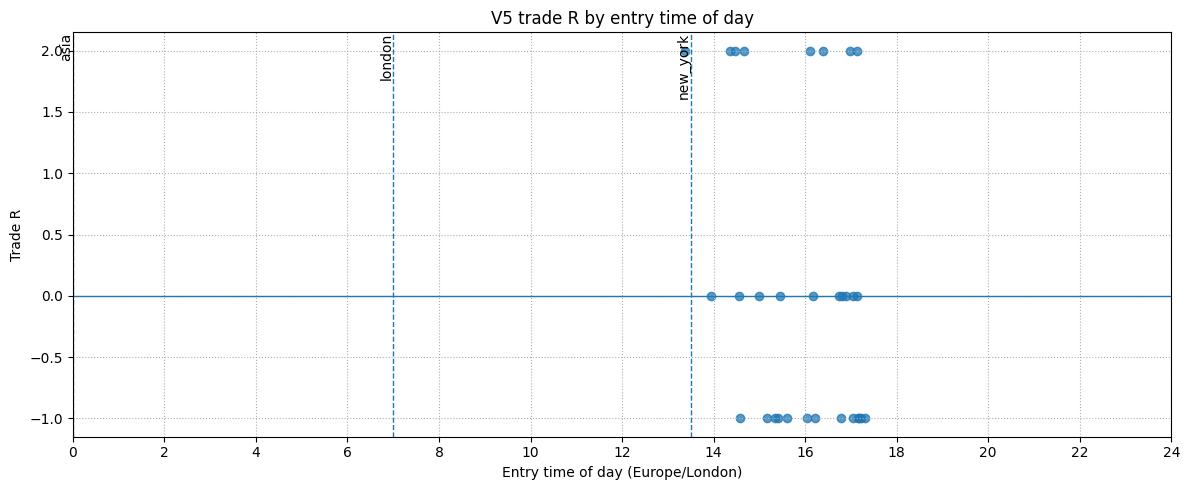

In [57]:
# ---------------------------------------------------------------------
# V5 time-of-day / session chart
# ---------------------------------------------------------------------

def v5_time_to_decimal_hour(time_text: str) -> float:
    """
    Convert HH:MM text into decimal hours.
    """
    hour, minute = str(time_text).split(":")
    return int(hour) + int(minute) / 60.0


def v5_add_session_boundaries_to_axis(ax, config: dict) -> None:
    """
    Add vertical dotted session boundary lines to a matplotlib axis.
    """
    session_windows = config.get("session_windows", {})

    for session_name, window in session_windows.items():
        try:
            start_text, _ = window
            boundary_hour = v5_time_to_decimal_hour(start_text)
        except Exception:
            continue

        ax.axvline(boundary_hour, linestyle="--", linewidth=1)
        ax.text(
            boundary_hour,
            ax.get_ylim()[1],
            session_name,
            rotation=90,
            va="top",
            ha="right",
        )


def plot_v5_session_time_chart(
    trades: pd.DataFrame,
    config: dict,
    report_charts_dir: Path | None = None,
) -> Path | None:
    """
    Plot closed-trade R by entry time of day.
    """
    if not config.get("plot_session_time_chart", True):
        print("V5 session/time-of-day chart disabled in CONFIG.")
        return None

    trades = v5_safe_trades_df(trades)

    if trades.empty:
        print("No trades available for V5 session/time-of-day chart.")
        return None

    chart_df = trades.copy()

    if "entry_hour" in chart_df.columns and "entry_minute" in chart_df.columns:
        chart_df["entry_decimal_hour"] = (
            pd.to_numeric(chart_df["entry_hour"], errors="coerce")
            + pd.to_numeric(chart_df["entry_minute"], errors="coerce") / 60.0
        )
    else:
        entry_times = pd.to_datetime(chart_df["entry_time"], errors="coerce")
        chart_df["entry_decimal_hour"] = (
            entry_times.dt.hour
            + entry_times.dt.minute / 60.0
        )

    chart_df = chart_df.dropna(subset=["entry_decimal_hour", "r_multiple"]).copy()

    if chart_df.empty:
        print("No valid entry times available for V5 session/time-of-day chart.")
        return None

    chart_df = chart_df.sort_values("entry_decimal_hour")

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.scatter(
        chart_df["entry_decimal_hour"],
        chart_df["r_multiple"],
        alpha=0.75,
    )

    ax.axhline(0.0, linewidth=1)
    v5_add_session_boundaries_to_axis(ax, config)

    ax.set_title("V5 trade R by entry time of day")
    ax.set_xlabel(f"Entry time of day ({config.get('session_timezone', 'session time')})")
    ax.set_ylabel("Trade R")
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
    ax.grid(True, linestyle=":", linewidth=0.8)

    plt.tight_layout()

    chart_path = None

    if report_charts_dir is not None:
        report_charts_dir.mkdir(parents=True, exist_ok=True)

        safe_strategy = make_safe_filename_part(config["strategy_version"])
        safe_dataset = make_safe_filename_part(config["dataset_name"])

        chart_path = (
            report_charts_dir
            / f"{safe_strategy}__{safe_dataset}__v5_session_time_r_scatter.png"
        )

        fig.savefig(
            chart_path,
            dpi=180,
            bbox_inches="tight",
        )

        print(f"Saved V5 session/time-of-day chart: {chart_path.relative_to(PROJECT_ROOT)}")

    plt.show()

    return chart_path


v5_session_time_chart_path = plot_v5_session_time_chart(
    trades_df,
    CONFIG,
    report_charts_dir=ARTIFACTS_DIR / "report_charts",
)

In [58]:
def run_v3_backtest_for_dataset(base_config: dict, dataset_config: dict) -> dict:
    """
    Run the active automated VWAP V3 strategy on one comparison dataset.
    """
    run_config = base_config.copy()
    run_config.update(dataset_config)

    raw_df_local, data_file_local = load_market_data(run_config)

    engine_df_local = build_existing_engine_output(raw_df_local, ENGINE_CONFIG)
    automation_df_local = prepare_automation_dataframe(engine_df_local)
    features_df_local = add_automation_features(automation_df_local, run_config)
    signals_df_local = add_v1_green_signals(features_df_local, run_config)

    skipped_signal_candidates_df_local = signals_df_local[
        (signals_df_local["raw_signal_name"] != "NO_SIGNAL")
        & (signals_df_local["v1_signal_name"] == "NO_SIGNAL")
    ].copy()

    trades_df_local, daily_summary_df_local, skipped_execution_signals_df_local = run_v1_trade_simulation_with_daily_controls(
        signals_df_local,
        run_config,
    )

    summary = build_performance_summary(
        raw_ohlc_df=raw_df_local,
        signals_df=signals_df_local,
        trades_df=trades_df_local,
        skipped_signal_candidates_df=skipped_signal_candidates_df_local,
        skipped_execution_signals_df=skipped_execution_signals_df_local,
        config=run_config,
        data_file=data_file_local,
    )

    return summary

In [59]:
# Compare active V4 dynamic regime strategy across configured datasets

comparison_summaries = []

for dataset_config in CONFIG["comparison_datasets"]:
    print("=" * 90)
    print(f"Running active V4 dynamic regime strategy on: {dataset_config['dataset_name']}")
    print("=" * 90)

    summary = run_v3_backtest_for_dataset(CONFIG, dataset_config)
    comparison_summaries.append(summary)


comparison_table = pd.DataFrame(
    [
        {
            "Dataset": summary["dataset_name"],
            "Rows": summary["number_of_rows"],
            "Raw Signals": summary["number_of_raw_signals"],
            "Final Signals": summary["number_of_final_signals"],
            "Trades": summary["number_of_trades"],
            "TP": summary["tp_count"],
            "SL": summary["sl_count"],
            "BE": summary["be_count"],
            "TP Rate": f"{summary['tp_rate']:.2%}",
            "SL Rate": f"{summary['sl_rate']:.2%}",
            "BE Rate": f"{summary['be_rate']:.2%}",
            "WR ex BE": f"{summary['win_rate_excluding_be']:.2%}",
            "Total R": f"{summary['total_r']:.2f}R",
            "Avg R": f"{summary['average_r']:.3f}R",
            "Account %": f"{summary['total_account_pct']:.2f}%",
            "Points": f"{summary['total_points']:.2f}",
            "Avg Bars": f"{summary['average_bars_held']:.2f}",
            "Skipped": summary["total_skipped_signals"],
        }
        for summary in comparison_summaries
    ]
)

comparison_table

Running active V4 dynamic regime strategy on: US100_cash_M1_NY_session_30d
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.
Running active V4 dynamic regime strategy on: US100_cash_M1_NY_session_1y
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.
Running active V4 dynamic regime strategy on: US100_cash_M1_NY_session_calm_2021_partial
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 14.335917
   Min sigma  : 4.623100
   Max sigma  : 93.398899
   Floor used : 4.623100
All required engine output columns are available.
A

,Dataset,Rows,Raw Signals,Final Signals,Trades,TP,SL,BE,TP Rate,SL Rate,BE Rate,WR ex BE,Total R,Avg R,Account %,Points,Avg Bars,Skipped
0,US100_cash_M1_NY_session_30d,6728,88,45,31,8,13,10,25.81%,41.94%,32.26%,38.10%,3.00R,0.097R,3.00%,87.00,12.87,57
1,US100_cash_M1_NY_session_1y,51666,531,219,142,45,62,35,31.69%,43.66%,24.65%,42.06%,28.00R,0.197R,28.00%,812.00,47.30,389
2,US100_cash_M1_NY_session_calm_2021_partial,16093,142,49,36,13,19,4,36.11%,52.78%,11.11%,40.62%,7.00R,0.194R,7.00%,203.00,47.83,106
3,US100_cash_M1_NY_session_volatile_2022,51568,529,234,135,41,63,31,30.37%,46.67%,22.96%,39.42%,19.00R,0.141R,19.00%,551.00,48.21,394
4,US100_cash_M1_NY_session_ukraine_war_2022_2023,51568,539,236,133,42,61,30,31.58%,45.86%,22.56%,40.78%,23.00R,0.173R,23.00%,667.00,48.86,406
5,US100_cash_M1_NY_session_recent_2025_2026,51666,575,240,151,48,69,34,31.79%,45.70%,22.52%,41.03%,27.00R,0.179R,27.00%,783.00,42.01,424


## Synthetic FTMO-Style $200k Account Curve

This section creates a GitHub-ready synthetic account curve using the 1Y comparison dataset.

The chart starts from a hypothetical $200,000 account and converts each closed trade's account percentage return into synthetic dollar PnL.

This is a closed-trade proxy only. It is not an official FTMO rule checker because it does not include floating PnL, intratrade equity movement, commissions, swaps, spreads, or real-time equity rule checks.

Running synthetic FTMO-style chart for:
{'csv_file': 'US100_cash_M1_NY_session_1y.csv', 'dataset_name': 'US100_cash_M1_NY_session_1y'}
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.


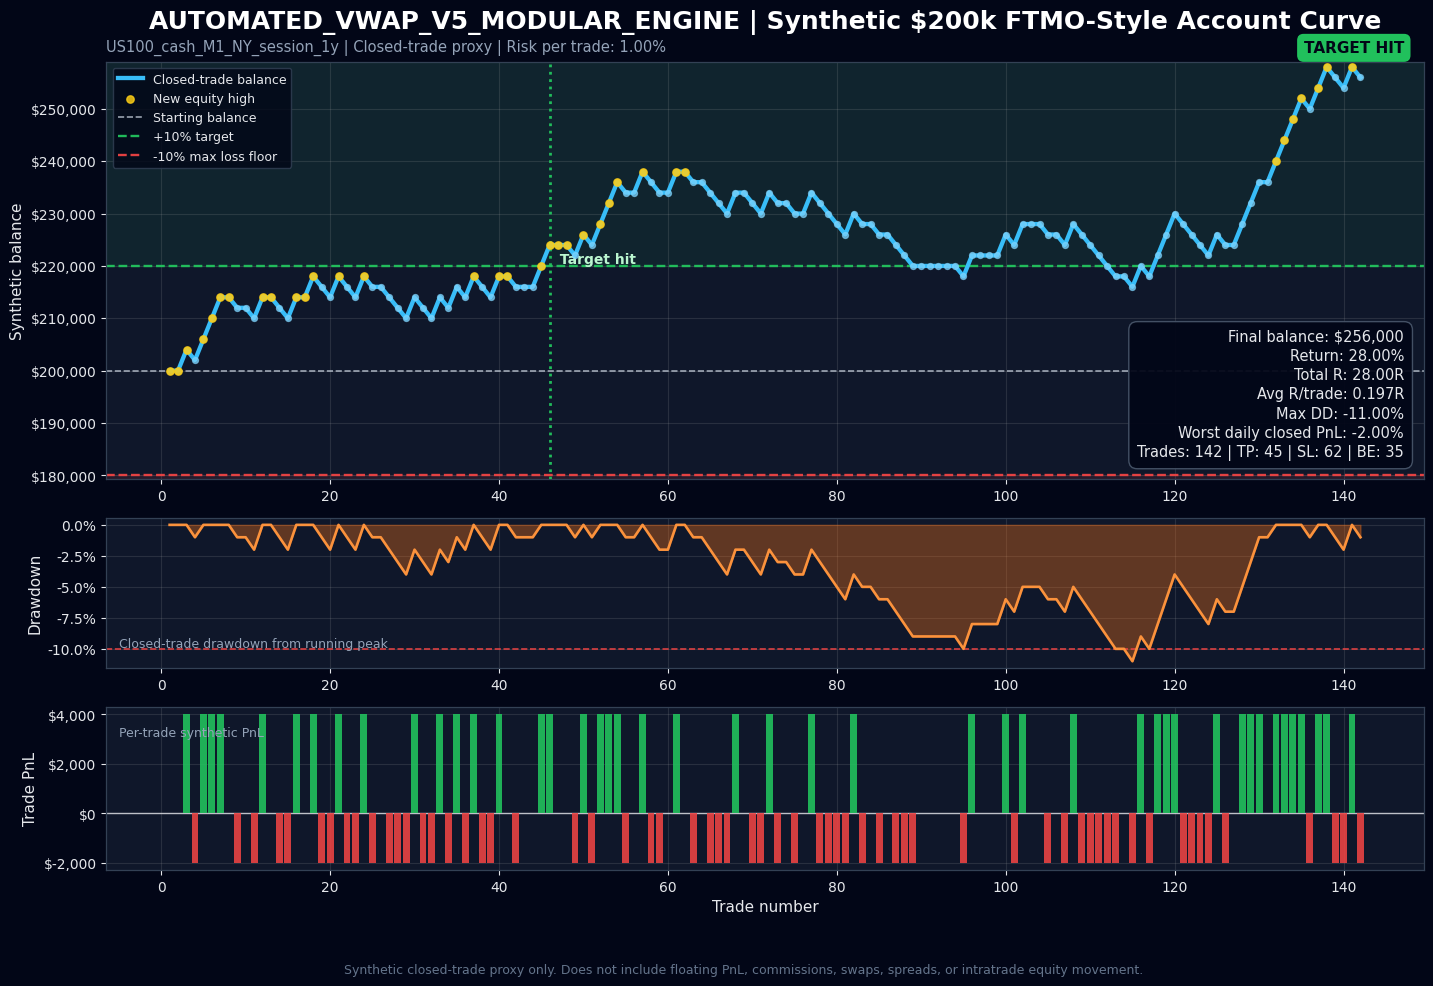

Saved synthetic FTMO-style chart: artifacts\report_charts\automated_vwap_v5_modular_engine__US100_cash_M1_NY_session_1y__ftmo_200k_synthetic_equity.png


In [60]:
# ------------------------------------------------------------------
# Synthetic FTMO-style $200k account report chart
# ------------------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ------------------------------------------------------------------
# Report chart dataset selector
# ------------------------------------------------------------------
# Choose which configured comparison dataset gets the flashy FTMO-style chart.
#
# Option 1: select by exact dataset name
# Option 2: select by row/index from CONFIG["comparison_datasets"]
#
# For your current table:
# 0 = US100_cash_M1_NY_session_30d
# 1 = US100_cash_M1_NY_session_1y

REPORT_CHART_DATASET_NAME = "US100_cash_M1_NY_session_1y"
REPORT_CHART_DATASET_INDEX = None


FTMO_SYNTHETIC_CONFIG = {
    "initial_balance": 200_000.0,
    "profit_target_pct": 10.0,
    "max_loss_pct": 10.0,
    "chart_dpi": 240,
}


def select_report_chart_dataset_config(
    config: dict,
    dataset_name: str | None = None,
    dataset_index: int | None = None,
) -> dict:
    """
    Select one dataset from CONFIG['comparison_datasets'] for the report chart.
    """
    comparison_datasets = config["comparison_datasets"]

    if dataset_index is not None:
        return comparison_datasets[int(dataset_index)]

    if dataset_name is not None:
        matches = [
            dataset_config
            for dataset_config in comparison_datasets
            if dataset_config.get("dataset_name") == dataset_name
        ]

        if len(matches) == 0:
            available_names = [
                dataset_config.get("dataset_name")
                for dataset_config in comparison_datasets
            ]

            raise ValueError(
                f"No dataset matched REPORT_CHART_DATASET_NAME={dataset_name!r}.\n"
                f"Available datasets: {available_names}"
            )

        return matches[0]

    return comparison_datasets[-1]


def safe_report_filename_part(value: str) -> str:
    """
    Safe filename helper for report chart exports.
    """
    return (
        str(value)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
        .replace("__", "_")
    )


def run_active_strategy_details_for_dataset(base_config: dict, dataset_config: dict) -> dict:
    """
    Run the active notebook strategy on the selected dataset and return the full trade log.

    This version does not depend on run_v1/v2/v3_backtest_details_for_dataset being loaded.
    It directly uses the same core pipeline already used by the notebook comparison table.
    """
    run_config = base_config.copy()
    run_config.update(dataset_config)

    raw_df_local, data_file_local = load_market_data(run_config)

    engine_df_local = build_existing_engine_output(raw_df_local, ENGINE_CONFIG)
    automation_df_local = prepare_automation_dataframe(engine_df_local)
    features_df_local = add_automation_features(automation_df_local, run_config)
    signals_df_local = add_v1_green_signals(features_df_local, run_config)

    trades_df_local, daily_summary_df_local, skipped_execution_signals_df_local = (
        run_v1_trade_simulation_with_daily_controls(
            signals_df_local,
            run_config,
        )
    )

    return {
        "config": run_config,
        "dataset_name": run_config["dataset_name"],
        "trades_df": trades_df_local,
        "daily_summary_df": daily_summary_df_local,
        "data_file": data_file_local,
    }


def build_synthetic_account_curve(
    trades: pd.DataFrame,
    config: dict,
    synthetic_config: dict,
) -> pd.DataFrame:
    """
    Build a closed-trade synthetic $200k account curve.

    This is a synthetic reporting curve, not an official prop-firm rule engine.
    """
    if trades is None or len(trades) == 0:
        return pd.DataFrame()

    curve = trades.sort_values("entry_time").reset_index(drop=True).copy()

    initial_balance = float(synthetic_config["initial_balance"])

    curve["trade_number"] = np.arange(1, len(curve) + 1)

    if "account_pct" in curve.columns:
        curve["trade_account_pct"] = curve["account_pct"].astype(float)
    else:
        curve["trade_account_pct"] = (
            curve["r_multiple"].astype(float) * float(config["risk_per_trade_pct"])
        )

    curve["trade_pnl_usd"] = initial_balance * curve["trade_account_pct"] / 100.0

    curve["balance_before_trade"] = (
        initial_balance + curve["trade_pnl_usd"].cumsum().shift(fill_value=0.0)
    )
    curve["balance_after_trade"] = initial_balance + curve["trade_pnl_usd"].cumsum()

    curve["return_pct"] = 100.0 * (
        curve["balance_after_trade"] / initial_balance - 1.0
    )

    curve["running_peak_balance"] = curve["balance_after_trade"].cummax()
    curve["drawdown_usd"] = (
        curve["balance_after_trade"] - curve["running_peak_balance"]
    )
    curve["drawdown_pct_initial"] = (
        100.0 * curve["drawdown_usd"] / initial_balance
    )

    if "session_date" in curve.columns:
        curve["session_date"] = pd.to_datetime(curve["session_date"]).dt.date
    else:
        curve["session_date"] = pd.to_datetime(curve["exit_time"]).dt.date

    curve["daily_closed_pnl_usd"] = curve.groupby("session_date")[
        "trade_pnl_usd"
    ].cumsum()
    curve["daily_closed_pnl_pct_initial"] = (
        100.0 * curve["daily_closed_pnl_usd"] / initial_balance
    )

    curve["is_new_equity_high"] = (
        curve["balance_after_trade"] >= curve["balance_after_trade"].cummax()
    )

    curve["strategy_version"] = config["strategy_version"]
    curve["dataset_name"] = config["dataset_name"]

    return curve


def usd_formatter(value, _):
    return f"${value:,.0f}"


def pct_formatter(value, _):
    return f"{value:.1f}%"


def plot_synthetic_ftmo_account_curve(
    account_curve: pd.DataFrame,
    config: dict,
    synthetic_config: dict,
    report_charts_dir: Path,
) -> Path | None:
    """
    Save a polished synthetic FTMO-style account chart for GitHub.
    """
    if account_curve is None or len(account_curve) == 0:
        print("No trades available, so no synthetic account chart was created.")
        return None

    report_charts_dir.mkdir(parents=True, exist_ok=True)

    initial_balance = float(synthetic_config["initial_balance"])
    profit_target_pct = float(synthetic_config["profit_target_pct"])
    max_loss_pct = float(synthetic_config["max_loss_pct"])

    profit_target_balance = initial_balance * (1.0 + profit_target_pct / 100.0)
    max_loss_floor = initial_balance * (1.0 - max_loss_pct / 100.0)

    final_balance = float(account_curve["balance_after_trade"].iloc[-1])
    final_return_pct = 100.0 * (final_balance / initial_balance - 1.0)

    max_balance = float(account_curve["balance_after_trade"].max())
    min_balance = float(account_curve["balance_after_trade"].min())

    max_drawdown_pct = float(account_curve["drawdown_pct_initial"].min())
    worst_daily_closed_pnl_pct = float(
        account_curve["daily_closed_pnl_pct_initial"].min()
    )

    total_r = float(account_curve["r_multiple"].sum())
    average_r = float(account_curve["r_multiple"].mean())

    tp_count = int((account_curve["result"] == "TP").sum())
    sl_count = int((account_curve["result"] == "SL").sum())
    be_count = int((account_curve["result"] == "BE").sum())

    hit_profit_target = bool(
        (account_curve["balance_after_trade"] >= profit_target_balance).any()
    )
    hit_max_loss = bool(
        (account_curve["balance_after_trade"] <= max_loss_floor).any()
    )

    if hit_max_loss:
        status = "MAX LOSS HIT"
        badge_colour = "#ef4444"
    elif hit_profit_target:
        status = "TARGET HIT"
        badge_colour = "#22c55e"
    else:
        status = "TARGET NOT HIT"
        badge_colour = "#f59e0b"

    safe_strategy = safe_report_filename_part(config["strategy_version"])
    safe_dataset = safe_report_filename_part(config["dataset_name"])

    chart_path = (
        report_charts_dir
        / f"{safe_strategy}__{safe_dataset}__ftmo_200k_synthetic_equity.png"
    )

    x = account_curve["trade_number"].to_numpy()
    balance = account_curve["balance_after_trade"].astype(float).to_numpy()
    drawdown = account_curve["drawdown_pct_initial"].astype(float).to_numpy()
    pnl = account_curve["trade_pnl_usd"].astype(float).to_numpy()

    bar_colours = np.where(pnl >= 0, "#22c55e", "#ef4444")

    fig = plt.figure(figsize=(17, 10.5), facecolor="#020617")
    grid = fig.add_gridspec(
        3,
        1,
        height_ratios=[3.2, 1.15, 1.25],
        hspace=0.16,
    )

    ax_equity = fig.add_subplot(grid[0])
    ax_dd = fig.add_subplot(grid[1], sharex=ax_equity)
    ax_pnl = fig.add_subplot(grid[2], sharex=ax_equity)

    for ax in [ax_equity, ax_dd, ax_pnl]:
        ax.set_facecolor("#0f172a")
        ax.grid(True, alpha=0.16, linewidth=0.8)
        ax.tick_params(colors="#e5e7eb", labelsize=10)

        for spine in ax.spines.values():
            spine.set_color("#334155")
            spine.set_linewidth(0.9)

    # ------------------------------------------------------------------
    # Equity panel
    # ------------------------------------------------------------------
    y_top = max(max_balance, profit_target_balance) * 1.004
    y_bottom = min(min_balance, max_loss_floor) * 0.996

    ax_equity.axhspan(
        profit_target_balance,
        y_top,
        color="#22c55e",
        alpha=0.08,
    )

    ax_equity.axhspan(
        y_bottom,
        max_loss_floor,
        color="#ef4444",
        alpha=0.10,
    )

    ax_equity.plot(
        x,
        balance,
        linewidth=3.1,
        color="#38bdf8",
        label="Closed-trade balance",
        zorder=4,
    )

    ax_equity.scatter(
        x,
        balance,
        s=18,
        color="#7dd3fc",
        alpha=0.70,
        zorder=5,
    )

    new_highs = account_curve[account_curve["is_new_equity_high"]].copy()

    if len(new_highs) > 0:
        ax_equity.scatter(
            new_highs["trade_number"],
            new_highs["balance_after_trade"],
            s=28,
            color="#facc15",
            alpha=0.85,
            label="New equity high",
            zorder=6,
        )

    ax_equity.axhline(
        initial_balance,
        color="#cbd5e1",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Starting balance",
    )

    ax_equity.axhline(
        profit_target_balance,
        color="#22c55e",
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label=f"+{profit_target_pct:.0f}% target",
    )

    ax_equity.axhline(
        max_loss_floor,
        color="#ef4444",
        linestyle="--",
        linewidth=1.7,
        alpha=0.95,
        label=f"-{max_loss_pct:.0f}% max loss floor",
    )

    target_hits = account_curve[
        account_curve["balance_after_trade"] >= profit_target_balance
    ]

    if len(target_hits) > 0:
        first_target_trade = int(target_hits["trade_number"].iloc[0])

        ax_equity.axvline(
            first_target_trade,
            color="#22c55e",
            linestyle=":",
            linewidth=2.0,
            alpha=0.95,
            zorder=3,
        )

        ax_equity.text(
            first_target_trade,
            profit_target_balance,
            "  Target hit",
            color="#bbf7d0",
            fontsize=10,
            fontweight="bold",
            va="bottom",
            ha="left",
        )

    loss_hits = account_curve[
        account_curve["balance_after_trade"] <= max_loss_floor
    ]

    if len(loss_hits) > 0:
        first_loss_trade = int(loss_hits["trade_number"].iloc[0])

        ax_equity.axvline(
            first_loss_trade,
            color="#ef4444",
            linestyle=":",
            linewidth=2.0,
            alpha=0.95,
            zorder=3,
        )

        ax_equity.text(
            first_loss_trade,
            max_loss_floor,
            "  Max loss hit",
            color="#fecaca",
            fontsize=10,
            fontweight="bold",
            va="top",
            ha="left",
        )

    ax_equity.set_ylim(y_bottom, y_top)
    ax_equity.yaxis.set_major_formatter(FuncFormatter(usd_formatter))
    ax_equity.set_ylabel("Synthetic balance", color="#e5e7eb", fontsize=11)

    title = (
        f"{config['strategy_version'].upper()} | "
        f"Synthetic $200k FTMO-Style Account Curve"
    )

    subtitle = (
        f"{config['dataset_name']} | "
        f"Closed-trade proxy | "
        f"Risk per trade: {config['risk_per_trade_pct']:.2f}%"
    )

    ax_equity.set_title(
        title,
        color="white",
        fontsize=18,
        fontweight="bold",
        pad=24,
    )

    ax_equity.text(
        0.0,
        1.015,
        subtitle,
        transform=ax_equity.transAxes,
        ha="left",
        va="bottom",
        fontsize=10.5,
        color="#94a3b8",
    )

    ax_equity.text(
        0.985,
        1.015,
        status,
        transform=ax_equity.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        color="#020617",
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.38",
            facecolor=badge_colour,
            edgecolor=badge_colour,
            alpha=0.98,
        ),
    )

    stats_text = (
        f"Final balance: ${final_balance:,.0f}\n"
        f"Return: {final_return_pct:.2f}%\n"
        f"Total R: {total_r:.2f}R\n"
        f"Avg R/trade: {average_r:.3f}R\n"
        f"Max DD: {max_drawdown_pct:.2f}%\n"
        f"Worst daily closed PnL: {worst_daily_closed_pnl_pct:.2f}%\n"
        f"Trades: {len(account_curve)} | TP: {tp_count} | SL: {sl_count} | BE: {be_count}"
    )

    ax_equity.text(
        0.985,
        0.045,
        stats_text,
        transform=ax_equity.transAxes,
        ha="right",
        va="bottom",
        fontsize=10.5,
        color="#e5e7eb",
        linespacing=1.35,
        bbox=dict(
            boxstyle="round,pad=0.58",
            facecolor="#020617",
            edgecolor="#475569",
            alpha=0.94,
        ),
    )

    ax_equity.legend(
        loc="upper left",
        frameon=True,
        facecolor="#020617",
        edgecolor="#334155",
        labelcolor="#e5e7eb",
        fontsize=9,
    )

    # ------------------------------------------------------------------
    # Drawdown panel
    # ------------------------------------------------------------------
    ax_dd.fill_between(
        x,
        drawdown,
        0,
        color="#f97316",
        alpha=0.35,
        zorder=2,
    )

    ax_dd.plot(
        x,
        drawdown,
        color="#fb923c",
        linewidth=1.9,
        zorder=3,
    )

    ax_dd.axhline(
        -max_loss_pct,
        color="#ef4444",
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    ax_dd.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
    ax_dd.set_ylabel("Drawdown", color="#e5e7eb", fontsize=11)

    ax_dd.text(
        0.01,
        0.12,
        "Closed-trade drawdown from running peak",
        transform=ax_dd.transAxes,
        ha="left",
        va="bottom",
        fontsize=9,
        color="#94a3b8",
    )

    # ------------------------------------------------------------------
    # Trade PnL panel
    # ------------------------------------------------------------------
    ax_pnl.bar(
        x,
        pnl,
        color=bar_colours,
        alpha=0.88,
        width=0.82,
        zorder=3,
    )

    ax_pnl.axhline(
        0,
        color="#e5e7eb",
        linewidth=1.0,
        alpha=0.8,
    )

    ax_pnl.yaxis.set_major_formatter(FuncFormatter(usd_formatter))
    ax_pnl.set_ylabel("Trade PnL", color="#e5e7eb", fontsize=11)
    ax_pnl.set_xlabel("Trade number", color="#e5e7eb", fontsize=11)

    ax_pnl.text(
        0.01,
        0.88,
        "Per-trade synthetic PnL",
        transform=ax_pnl.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color="#94a3b8",
    )

    fig.text(
        0.5,
        0.012,
        (
            "Synthetic closed-trade proxy only. "
            "Does not include floating PnL, commissions, swaps, spreads, "
            "or intratrade equity movement."
        ),
        ha="center",
        color="#64748b",
        fontsize=9,
    )

    fig.savefig(
        chart_path,
        dpi=int(synthetic_config["chart_dpi"]),
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )

    plt.show()

    print(f"Saved synthetic FTMO-style chart: {chart_path.relative_to(PROJECT_ROOT)}")

    return chart_path


REPORT_DATASET_CONFIG = select_report_chart_dataset_config(
    config=CONFIG,
    dataset_name=REPORT_CHART_DATASET_NAME,
    dataset_index=REPORT_CHART_DATASET_INDEX,
)

print("Running synthetic FTMO-style chart for:")
print(REPORT_DATASET_CONFIG)

report_backtest = run_active_strategy_details_for_dataset(
    base_config=CONFIG,
    dataset_config=REPORT_DATASET_CONFIG,
)

synthetic_account_curve_df = build_synthetic_account_curve(
    trades=report_backtest["trades_df"],
    config=report_backtest["config"],
    synthetic_config=FTMO_SYNTHETIC_CONFIG,
)

synthetic_ftmo_chart_path = plot_synthetic_ftmo_account_curve(
    account_curve=synthetic_account_curve_df,
    config=report_backtest["config"],
    synthetic_config=FTMO_SYNTHETIC_CONFIG,
    report_charts_dir=ARTIFACTS_DIR / "report_charts",
)

## Compact Trade Audit

This section prints compact trade diagnostics for the selected report dataset.

The goal is to identify bad periods without flooding the notebook output with hundreds of trade rows. The full trade log is saved to `artifacts/trade_audits/`, while the notebook only displays monthly performance, worst rolling windows, loss streaks, and a truncated trade preview.

In [61]:
# ------------------------------------------------------------------
# Compact trade audit diagnostics
# ------------------------------------------------------------------

TRADE_AUDIT_CONFIG = {
    # Uses the same selected dataset as the FTMO-style report chart by default.
    "dataset_name": REPORT_CHART_DATASET_NAME,
    "dataset_index": REPORT_CHART_DATASET_INDEX,

    # Notebook display controls
    "trade_log_preview_rows": 80,
    "bad_months_to_show": 12,
    "loss_streaks_to_show": 12,
    "worst_windows_to_show": 15,

    # Rolling windows measured in number of closed trades
    "rolling_trade_windows": [5, 10, 20],

    # Save full detailed trade log to artifacts
    "save_full_trade_log_csv": True,
}


def select_trade_audit_dataset_config(
    config: dict,
    dataset_name: str | None = None,
    dataset_index: int | None = None,
) -> dict:
    """
    Select one dataset from CONFIG['comparison_datasets'] for compact trade audit diagnostics.
    """
    comparison_datasets = config["comparison_datasets"]

    if dataset_index is not None:
        return comparison_datasets[int(dataset_index)]

    if dataset_name is not None:
        matches = [
            dataset_config
            for dataset_config in comparison_datasets
            if dataset_config.get("dataset_name") == dataset_name
        ]

        if len(matches) == 0:
            available_names = [
                dataset_config.get("dataset_name")
                for dataset_config in comparison_datasets
            ]

            raise ValueError(
                f"No dataset matched TRADE_AUDIT_CONFIG['dataset_name']={dataset_name!r}.\n"
                f"Available datasets: {available_names}"
            )

        return matches[0]

    return comparison_datasets[-1]


def max_consecutive_losses(results: pd.Series, r_multiples: pd.Series) -> int:
    """
    Calculate max consecutive losing trades for a grouped period.
    """
    is_loss = (results.astype(str).str.upper() == "SL") | (r_multiples.astype(float) < 0)

    max_streak = 0
    current_streak = 0

    for loss in is_loss:
        if loss:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0

    return int(max_streak)


def build_trade_audit_dataframe(trades_df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Build a clean trade audit dataframe with useful date/time columns.
    """
    if trades_df is None or len(trades_df) == 0:
        return pd.DataFrame()

    audit_df = trades_df.copy()

    audit_df["entry_time"] = pd.to_datetime(audit_df["entry_time"], utc=True).dt.tz_convert(None)
    audit_df["exit_time"] = pd.to_datetime(audit_df["exit_time"], utc=True).dt.tz_convert(None)

    if "session_date" in audit_df.columns:
        audit_df["session_date"] = pd.to_datetime(audit_df["session_date"]).dt.date
    else:
        audit_df["session_date"] = audit_df["exit_time"].dt.date

    audit_df = audit_df.sort_values("entry_time").reset_index(drop=True)

    audit_df["trade_number"] = np.arange(1, len(audit_df) + 1)
    audit_df["exit_month"] = audit_df["exit_time"].dt.to_period("M").astype(str)
    audit_df["exit_week"] = audit_df["exit_time"].dt.to_period("W").astype(str)

    if "account_pct" not in audit_df.columns:
        audit_df["account_pct"] = (
            audit_df["r_multiple"].astype(float) * float(config["risk_per_trade_pct"])
        )

    audit_df["is_win"] = audit_df["r_multiple"].astype(float) > 0
    audit_df["is_loss"] = (
        (audit_df["result"].astype(str).str.upper() == "SL")
        | (audit_df["r_multiple"].astype(float) < 0)
    )

    audit_df["cumulative_r"] = audit_df["r_multiple"].astype(float).cumsum()
    audit_df["cumulative_account_pct"] = audit_df["account_pct"].astype(float).cumsum()

    audit_df["running_peak_r"] = audit_df["cumulative_r"].cummax()
    audit_df["drawdown_r"] = audit_df["cumulative_r"] - audit_df["running_peak_r"]

    return audit_df


def build_monthly_trade_audit(audit_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarise performance by calendar month.
    """
    if audit_df is None or len(audit_df) == 0:
        return pd.DataFrame()

    monthly_rows = []

    for month, month_df in audit_df.groupby("exit_month"):
        trades = len(month_df)
        wins = int((month_df["r_multiple"] > 0).sum())
        losses = int((month_df["r_multiple"] < 0).sum())

        monthly_rows.append(
            {
                "month": month,
                "first_trade": month_df["entry_time"].min(),
                "last_trade": month_df["exit_time"].max(),
                "trades": trades,
                "wins": wins,
                "losses": losses,
                "win_rate_pct": 100.0 * wins / trades if trades > 0 else 0.0,
                "total_r": float(month_df["r_multiple"].sum()),
                "account_pct": float(month_df["account_pct"].sum()),
                "avg_r": float(month_df["r_multiple"].mean()),
                "worst_trade_r": float(month_df["r_multiple"].min()),
                "best_trade_r": float(month_df["r_multiple"].max()),
                "max_consecutive_losses": max_consecutive_losses(
                    month_df["result"],
                    month_df["r_multiple"],
                ),
            }
        )

    monthly_audit_df = pd.DataFrame(monthly_rows)

    return monthly_audit_df.sort_values("month").reset_index(drop=True)


def build_loss_streak_audit(audit_df: pd.DataFrame) -> pd.DataFrame:
    """
    Find consecutive losing streaks and summarise when they happened.
    """
    if audit_df is None or len(audit_df) == 0:
        return pd.DataFrame()

    streak_df = audit_df.copy()
    streak_df["loss_block_id"] = (
        streak_df["is_loss"] != streak_df["is_loss"].shift(fill_value=False)
    ).cumsum()

    loss_streak_rows = []

    for _, block_df in streak_df[streak_df["is_loss"]].groupby("loss_block_id"):
        loss_streak_rows.append(
            {
                "start_trade": int(block_df["trade_number"].min()),
                "end_trade": int(block_df["trade_number"].max()),
                "start_time": block_df["entry_time"].min(),
                "end_time": block_df["exit_time"].max(),
                "start_date": block_df["entry_time"].min().date(),
                "end_date": block_df["exit_time"].max().date(),
                "loss_count": int(len(block_df)),
                "total_r": float(block_df["r_multiple"].sum()),
                "account_pct": float(block_df["account_pct"].sum()),
                "results": " → ".join(block_df["result"].astype(str).tolist()),
            }
        )

    loss_streaks_df = pd.DataFrame(loss_streak_rows)

    if len(loss_streaks_df) == 0:
        return loss_streaks_df

    return loss_streaks_df.sort_values(
        by=["loss_count", "total_r"],
        ascending=[False, True],
    ).reset_index(drop=True)


def build_worst_rolling_windows(
    audit_df: pd.DataFrame,
    windows: list[int],
    top_n: int,
) -> pd.DataFrame:
    """
    Find the worst rolling windows measured by number of closed trades.
    """
    if audit_df is None or len(audit_df) == 0:
        return pd.DataFrame()

    rolling_rows = []

    for window in windows:
        if len(audit_df) < window:
            continue

        rolling_r = audit_df["r_multiple"].astype(float).rolling(window).sum()
        rolling_account_pct = audit_df["account_pct"].astype(float).rolling(window).sum()

        temp_df = audit_df.copy()
        temp_df["rolling_total_r"] = rolling_r
        temp_df["rolling_account_pct"] = rolling_account_pct

        temp_df = temp_df.dropna(subset=["rolling_total_r"]).copy()

        for idx, row in temp_df.nsmallest(top_n, "rolling_total_r").iterrows():
            end_position = int(idx)
            start_position = end_position - window + 1

            start_row = audit_df.iloc[start_position]
            end_row = audit_df.iloc[end_position]

            window_slice = audit_df.iloc[start_position : end_position + 1]

            rolling_rows.append(
                {
                    "window_trades": int(window),
                    "start_trade": int(start_row["trade_number"]),
                    "end_trade": int(end_row["trade_number"]),
                    "start_time": start_row["entry_time"],
                    "end_time": end_row["exit_time"],
                    "start_date": start_row["entry_time"].date(),
                    "end_date": end_row["exit_time"].date(),
                    "total_r": float(row["rolling_total_r"]),
                    "account_pct": float(row["rolling_account_pct"]),
                    "wins": int((window_slice["r_multiple"] > 0).sum()),
                    "losses": int((window_slice["r_multiple"] < 0).sum()),
                    "results": " → ".join(window_slice["result"].astype(str).tolist()),
                }
            )

    worst_windows_df = pd.DataFrame(rolling_rows)

    if len(worst_windows_df) == 0:
        return worst_windows_df

    return worst_windows_df.sort_values("total_r").reset_index(drop=True)


def save_full_trade_audit_csv(
    audit_df: pd.DataFrame,
    config: dict,
    output_dir: Path,
) -> Path | None:
    """
    Save the full trade audit log to artifacts/trade_audits.
    """
    if audit_df is None or len(audit_df) == 0:
        return None

    trade_audit_dir = output_dir / "trade_audits"
    trade_audit_dir.mkdir(parents=True, exist_ok=True)

    safe_strategy = safe_report_filename_part(config["strategy_version"])
    safe_dataset = safe_report_filename_part(config["dataset_name"])

    output_path = trade_audit_dir / f"{safe_strategy}__{safe_dataset}__trade_audit.csv"

    audit_df.to_csv(output_path, index=False)

    print(f"Saved full trade audit log: {output_path.relative_to(PROJECT_ROOT)}")

    return output_path


TRADE_AUDIT_DATASET_CONFIG = select_trade_audit_dataset_config(
    config=CONFIG,
    dataset_name=TRADE_AUDIT_CONFIG["dataset_name"],
    dataset_index=TRADE_AUDIT_CONFIG["dataset_index"],
)

print("Running compact trade audit for:")
print(TRADE_AUDIT_DATASET_CONFIG)

trade_audit_backtest = run_active_strategy_details_for_dataset(
    base_config=CONFIG,
    dataset_config=TRADE_AUDIT_DATASET_CONFIG,
)

trade_audit_df = build_trade_audit_dataframe(
    trades_df=trade_audit_backtest["trades_df"],
    config=trade_audit_backtest["config"],
)

monthly_trade_audit_df = build_monthly_trade_audit(trade_audit_df)

loss_streak_audit_df = build_loss_streak_audit(trade_audit_df)

worst_rolling_windows_df = build_worst_rolling_windows(
    audit_df=trade_audit_df,
    windows=TRADE_AUDIT_CONFIG["rolling_trade_windows"],
    top_n=TRADE_AUDIT_CONFIG["worst_windows_to_show"],
)

if TRADE_AUDIT_CONFIG["save_full_trade_log_csv"]:
    full_trade_audit_csv_path = save_full_trade_audit_csv(
        audit_df=trade_audit_df,
        config=trade_audit_backtest["config"],
        output_dir=ARTIFACTS_DIR,
    )

print("\nWorst monthly performance audit:")
display(
    monthly_trade_audit_df.sort_values("total_r")
    .head(TRADE_AUDIT_CONFIG["bad_months_to_show"])
    .reset_index(drop=True)
)

print("\nMonthly performance audit, chronological:")
monthly_chronological_df = monthly_trade_audit_df.sort_values("month").reset_index(drop=True)

monthly_total_row = pd.DataFrame(
    [
        {
            "month": "TOTAL",
            "first_trade": monthly_chronological_df["first_trade"].min(),
            "last_trade": monthly_chronological_df["last_trade"].max(),
            "trades": int(monthly_chronological_df["trades"].sum()),
            "wins": int(monthly_chronological_df["wins"].sum()),
            "losses": int(monthly_chronological_df["losses"].sum()),
            "win_rate_pct": 100.0
            * monthly_chronological_df["wins"].sum()
            / monthly_chronological_df["trades"].sum(),
            "total_r": float(monthly_chronological_df["total_r"].sum()),
            "account_pct": float(monthly_chronological_df["account_pct"].sum()),
            "avg_r": float(trade_audit_df["r_multiple"].mean()),
            "worst_trade_r": float(trade_audit_df["r_multiple"].min()),
            "best_trade_r": float(trade_audit_df["r_multiple"].max()),
            "max_consecutive_losses": int(
                monthly_chronological_df["max_consecutive_losses"].max()
            ),
        }
    ]
)

display(
    pd.concat(
        [monthly_chronological_df, monthly_total_row],
        ignore_index=True,
    )
)

print("\nTrade audit total check:")
print(f"Trade rows: {len(trade_audit_df)}")
print(f"Trade Total R: {trade_audit_df['r_multiple'].sum():.2f}R")
print(f"Monthly Total R: {monthly_chronological_df['total_r'].sum():.2f}R")
print(f"Trade Account %: {trade_audit_df['account_pct'].sum():.2f}%")
print(f"Monthly Account %: {monthly_chronological_df['account_pct'].sum():.2f}%")

print("\nWorst consecutive loss streaks:")
display(
    loss_streak_audit_df.head(
        TRADE_AUDIT_CONFIG["loss_streaks_to_show"]
    )
)

print("\nWorst rolling trade windows:")
display(
    worst_rolling_windows_df.head(
        TRADE_AUDIT_CONFIG["worst_windows_to_show"]
    )
)

trade_preview_columns = [
    "trade_number",
    "entry_time",
    "exit_time",
    "session_date",
    "result",
    "r_multiple",
    "account_pct",
    "cumulative_r",
    "drawdown_r",
]

trade_preview_columns = [
    col for col in trade_preview_columns if col in trade_audit_df.columns
]

print("\nTruncated trade log preview:")
with pd.option_context(
    "display.max_rows",
    TRADE_AUDIT_CONFIG["trade_log_preview_rows"],
    "display.max_columns",
    30,
    "display.width",
    180,
):
    display(
        trade_audit_df[trade_preview_columns].tail(
            TRADE_AUDIT_CONFIG["trade_log_preview_rows"]
        )
    )

Running compact trade audit for:
{'csv_file': 'US100_cash_M1_NY_session_1y.csv', 'dataset_name': 'US100_cash_M1_NY_session_1y'}
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.
Saved full trade audit log: artifacts\trade_audits\automated_vwap_v5_modular_engine__US100_cash_M1_NY_session_1y__trade_audit.csv

Worst monthly performance audit:


,month,first_trade,last_trade,trades,wins,losses,win_rate_pct,total_r,account_pct,avg_r,worst_trade_r,best_trade_r,max_consecutive_losses
0,2026-01,2026-01-02 17:07:00,2026-01-30 15:44:00,9,0,4,0.000000,-4.0,-4.0,-0.444444,-1.0,0.0,3
1,2025-11,2025-11-03 14:29:00,2025-11-28 15:50:00,14,3,9,21.428571,-3.0,-3.0,-0.214286,-1.0,2.0,4
2,2025-12,2025-12-04 16:43:00,2025-12-26 15:50:00,3,0,1,0.000000,-1.0,-1.0,-0.333333,-1.0,0.0,1
3,2025-07,2025-07-01 14:35:00,2025-07-30 15:09:00,17,5,10,29.411765,0.0,0.0,0.000000,-1.0,2.0,3
4,2025-10,2025-10-01 14:14:00,2025-10-30 15:11:00,10,2,4,20.000000,0.0,0.0,0.000000,-1.0,2.0,3
5,2025-08,2025-08-05 14:24:00,2025-08-29 15:05:00,12,4,6,33.333333,2.0,2.0,0.166667,-1.0,2.0,2
6,2026-03,2026-03-03 17:03:00,2026-03-31 13:54:00,11,4,6,36.363636,2.0,2.0,0.181818,-1.0,2.0,3
7,2025-06,2025-06-09 15:53:00,2025-06-30 15:32:00,9,3,3,33.333333,3.0,3.0,0.333333,-1.0,2.0,1
8,2026-02,2026-02-05 14:28:00,2026-02-23 17:19:00,15,4,5,26.666667,3.0,3.0,0.200000,-1.0,2.0,2
9,2025-05,2025-05-16 13:51:00,2025-05-27 15:42:00,5,2,1,40.000000,3.0,3.0,0.600000,-1.0,2.0,1



Monthly performance audit, chronological:


,month,first_trade,last_trade,trades,wins,losses,win_rate_pct,total_r,account_pct,avg_r,worst_trade_r,best_trade_r,max_consecutive_losses
0,2025-05,2025-05-16 13:51:00,2025-05-27 15:42:00,5,2,1,40.000000,3.0,3.0,0.600000,-1.0,2.0,1
1,2025-06,2025-06-09 15:53:00,2025-06-30 15:32:00,9,3,3,33.333333,3.0,3.0,0.333333,-1.0,2.0,1
2,2025-07,2025-07-01 14:35:00,2025-07-30 15:09:00,17,5,10,29.411765,0.0,0.0,0.000000,-1.0,2.0,3
3,2025-08,2025-08-05 14:24:00,2025-08-29 15:05:00,12,4,6,33.333333,2.0,2.0,0.166667,-1.0,2.0,2
4,2025-09,2025-09-01 14:18:00,2025-09-24 13:10:00,16,7,5,43.750000,9.0,9.0,0.562500,-1.0,2.0,2
5,2025-10,2025-10-01 14:14:00,2025-10-30 15:11:00,10,2,4,20.000000,0.0,0.0,0.000000,-1.0,2.0,3
6,2025-11,2025-11-03 14:29:00,2025-11-28 15:50:00,14,3,9,21.428571,-3.0,-3.0,-0.214286,-1.0,2.0,4
7,2025-12,2025-12-04 16:43:00,2025-12-26 15:50:00,3,0,1,0.000000,-1.0,-1.0,-0.333333,-1.0,0.0,1
8,2026-01,2026-01-02 17:07:00,2026-01-30 15:44:00,9,0,4,0.000000,-4.0,-4.0,-0.444444,-1.0,0.0,3
9,2026-02,2026-02-05 14:28:00,2026-02-23 17:19:00,15,4,5,26.666667,3.0,3.0,0.200000,-1.0,2.0,2



Trade audit total check:
Trade rows: 142
Trade Total R: 28.00R
Monthly Total R: 28.00R
Trade Account %: 28.00%
Monthly Account %: 28.00%

Worst consecutive loss streaks:


,start_trade,end_trade,start_time,end_time,start_date,end_date,loss_count,total_r,account_pct,results
0,109,113,2026-02-23 17:10:00,2026-03-05 17:20:00,2026-02-23,2026-03-05,5,-5.0,-5.0,SL → SL → SL → SL → SL
1,78,81,2025-11-19 15:15:00,2025-11-24 15:59:00,2025-11-19,2025-11-24,4,-4.0,-4.0,SL → SL → SL → SL
2,121,124,2026-03-31 13:49:00,2026-04-06 15:46:00,2026-03-31,2026-04-06,4,-4.0,-4.0,SL → SL → SL → SL
3,27,29,2025-07-23 14:15:00,2025-07-29 13:10:00,2025-07-23,2025-07-29,3,-3.0,-3.0,SL → SL → SL
4,65,67,2025-10-15 14:24:00,2025-10-24 15:30:00,2025-10-15,2025-10-24,3,-3.0,-3.0,SL → SL → SL
5,87,89,2026-01-02 17:07:00,2026-01-14 17:15:00,2026-01-02,2026-01-14,3,-3.0,-3.0,SL → SL → SL
6,14,15,2025-06-30 14:49:00,2025-07-01 14:57:00,2025-06-30,2025-07-01,2,-2.0,-2.0,SL → SL
7,19,20,2025-07-07 13:50:00,2025-07-08 16:08:00,2025-07-07,2025-07-08,2,-2.0,-2.0,SL → SL
8,22,23,2025-07-10 15:06:00,2025-07-14 15:22:00,2025-07-10,2025-07-14,2,-2.0,-2.0,SL → SL
9,31,32,2025-07-30 13:50:00,2025-08-05 15:19:00,2025-07-30,2025-08-05,2,-2.0,-2.0,SL → SL



Worst rolling trade windows:


,window_trades,start_trade,end_trade,start_time,end_time,start_date,end_date,total_r,account_pct,wins,losses,results
0,20,70,89,2025-11-03 14:29:00,2026-01-14 17:15:00,2025-11-03,2026-01-14,-7.0,-7.0,3,13,SL → SL → TP → SL → BE → SL → BE → TP → SL → S...
1,20,73,92,2025-11-11 16:37:00,2026-01-22 16:44:00,2025-11-11,2026-01-22,-7.0,-7.0,2,11,SL → BE → SL → BE → TP → SL → SL → SL → SL → T...
2,20,76,95,2025-11-18 14:55:00,2026-01-30 15:44:00,2025-11-18,2026-01-30,-6.0,-6.0,2,10,BE → TP → SL → SL → SL → SL → TP → SL → BE → S...
3,20,75,94,2025-11-17 17:02:00,2026-01-29 16:31:00,2025-11-17,2026-01-29,-6.0,-6.0,2,10,SL → BE → TP → SL → SL → SL → SL → TP → SL → B...
4,20,74,93,2025-11-17 15:11:00,2026-01-26 16:30:00,2025-11-17,2026-01-26,-6.0,-6.0,2,10,BE → SL → BE → TP → SL → SL → SL → SL → TP → S...
5,20,71,90,2025-11-07 15:04:00,2026-01-20 16:45:00,2025-11-07,2026-01-20,-6.0,-6.0,3,12,SL → TP → SL → BE → SL → BE → TP → SL → SL → S...
6,20,69,88,2025-10-30 14:13:00,2026-01-06 15:47:00,2025-10-30,2026-01-06,-6.0,-6.0,3,12,BE → SL → SL → TP → SL → BE → SL → BE → TP → S...
7,20,62,81,2025-10-10 13:57:00,2025-11-24 15:59:00,2025-10-10,2025-11-24,-6.0,-6.0,3,12,BE → SL → BE → SL → SL → SL → TP → BE → SL → S...
8,20,78,97,2025-11-19 15:15:00,2026-02-10 15:18:00,2025-11-19,2026-02-10,-6.0,-6.0,2,10,SL → SL → SL → SL → TP → SL → BE → SL → BE → S...
9,10,104,113,2026-02-18 14:33:00,2026-03-05 17:20:00,2026-02-18,2026-03-05,-5.0,-5.0,1,7,BE → SL → BE → SL → TP → SL → SL → SL → SL → SL



Truncated trade log preview:


,trade_number,entry_time,exit_time,session_date,result,r_multiple,account_pct,cumulative_r,drawdown_r
62,63,2025-10-13 13:23:00,2025-10-13 13:30:00,2025-10-13,SL,-1.0,-1.0,18.0,-1.0
63,64,2025-10-14 14:22:00,2025-10-14 15:05:00,2025-10-14,BE,0.0,0.0,18.0,-1.0
64,65,2025-10-15 14:24:00,2025-10-15 15:03:00,2025-10-15,SL,-1.0,-1.0,17.0,-2.0
65,66,2025-10-17 13:22:00,2025-10-17 13:31:00,2025-10-17,SL,-1.0,-1.0,16.0,-3.0
66,67,2025-10-24 15:27:00,2025-10-24 15:30:00,2025-10-24,SL,-1.0,-1.0,15.0,-4.0
67,68,2025-10-28 14:14:00,2025-10-28 16:03:00,2025-10-28,TP,2.0,2.0,17.0,-2.0
68,69,2025-10-30 14:13:00,2025-10-30 15:11:00,2025-10-30,BE,0.0,0.0,17.0,-2.0
69,70,2025-11-03 14:29:00,2025-11-03 15:56:00,2025-11-03,SL,-1.0,-1.0,16.0,-3.0
70,71,2025-11-07 15:04:00,2025-11-07 15:05:00,2025-11-07,SL,-1.0,-1.0,15.0,-4.0
71,72,2025-11-07 16:58:00,2025-11-07 17:00:00,2025-11-07,TP,2.0,2.0,17.0,-2.0


## Risk Diagnostics

This section checks losing streaks, no-TP runs, and max drawdown in R for each comparison dataset.

The diagnostics use the active V5 modular strategy configuration.

In [62]:
# Active V5 risk diagnostic: max no-TP run and max drawdown for each comparison dataset

def run_v3_backtest_details_for_dataset(base_config: dict, dataset_config: dict) -> dict:
    run_config = base_config.copy()
    run_config.update(dataset_config)

    raw_df, data_file = load_market_data(run_config)

    engine_df_local = build_existing_engine_output(raw_df, ENGINE_CONFIG)
    automation_df_local = prepare_automation_dataframe(engine_df_local)
    features_df_local = add_automation_features(automation_df_local, run_config)
    signals_df_local = add_v1_green_signals(features_df_local, run_config)

    skipped_generation_df_local = signals_df_local[
        (signals_df_local["raw_signal_name"] != "NO_SIGNAL")
        & (signals_df_local["v1_signal_name"] == "NO_SIGNAL")
    ].copy()

    trades_df_local, daily_summary_df_local, skipped_execution_df_local = run_v1_trade_simulation_with_daily_controls(
        signals_df_local,
        run_config,
    )

    return {
        "dataset_name": run_config["dataset_name"],
        "trades_df": trades_df_local,
        "daily_summary_df": daily_summary_df_local,
    }


def calculate_risk_diagnostics(trades: pd.DataFrame) -> dict:
    if trades is None or len(trades) == 0:
        return {
            "Trades": 0,
            "Max Consecutive SL": 0,
            "Worst No-TP Run R": 0.0,
            "Max Equity Drawdown R": 0.0,
        }

    trades = trades.sort_values("entry_time").reset_index(drop=True).copy()

    max_consecutive_sl = 0
    current_consecutive_sl = 0

    worst_no_tp_run_r = 0.0
    current_no_tp_run_r = 0.0

    equity = 0.0
    peak_equity = 0.0
    max_drawdown = 0.0

    for _, trade in trades.iterrows():
        result = trade["result"]
        r = float(trade["r_multiple"])

        # Pure consecutive SL streak
        if result == "SL":
            current_consecutive_sl += 1
            max_consecutive_sl = max(max_consecutive_sl, current_consecutive_sl)
        else:
            current_consecutive_sl = 0

        # No-TP run: SL and BE keep the no-win run going; TP resets it
        if result == "TP":
            current_no_tp_run_r = 0.0
        else:
            current_no_tp_run_r += r
            worst_no_tp_run_r = min(worst_no_tp_run_r, current_no_tp_run_r)

        # Equity drawdown
        equity += r
        peak_equity = max(peak_equity, equity)
        drawdown = equity - peak_equity
        max_drawdown = min(max_drawdown, drawdown)

    return {
        "Trades": len(trades),
        "Max Consecutive SL": max_consecutive_sl,
        "Worst No-TP Run R": worst_no_tp_run_r,
        "Max Equity Drawdown R": max_drawdown,
    }


risk_rows = []

for dataset_config in CONFIG["comparison_datasets"]:
    details = run_v3_backtest_details_for_dataset(CONFIG, dataset_config)
    diagnostics = calculate_risk_diagnostics(details["trades_df"])

    risk_rows.append(
        {
            "Dataset": details["dataset_name"],
            **diagnostics,
            "Worst No-TP Run %": f"{diagnostics['Worst No-TP Run R']:.2f}%",
            "Max Drawdown %": f"{diagnostics['Max Equity Drawdown R']:.2f}%",
        }
    )

risk_diagnostics_table = pd.DataFrame(risk_rows)
risk_diagnostics_table

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required engine output columns are available.
All required engine output columns are available.
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required engine output columns are available.
All required engine output columns are available.
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 14.335917
   Min sigma  : 4.623100
   Max sigma  : 93.398899
   Floor used : 4.623100
All required engine output columns are available.
All required engine output columns are available.
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 19.069827
   Min sigma  : 7.137389
   Max sigma  : 170.170426
   Floor used : 7.137389
All required engine

,Dataset,Trades,Max Consecutive SL,Worst No-TP Run R,Max Equity Drawdown R,Worst No-TP Run %,Max Drawdown %
0,US100_cash_M1_NY_session_30d,31,3,-4.0,-6.0,-4.00%,-6.00%
1,US100_cash_M1_NY_session_1y,142,5,-6.0,-11.0,-6.00%,-11.00%
2,US100_cash_M1_NY_session_calm_2021_partial,36,4,-4.0,-5.0,-4.00%,-5.00%
3,US100_cash_M1_NY_session_volatile_2022,135,5,-8.0,-15.0,-8.00%,-15.00%
4,US100_cash_M1_NY_session_ukraine_war_2022_2023,133,5,-8.0,-12.0,-8.00%,-12.00%
5,US100_cash_M1_NY_session_recent_2025_2026,151,5,-6.0,-11.0,-6.00%,-11.00%
